# AI Dependency and Cognitive Offloading Among University Students:
# An Explainable Machine Learning Study

## Phase 1 — Data loading and audit

**Objective:** inspect the supplied CSV before cleaning, scoring, statistical
analysis, or modeling. These are self-reported survey responses; they do not
objectively measure intelligence, memory, or cognitive ability.

Run the notebook from the project folder. All outputs below were generated by
executing the code cells sequentially in a shared Python namespace. The build
script uses standard-library output capture because `nbformat` and `nbclient`
are unavailable in the current environment. No results are simulated.


In [1]:
from pathlib import Path
import hashlib
import platform
import pandas as pd

dataset_path = Path("_(AI_Cognitive_Dependence_Survey_Data_BD_StudentsResponses) - Sheet1.csv")
if not dataset_path.is_file():
    raise FileNotFoundError(f"Place the CSV in the notebook working folder: {Path.cwd()}")

df = pd.read_csv(dataset_path)
print("Dataset:", dataset_path.name)
print("SHA-256:", hashlib.sha256(dataset_path.read_bytes()).hexdigest())
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("Shape:", df.shape)
print("\nFirst five rows (transposed for readability):")
print(df.head(5).T.to_string())
print("\nColumn names:")
for number, column in enumerate(df.columns, start=1):
    print(f"{number:2}. {column}")
print("\nDataframe information:")
df.info()
print("\nData types:")
print(df.dtypes.to_string())
print("\nDescriptive statistics (all columns):")
print(df.describe(include="all").T.to_string())


Dataset: _(AI_Cognitive_Dependence_Survey_Data_BD_StudentsResponses) - Sheet1.csv
SHA-256: 3f8cf8f041a09b8d1bf1c89eb8e85abc439ff0d1a4c26f26d3c0b7be217e64e2
Python: 3.12.3
pandas: 3.0.3
Shape: (2613, 30)

First five rows (transposed for readability):
                                                                                                             0                  1                     2                   3                   4
Gender                                                                                                    Male             Female                  Male              Female                Male
Age                                                                                                         20                 25                    23                  19                  22
University Type                                                                             Private University  Public University     Public University  Private University  P

**Reading the output:** the first five records are transposed only for display;
the dataframe is unchanged. Numeric summaries describe Age. For text columns,
`unique`, `top`, and `freq` describe distinct labels and the most frequent label.
`NaN` in an inapplicable descriptive-statistics field is not a missing response.

## Missingness, duplicate records, and observed labels

**Objective:** print missingness, exact duplicate counts, and every observed
response label before specifying a Likert encoding. Blank strings and whitespace
are checked separately because they may not be represented as pandas nulls.


In [2]:
missing_counts = df.isna().sum()
duplicate_count = int(df.duplicated().sum())
duplicate_participants = int(df.duplicated(keep=False).sum())
unique_record_count = len(df.drop_duplicates())
print("Missing values per column:")
print(missing_counts.to_string())
print("Total missing cells:", int(missing_counts.sum()))
print("Duplicate rows beyond the first occurrence:", duplicate_count)
print("Rows belonging to duplicate groups (including first occurrences):", duplicate_participants)
print("Distinct complete row patterns:", unique_record_count)
print("Duplicate proportion beyond first occurrences:", f"{duplicate_count / len(df):.2%}")

print("\nUnique values and frequencies for EVERY column:")
for column in df.columns:
    print(f"\n{column}")
    print("Unique values:", [repr(value) for value in df[column].unique()])
    print(df[column].value_counts(dropna=False).to_string())

text_columns = df.select_dtypes(include=["object", "string"]).columns
blank_counts = pd.Series({
    column: int(df[column].str.fullmatch(r"\s*", na=False).sum())
    for column in text_columns
}, name="blank_strings")
whitespace_counts = pd.Series({
    column: int((df[column].notna() & df[column].ne(df[column].str.strip())).sum())
    for column in text_columns
}, name="surrounding_whitespace")
print("\nText formatting checks:")
print(pd.concat([blank_counts, whitespace_counts], axis=1).to_string())


Missing values per column:
Gender                                                                                        0
Age                                                                                           0
University Type                                                                               0
Academic Level                                                                                0
Department/Discipline                                                                         0
AI Usage [I use generative AI tools regularly for academic purposes.]                         0
AI Usage [I use AI tools for assignment writing.]                                             0
AI Usage [I use AI tools for study planning.]                                                 0
AI Usage [I use AI tools for research-related tasks.]                                         0
AI Usage [I depend on AI tools to complete academic work faster.]                             0
Cognitive Dep

**Reading the output:** duplicate counts refer to matching values across all
30 columns, not verified duplicate people. There is no respondent identifier
or submission timestamp in the specified schema. Preserve the records until
their provenance can be assessed. Repeated records may affect later statistical
independence and train/test separation; a duplicate-handling policy is needed
before modeling. Do not silently drop them or assume they are independent.

## Exact schema validation

**Objective:** compare every column with the user-specified schema and require
2,613 rows, 30 columns, and five items per prefix. Any difference stops execution.
The strings below specify expected existing columns; they do not add variables.


In [3]:
demographic_columns = ["Gender", "Age", "University Type", "Academic Level", "Department/Discipline"]
expected_items = {
    "AI Usage": [
        "I use generative AI tools regularly for academic purposes.",
        "I use AI tools for assignment writing.",
        "I use AI tools for study planning.",
        "I use AI tools for research-related tasks.",
        "I depend on AI tools to complete academic work faster.",
    ],
    "Cognitive Dependence": [
        "I feel uncomfortable completing academic tasks without AI tools.",
        "I rely on AI before thinking independently.",
        "AI tools have become essential to my academic workflow.",
        "I use AI tools even for simple academic decisions.",
        "I feel less confident working without AI assistance.",
    ],
    "Trust in AI": [
        "I trust AI-generated academic responses.",
        "AI tools usually provide reliable information.",
        "I rarely verify AI-generated answers before using them.",
        "I believe AI tools make better academic suggestions than I can myself.",
        "I trust AI recommendations for academic decision-making.",
    ],
    "Critical Thinking": [
        "Using AI tools reduces my need to think deeply.",
        "I analyze less when using AI-generated responses.",
        "I prefer AI explanations over conducting my own research.",
        "AI tools reduce my independent problem-solving efforts.",
        "I rely more on AI-generated ideas than my own thinking.",
    ],
    "Academic Decision-Making": [
        "AI tools influence my academic decisions.",
        "I use AI suggestions for study-related decisions.",
        "AI tools help me choose research topics or project ideas.",
        "I use AI recommendations to improve academic performance.",
        "AI tools positively affect my academic decision-making process.",
    ],
}
expected_columns = demographic_columns + [
    f"{prefix} [{item}]"
    for prefix, items in expected_items.items()
    for item in items
]
missing_columns = [column for column in expected_columns if column not in df.columns]
unexpected_columns = [column for column in df.columns if column not in expected_columns]
print("Expected shape:", (2613, 30))
print("Actual shape:", df.shape)
print("Missing expected columns:", missing_columns)
print("Unexpected columns:", unexpected_columns)
print("Column order matches:", df.columns.tolist() == expected_columns)
if df.shape != (2613, 30) or df.columns.tolist() != expected_columns:
    raise ValueError("Dataset structure differs from the supplied schema. Stop and report the output above.")

survey_columns = []
for prefix in expected_items:
    matched = [column for column in df.columns if column.startswith(prefix + " [")]
    print(f"{prefix}: {len(matched)} items")
    if len(matched) != 5:
        raise ValueError(f"Expected exactly five items for {prefix}; found {len(matched)}.")
    survey_columns.extend(matched)
print("Exact schema validation: PASS")


Expected shape: (2613, 30)
Actual shape: (2613, 30)
Missing expected columns: []
Unexpected columns: []
Column order matches: True
AI Usage: 5 items
Cognitive Dependence: 5 items
Trust in AI: 5 items
Critical Thinking: 5 items
Academic Decision-Making: 5 items
Exact schema validation: PASS


**Reading the output:** a PASS means both the complete ordered column names and
the row/column counts match. Prefix counts check the five survey groups without
renaming or encoding any column.

## Invalid-value checks after inspecting the responses

**Objective:** compare the observed labels with the five labels supplied in the
project specification, now that all unique responses have been printed. Check
whether Age is numeric and whether values are finite positive whole numbers.
These checks do not establish enrollment eligibility; no age eligibility rule
or demographic codebook was supplied. Nominal demographic labels are reported
as observed, not converted into ordered numbers.


In [4]:
import numpy as np

expected_likert_labels = {
    "Strongly Disagree", "Disagree", "Neutral", "Agree", "Strongly Agree"
}
likert_audit = []
for column in survey_columns:
    observed = set(df[column].dropna().unique())
    likert_audit.append({
        "column": column,
        "unique_nonmissing": len(observed),
        "unexpected_labels": sorted(observed - expected_likert_labels),
        "specified_labels_not_observed": sorted(expected_likert_labels - observed),
        "invalid_nonmissing_count": int((df[column].notna() & ~df[column].isin(expected_likert_labels)).sum()),
        "exact_label_set_match": observed == expected_likert_labels,
    })
likert_audit = pd.DataFrame(likert_audit)
print("Likert checks (no encoding performed):")
print(likert_audit.to_string(index=False))

age_numeric = pd.to_numeric(df["Age"], errors="coerce")
age_conversion_failures = int((df["Age"].notna() & age_numeric.isna()).sum())
invalid_age = age_numeric.notna() & (
    ~np.isfinite(age_numeric) | (age_numeric <= 0) | (age_numeric % 1 != 0)
)
print("\nAge already has numeric dtype:", pd.api.types.is_numeric_dtype(df["Age"]))
print("Nonmissing Age values failing numeric conversion:", age_conversion_failures)
print("Nonfinite/nonpositive/noninteger Age values:", int(invalid_age.sum()))
print("Observed Age values:", sorted(age_numeric.dropna().unique().tolist()))
print("Age range:", age_numeric.min(), "to", age_numeric.max())
print("Distinct Department/Discipline labels:", df["Department/Discipline"].nunique())

if not likert_audit["exact_label_set_match"].all():
    raise ValueError("Observed Likert label sets differ from the specified sets. Stop for review.")
print("All 25 survey columns contain exactly the five specified labels: PASS")


Likert checks (no encoding performed):
                                                                                    column  unique_nonmissing unexpected_labels specified_labels_not_observed  invalid_nonmissing_count  exact_label_set_match
                     AI Usage [I use generative AI tools regularly for academic purposes.]                  5                []                            []                         0                   True
                                         AI Usage [I use AI tools for assignment writing.]                  5                []                            []                         0                   True
                                             AI Usage [I use AI tools for study planning.]                  5                []                            []                         0                   True
                                     AI Usage [I use AI tools for research-related tasks.]                  5                []      

**Reading the output:** passing these checks means no violations of the stated
label sets or basic Age format were detected. It cannot prove that a response is
truthful or that the sampling process is sound. Department labels such as `CSE`
and `Computer Science and Engineering`, or `EEE` and `Electrical and Electronic
Engineering`, may overlap in meaning; confirm their definitions before merging.

## Phase 1 findings and saved audit artifacts

**Objective:** save reproducible audit tables and a report derived from the
executed checks. The original CSV remains unchanged. No cleaned dataset,
composite scores, statistical tests, or trained models are produced in Phase 1.


In [5]:
output_dir = Path("outputs") / "phase1"
output_dir.mkdir(parents=True, exist_ok=True)
column_audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).to_numpy(),
    "missing_count": missing_counts.to_numpy(),
    "unique_nonmissing_count": df.nunique().to_numpy(),
})
column_audit.to_csv(output_dir / "column_audit.csv", index=False)
likert_audit.to_csv(output_dir / "likert_value_audit.csv", index=False)
frequency_tables = []
for column in df.columns:
    counts = df[column].value_counts(dropna=False).rename_axis("value").reset_index(name="count")
    counts.insert(0, "column", column)
    frequency_tables.append(counts)
pd.concat(frequency_tables, ignore_index=True).to_csv(output_dir / "value_counts.csv", index=False)

report = f"""# Phase 1 — Dataset audit

Project: AI Dependency and Cognitive Offloading Among University Students:
An Explainable Machine Learning Study

- File: `{dataset_path.name}`. The filename omits the `(1)` suffix in the original request.
- Shape: {df.shape[0]:,} rows × {df.shape[1]} columns; exact supplied schema and order match.
- Survey groups: five groups with five items each.
- Missing cells: {int(missing_counts.sum())}.
- Blank text values: {int(blank_counts.sum())}; surrounding-whitespace values: {int(whitespace_counts.sum())}.
- Exact duplicate rows beyond first occurrences: {duplicate_count:,} ({duplicate_count / len(df):.2%}).
- Rows in duplicate groups, including first occurrences: {duplicate_participants:,}.
- Distinct complete response patterns: {unique_record_count:,}.
- Age: numeric `{df['Age'].dtype}`, observed range {age_numeric.min()}–{age_numeric.max()}.
- Age conversion failures: {age_conversion_failures}; basic Age-format violations: {int(invalid_age.sum())}.
- All 25 survey columns contain exactly Strongly Disagree, Disagree, Neutral, Agree, and Strongly Agree.
- Unexpected nonmissing Likert responses: {int(likert_audit['invalid_nonmissing_count'].sum())}.
- Gender: {', '.join(sorted(df['Gender'].unique()))}.
- University Type: {', '.join(sorted(df['University Type'].unique()))}.
- Academic Level: {', '.join(sorted(df['Academic Level'].unique()))}.
- Department/Discipline: {df['Department/Discipline'].nunique()} distinct labels; see value_counts.csv for all labels and frequencies.

## Issues requiring attention in later phases

Matching records do not establish repeated respondents. No respondent identifier
or timestamp is available to resolve their origin. Keep all records in this audit.
Determine a documented policy before inference and splitting for machine learning;
overlapping repeated records could produce optimistic test performance.

Department names include possible abbreviation/full-name variants (CSE versus
Computer Science and Engineering; EEE versus Electrical and Electronic Engineering).
No categories have been merged without confirming their meaning.

No demographic codebook, eligibility rules, or sampling/provenance documentation
was supplied. Basic format checks cannot validate those properties or independence.
All responses are self-reports. No causal, cognitive-ability, or diagnostic
conclusions follow from this audit. Do not publish respondent-level records
or notebook previews without checking the dataset's sharing permissions.

Phase 1 is complete. No encoding, row deletion, index construction, or modeling
has been performed. The observed labels support the specified encoding in Phase 2.
"""
(output_dir / "audit_report.md").write_text(report, encoding="utf-8")
print(report)
print("Audit artifacts saved in:", output_dir.resolve())


# Phase 1 — Dataset audit

Project: AI Dependency and Cognitive Offloading Among University Students:
An Explainable Machine Learning Study

- File: `_(AI_Cognitive_Dependence_Survey_Data_BD_StudentsResponses) - Sheet1.csv`. The filename omits the `(1)` suffix in the original request.
- Shape: 2,613 rows × 30 columns; exact supplied schema and order match.
- Survey groups: five groups with five items each.
- Missing cells: 0.
- Blank text values: 0; surrounding-whitespace values: 0.
- Exact duplicate rows beyond first occurrences: 451 (17.26%).
- Rows in duplicate groups, including first occurrences: 493.
- Distinct complete response patterns: 2,162.
- Age: numeric `int64`, observed range 18–28.
- Age conversion failures: 0; basic Age-format violations: 0.
- All 25 survey columns contain exactly Strongly Disagree, Disagree, Neutral, Agree, and Strongly Agree.
- Unexpected nonmissing Likert responses: 0.
- Gender: Female, Male.
- University Type: Other, Private University, Public Univer

**Interpretation:** the schema and Likert labels match the specification.
The duplicate records and potentially overlapping department labels need
documented handling later. These audit findings do not answer the research
questions; those require the subsequent reliability, statistical, and modeling
phases. This section completes Phase 1; the following sections extend the study.


# Phases 2–20 — Exploratory analysis and explainable regression

The following sections complete the requested study. The original request has
no Phases 17 or 18. Optional classification is omitted because there are no
validated dependency cutoffs. A separate Streamlit questionnaire demo uses the
saved regression pipeline and clearly labels every output as exploratory.

**Analysis policy, established before modeling:** the origin of repeated records
is unknown. Use one copy of each exact 30-column response pattern for the primary
analysis and split. This estimates relationships among distinct response patterns,
not a verified representative sample of students. Retain all 2,613 records in
the cleaned file and compare reliability, correlations, and group results with
all rows. Also evaluate a multiplicity-weighted regression sensitivity with all
copies of a pattern confined to the same train/test partition and CV fold.
Deduplication may remove independent students with coincident answers; this is
an explicit analytical choice, not a claim about respondent identity.

All interpretations concern self-reports and associations. Statistical
independence, sampling design, and provenance cannot be verified from this CSV.


In [6]:
import sys
import os
import json
import importlib.metadata
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats
import sklearn
import joblib
from IPython.display import display

SEED = 42
OUT = Path("outputs")
FIGURES = OUT / "figures"
TABLES = OUT / "tables"
DATA = OUT / "data"
MODELS = OUT / "models"
for folder in [FIGURES, TABLES, DATA, MODELS]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180, "font.size": 10,
    "axes.titlesize": 13, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "#f8fafc", "figure.facecolor": "white",
    "axes.titleweight": "bold", "grid.alpha": 0.22,
})
COLORS = ["#176b87", "#e59a37", "#7b5ea7", "#399b81", "#ca6174"]

def save_figure(fig, filename):
    """Save shareable PNG/SVG assets and show the same figure in the notebook."""
    fig.savefig(FIGURES / f"{filename}.png", bbox_inches="tight")
    fig.savefig(FIGURES / f"{filename}.svg", bbox_inches="tight")
    if globals().get("_BUILDING_NOTEBOOK", False):
        _cell_figures.append(FIGURES / f"{filename}.png")
    else:
        display(fig)
    plt.close(fig)

def save_table(frame, filename, index=False):
    frame.to_csv(TABLES / filename, index=index)

def markdown_table(frame, digits=4):
    """Small Markdown table formatter; no optional tabulate dependency."""
    formatted = frame.copy()
    for column in formatted.select_dtypes(include="number"):
        if pd.api.types.is_integer_dtype(formatted[column]):
            formatted[column] = formatted[column].map(str)
        else:
            formatted[column] = formatted[column].map(
                lambda value: "NA" if pd.isna(value) else
                f"{value:.3e}" if 0 < abs(value) < 10 ** (-digits) else f"{value:.{digits}f}"
            )
    lines = ["| " + " | ".join(map(str, formatted.columns)) + " |",
             "| " + " | ".join(["---"] * len(formatted.columns)) + " |"]
    for row in formatted.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(str(value).replace("|", "/") for value in row) + " |")
    return "\n".join(lines)

versions = {name: importlib.metadata.version(name) for name in
            ["pandas", "numpy", "matplotlib", "scipy", "scikit-learn", "joblib", "ipykernel"]}
print("Executed environment:", versions)


Executed environment: {'pandas': '3.0.3', 'numpy': '2.4.6', 'matplotlib': '3.11.1', 'scipy': '1.18.0', 'scikit-learn': '1.9.0', 'joblib': '1.5.3', 'ipykernel': '7.3.0'}


## Phase 2 — Cleaning without replacing the source

**Objective:** copy the raw dataframe, encode only the inspected Likert labels,
and verify that all 25 columns are integer values from 1 to 5. Fixed label mapping
does not learn statistics from the dataset. Age is already numeric. All nominal
demographic labels, including possible department synonyms, are preserved.
No missing responses were observed; if this changes, execution stops so that
item scoring and missing-data policy can be reviewed explicitly.


In [7]:
likert_mapping = {"Strongly Disagree": 1, "Disagree": 2, "Neutral": 3,
                  "Agree": 4, "Strongly Agree": 5}
if df.isna().any().any():
    raise ValueError("Missing responses found: review missing-data policy before scoring.")
clean_df = df.copy(deep=True)
for column in survey_columns:
    if set(df[column].unique()) != set(likert_mapping):
        raise ValueError(f"Unexpected Likert response set in {column}")
    clean_df[column] = df[column].map(likert_mapping).astype("int64")
assert len(survey_columns) == 25
assert all(pd.api.types.is_integer_dtype(clean_df[column]) for column in survey_columns)
assert clean_df[survey_columns].isin([1, 2, 3, 4, 5]).all().all()
assert pd.api.types.is_numeric_dtype(clean_df["Age"])
assert df[survey_columns].equals(pd.read_csv(dataset_path)[survey_columns])
clean_df.to_csv(DATA / "cleaned_survey_all_rows.csv", index=False)
primary_mask = ~df.duplicated(keep="first")
primary_clean = clean_df.loc[primary_mask].copy()
print("Cleaned rows retained:", len(clean_df))
print("Primary distinct response patterns:", len(primary_clean))
print("Encoded columns:", len(survey_columns))
print("Original survey columns still present; original CSV unchanged.")


Cleaned rows retained: 2613
Primary distinct response patterns: 2162
Encoded columns: 25
Original survey columns still present; original CSV unchanged.


**Output interpretation:** encoding preserves the ordinal response order.
Neither numeric Age nor the encoded survey items establish objective cognitive
ability. The primary subset removes repeated complete row patterns only; no
department categories were merged and no demographic labels were ordinal-encoded.

## Phase 3 — Identify the five constructs by prefix

**Objective:** build the five required lists programmatically and fail if any
contains other than five items. Critical Thinking items are interpreted in their
actual direction: higher agreement describes greater self-reported offloading.
They are not reverse-coded into an ability score. The rarely-verify trust item
also remains in its specified direction; the survey groups are not redefined
to improve reliability after inspecting results.


In [8]:
def columns_with_prefix(prefix):
    result = [column for column in clean_df.columns if column.startswith(prefix + " [")]
    if len(result) != 5:
        raise ValueError(f"{prefix}: expected 5 columns, found {len(result)}")
    return result

ai_usage_cols = columns_with_prefix("AI Usage")
cognitive_dependence_cols = columns_with_prefix("Cognitive Dependence")
trust_cols = columns_with_prefix("Trust in AI")
offloading_cols = columns_with_prefix("Critical Thinking")
academic_decision_cols = columns_with_prefix("Academic Decision-Making")
constructs = {
    "AI_Usage_Index": ai_usage_cols,
    "AI_Dependency_Index": cognitive_dependence_cols,
    "AI_Trust_Index": trust_cols,
    "Cognitive_Offloading_Index": offloading_cols,
    "Academic_Decision_Index": academic_decision_cols,
}
index_columns = list(constructs)
short_names = {
    "AI_Usage_Index": "AI usage", "AI_Dependency_Index": "AI dependency",
    "AI_Trust_Index": "AI trust", "Cognitive_Offloading_Index": "Cognitive offloading",
    "Academic_Decision_Index": "Academic decisions",
}
for name, columns in constructs.items():
    print(name, ":", len(columns), "items")


AI_Usage_Index : 5 items
AI_Dependency_Index : 5 items
AI_Trust_Index : 5 items
Cognitive_Offloading_Index : 5 items
Academic_Decision_Index : 5 items


**Output interpretation:** all five lists must have exactly five existing
columns. These are the user-specified item groups, not empirically validated
latent constructs.

## Phase 4 — Internal consistency and repeated-record sensitivity

**Objective:** calculate raw-score Cronbach's alpha with sample variances
(`ddof=1`): `k/(k-1) * (1 - sum(item variances)/variance(total score))`.
This is a descriptive reliability coefficient, not a hypothesis test or proof
of validity/unidimensionality. Conventional raw-score alpha treats 1–5 item
coding numerically; an ordinal measurement study would need further work.
All items must be observed for a row to contribute. No items are dropped based
on their observed alpha. [Tavakol and Dennick (2011)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4205511/)
explain the distinction between internal consistency and validity.


In [9]:
def cronbach_alpha(items):
    """Raw alpha on complete rows; undefined for fewer than 2 items or zero total variance."""
    complete = items.dropna().astype(float)
    k = complete.shape[1]
    if k < 2 or len(complete) < 2:
        return np.nan
    total_variance = complete.sum(axis=1).var(ddof=1)
    if total_variance <= 0:
        return np.nan
    return k / (k - 1) * (1 - complete.var(ddof=1).sum() / total_variance)

reliability_rows = []
for name, columns in constructs.items():
    reliability_rows.append({
        "construct": name,
        "items": len(columns),
        "alpha_primary_distinct": cronbach_alpha(primary_clean[columns]),
        "alpha_all_rows": cronbach_alpha(clean_df[columns]),
        "n_primary": len(primary_clean), "n_all_rows": len(clean_df),
    })
reliability = pd.DataFrame(reliability_rows)
save_table(reliability, "reliability.csv")
print(reliability.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print("Observed primary alpha range:", reliability["alpha_primary_distinct"].min(),
      "to", reliability["alpha_primary_distinct"].max())
print("These primary coefficients provide weak internal-consistency evidence.")
print("All-row differences demonstrate sensitivity to repeated response patterns.")


                 construct  items  alpha_primary_distinct  alpha_all_rows  n_primary  n_all_rows
            AI_Usage_Index      5                  0.3331          0.4794       2162        2613
       AI_Dependency_Index      5                  0.3234          0.7062       2162        2613
            AI_Trust_Index      5                  0.2839          0.6100       2162        2613
Cognitive_Offloading_Index      5                  0.5291          0.5563       2162        2613
   Academic_Decision_Index      5                  0.2207          0.5534       2162        2613
Observed primary alpha range: 0.22065784834501181 to 0.52909066691852
These primary coefficients provide weak internal-consistency evidence.
All-row differences demonstrate sensitivity to repeated response patterns.


**Interpretation and scoring decision:** primary alphas are weak. Averaging the
five specified items is still transparent for a portfolio demonstration of
descriptive and predictive methods, but the resulting indices must be treated
as **exploratory item averages**, not reliable or validated latent-scale scores.
This is especially consequential for the prediction target. No reliability
threshold is used to redefine constructs or remove inconvenient items.

## Phase 5 — Exploratory composite indices

**Objective:** append the requested five item means and the optional dependency
rescaling. Equal weights follow the supplied definition and assume equal spacing
for descriptive purposes. `skipna=False` prevents silently averaging incomplete
scales. The 0–100 version is only an arithmetic rescaling, not a percentile,
probability, clinical score, or additional measure.


In [10]:
composite_all = clean_df.copy()
for index_name, columns in constructs.items():
    composite_all[index_name] = composite_all[columns].mean(axis=1, skipna=False)
    assert composite_all[index_name].between(1, 5).all()
composite_all["AI_Dependency_100"] = ((composite_all["AI_Dependency_Index"] - 1) / 4) * 100
analysis_df = composite_all.loc[primary_mask].copy()
composite_all.to_csv(DATA / "composite_indices_all_rows.csv", index=False)
analysis_df.to_csv(DATA / "analysis_distinct_patterns.csv", index=False)
index_summary = analysis_df[index_columns].describe().T
save_table(index_summary, "index_descriptive_statistics.csv", index=True)
print(index_summary.to_string())
print("Higher dependency = greater self-reported reliance on AI.")
print("Higher offloading = more reported reduction in independent thinking/problem solving.")
print("Neither index measures intelligence, memory, or cognitive ability.")


                             count      mean       std  min  25%  50%  75%  max
AI_Usage_Index              2162.0  3.819796  0.602030  1.2  3.4  3.8  4.2  5.0
AI_Dependency_Index         2162.0  3.722387  0.608613  1.4  3.4  3.8  4.0  5.0
AI_Trust_Index              2162.0  3.757817  0.582545  1.8  3.4  3.8  4.2  5.0
Cognitive_Offloading_Index  2162.0  3.754394  0.701140  1.6  3.4  3.8  4.2  5.0
Academic_Decision_Index     2162.0  3.779001  0.558228  1.6  3.4  3.8  4.2  5.0
Higher dependency = greater self-reported reliance on AI.
Higher offloading = more reported reduction in independent thinking/problem solving.
Neither index measures intelligence, memory, or cognitive ability.


**Output interpretation:** means, spread, and observed extrema describe the
distinct response patterns. Full-row exports preserve the original demographics
and all 25 encoded items alongside only the six explicitly requested derived
columns. Local row-level files are excluded from Git by default.

## Phase 6a — Demographics and index distributions

**Objective:** describe the primary analysis subset with labeled plots. Age
uses integer bins; survey averages use 0.2-wide bins consistent with five-item
means. Department frequencies show the top 15 observed categories without
merging possible synonyms. These distributions do not establish representativeness.


Saved demographic and five-index distribution panels.


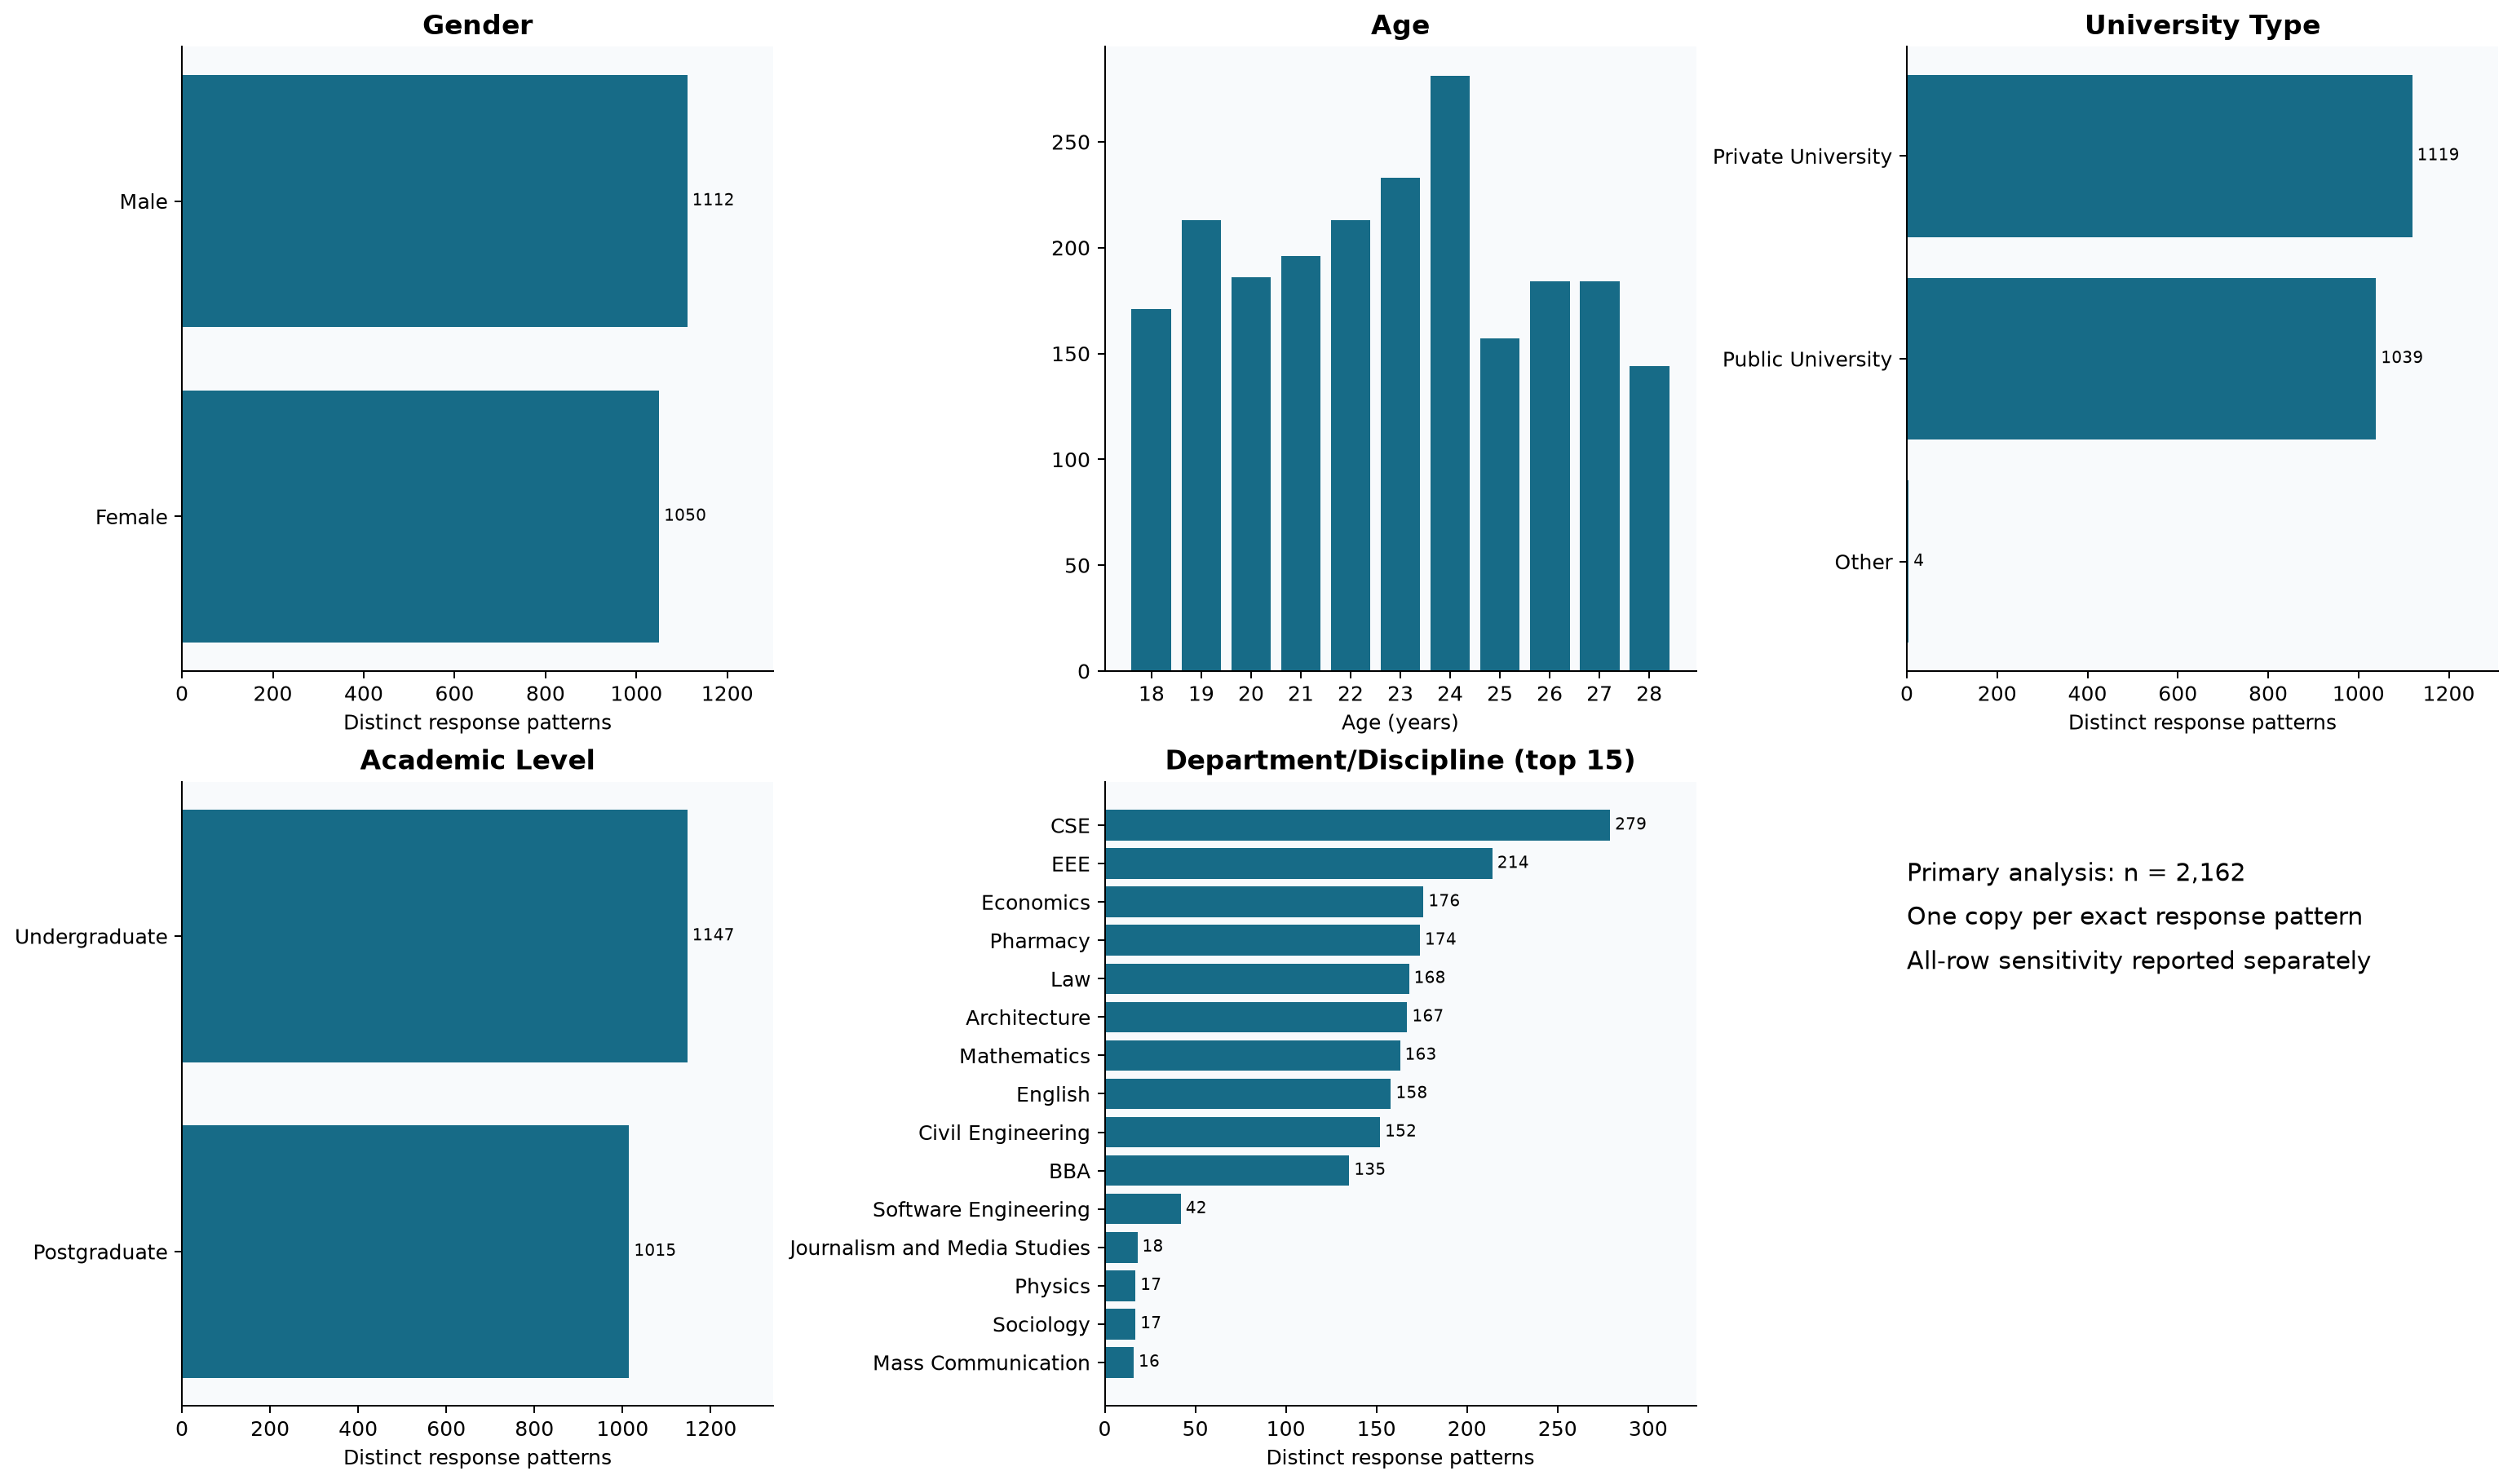

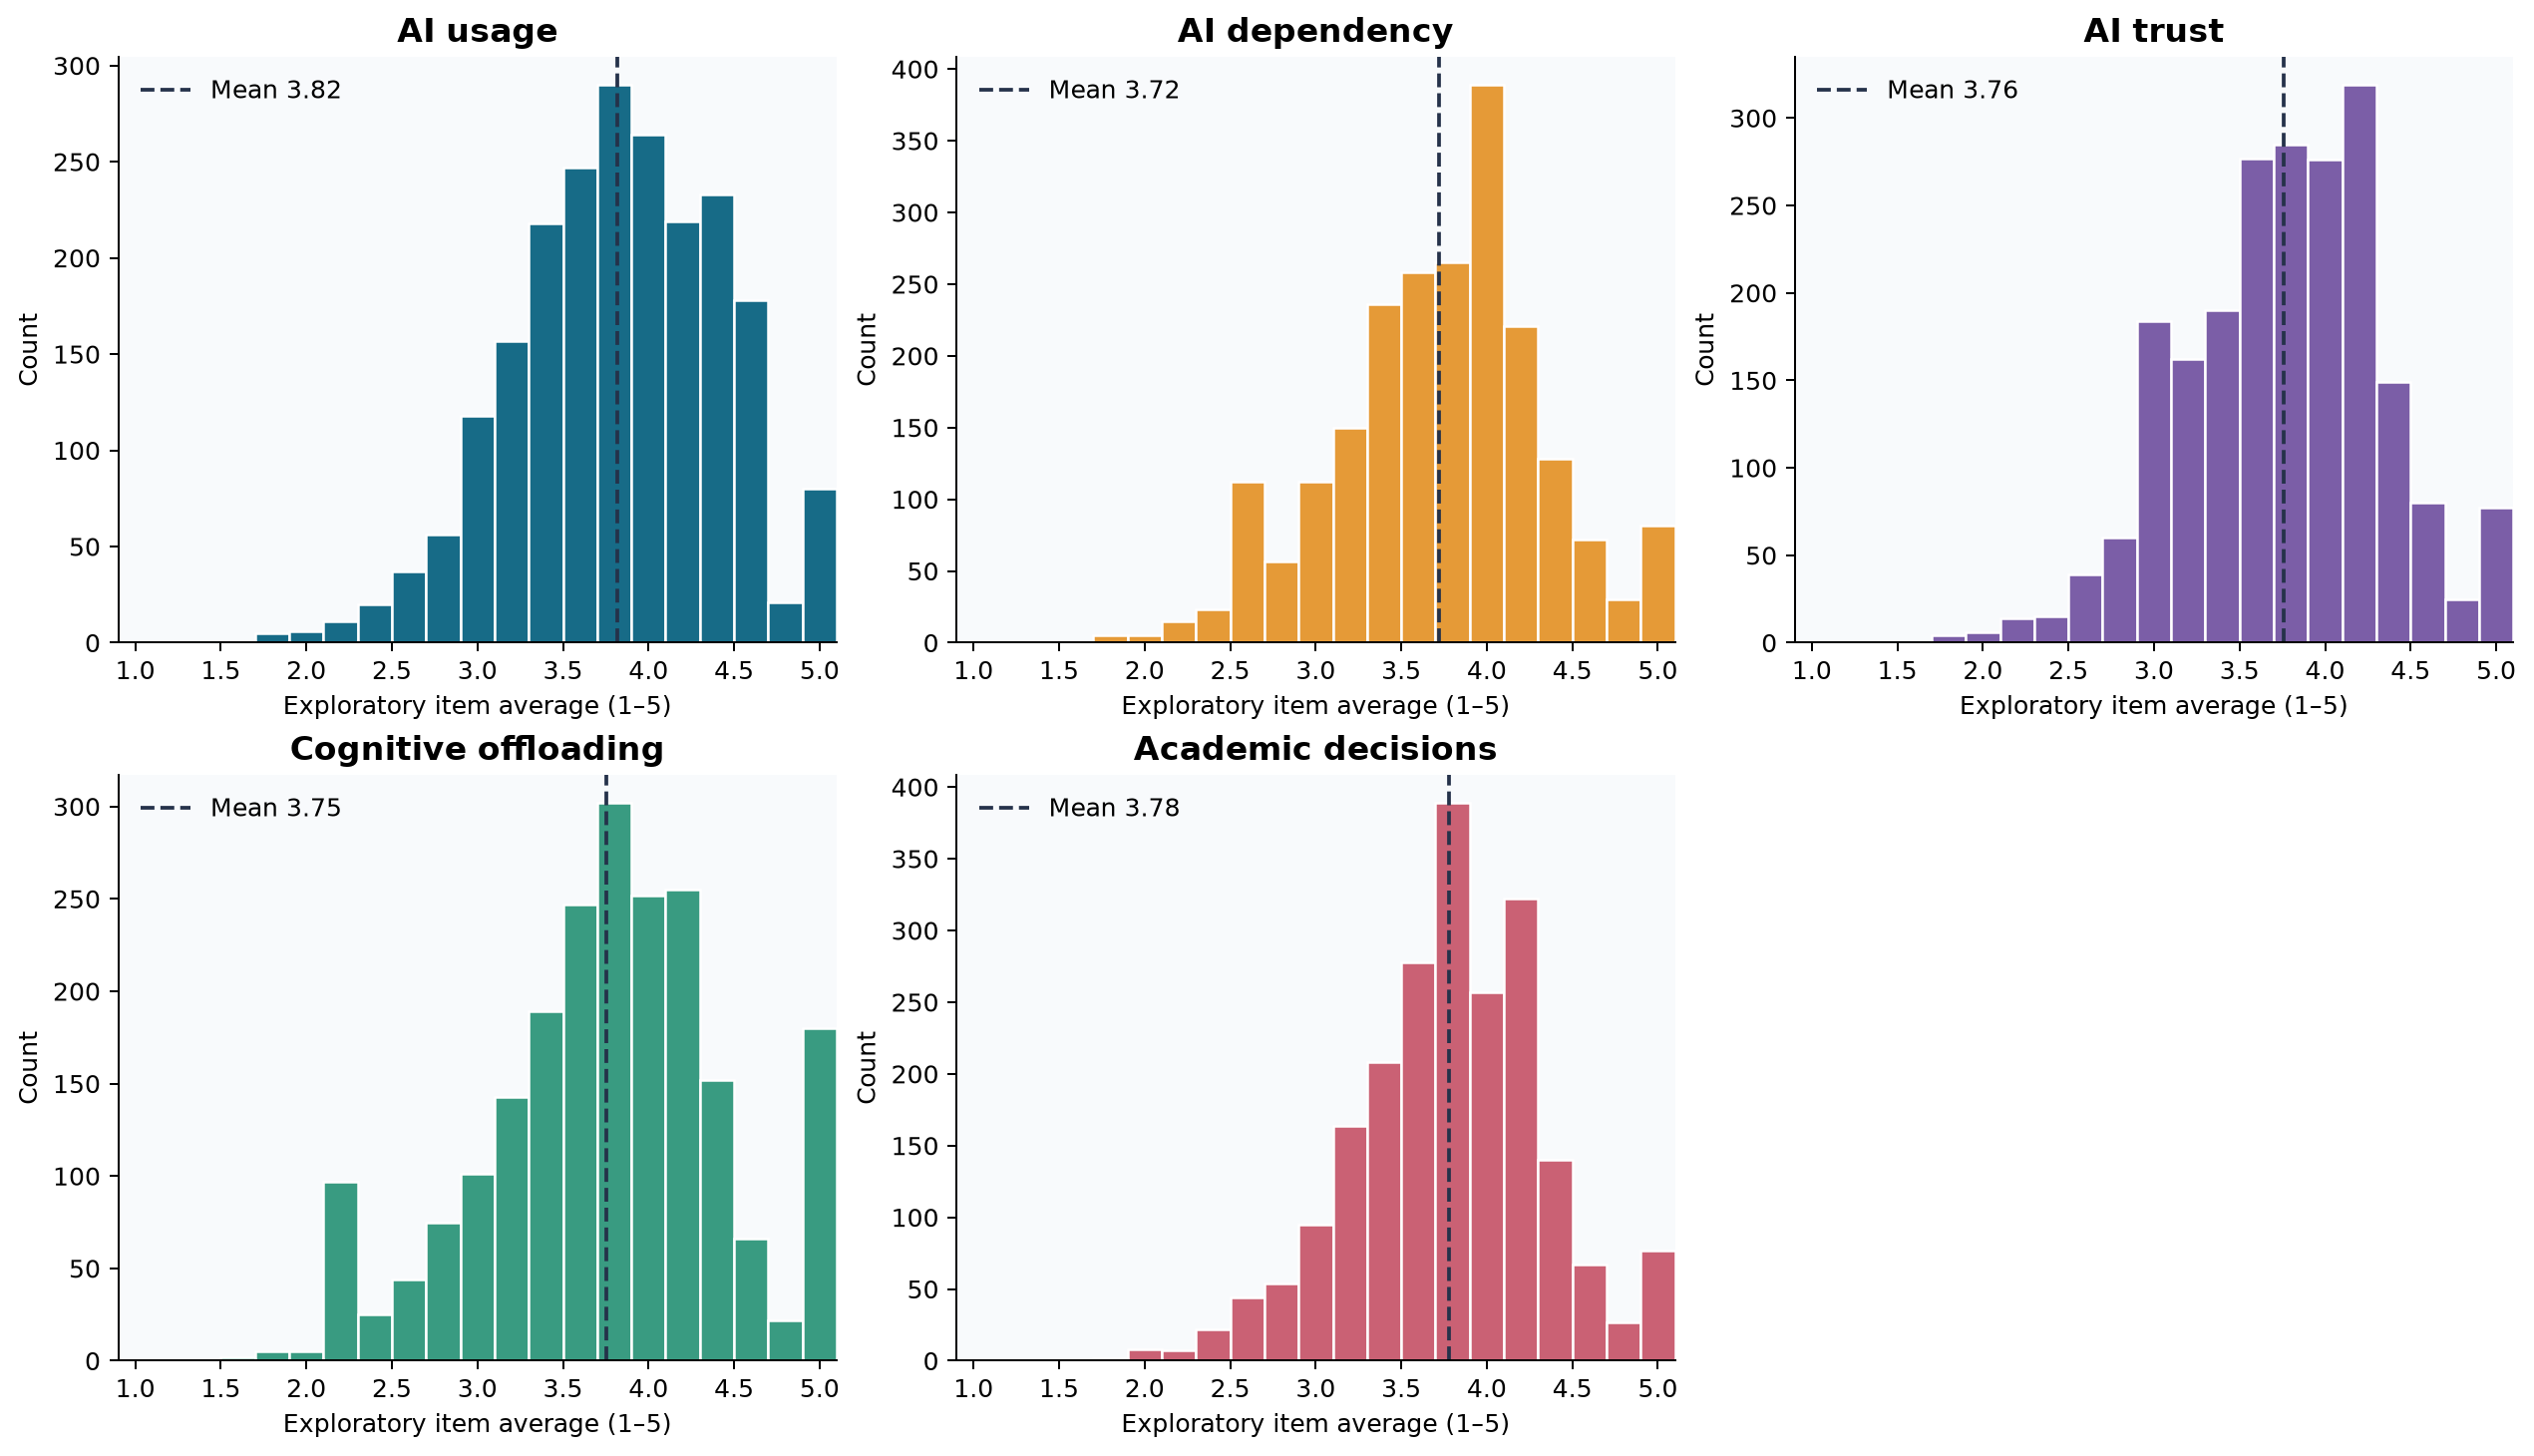

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10), layout="constrained")
for ax, column in zip(axes.flat, demographic_columns):
    if column == "Age":
        counts = analysis_df[column].value_counts().sort_index()
        ax.bar(counts.index, counts.values, color=COLORS[0])
        ax.set_xticks(counts.index)
        ax.set_xlabel("Age (years)")
    else:
        counts = analysis_df[column].value_counts()
        if column == "Department/Discipline":
            counts = counts.head(15)
        counts = counts.sort_values()
        ax.barh(counts.index, counts.values, color=COLORS[0])
        for position, value in enumerate(counts.values):
            ax.text(value, position, f" {value}", va="center", fontsize=8)
        ax.set_xlim(0, counts.max() * 1.17)
        ax.set_xlabel("Distinct response patterns")
    ax.set_title(column + (" (top 15)" if column == "Department/Discipline" else ""))
axes.flat[-1].axis("off")
axes.flat[-1].text(0, 0.7, f"Primary analysis: n = {len(analysis_df):,}\nOne copy per exact response pattern\nAll-row sensitivity reported separately",
                   fontsize=12, linespacing=1.8)
save_figure(fig, "01_demographics")

fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout="constrained")
for ax, name, color in zip(axes.flat, index_columns, COLORS):
    ax.hist(analysis_df[name], bins=np.arange(0.9, 5.2, 0.2), color=color, edgecolor="white")
    ax.axvline(analysis_df[name].mean(), color="#25324a", linestyle="--", label=f"Mean {analysis_df[name].mean():.2f}")
    ax.set(title=short_names[name], xlabel="Exploratory item average (1–5)", ylabel="Count", xlim=(0.9, 5.1))
    ax.legend(frameon=False)
axes.flat[-1].axis("off")
save_figure(fig, "02_index_distributions")
print("Saved demographic and five-index distribution panels.")


**Output interpretation:** peaks represent the most frequent observed ages,
categories, and item averages. Index histograms describe reported agreement,
not cognitive performance. Exact repeated records are not counted repeatedly
in these primary plots.

## Phase 6b — Spearman associations and multiplicity control

**Why this test:** Spearman's rho assesses monotonic association using ranks,
which suits tied ordinal-item averages without assuming bivariate normality.
The sample has more than 500 distinct patterns, supporting SciPy's asymptotic
two-sided p-value approximation, conditional on independent observations.
Independence remains unverified. Holm adjustment controls family-wise error
across the six prespecified relationships, separately for primary and sensitivity
analyses. A 0.05 adjusted-p convention summarizes statistical evidence, not
practical importance. [SciPy Spearman documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html)

Scatterplots use transparency plus a small seeded jitter only for display.
Calculations always use the original, unjittered values; no simulated responses
enter any analysis. No causal direction is inferred.


              sample                   x                          y    n       rho      p_value       p_holm                    interpretation
    primary_distinct      AI_Usage_Index        AI_Dependency_Index 2162  0.139789  6.66031e-11  1.33206e-10 Evidence of monotonic association
    primary_distinct AI_Dependency_Index Cognitive_Offloading_Index 2162  0.284488  1.55946e-41  7.79728e-41 Evidence of monotonic association
    primary_distinct      AI_Trust_Index        AI_Dependency_Index 2162  0.268906  3.95774e-37  1.58309e-36 Evidence of monotonic association
    primary_distinct AI_Dependency_Index    Academic_Decision_Index 2162 0.0668339   0.00187547   0.00187547 Evidence of monotonic association
    primary_distinct      AI_Usage_Index Cognitive_Offloading_Index 2162  0.182869  1.03149e-17  3.09447e-17 Evidence of monotonic association
    primary_distinct      AI_Trust_Index Cognitive_Offloading_Index 2162   0.31274  2.89429e-50  1.73657e-49 Evidence of monotonic association

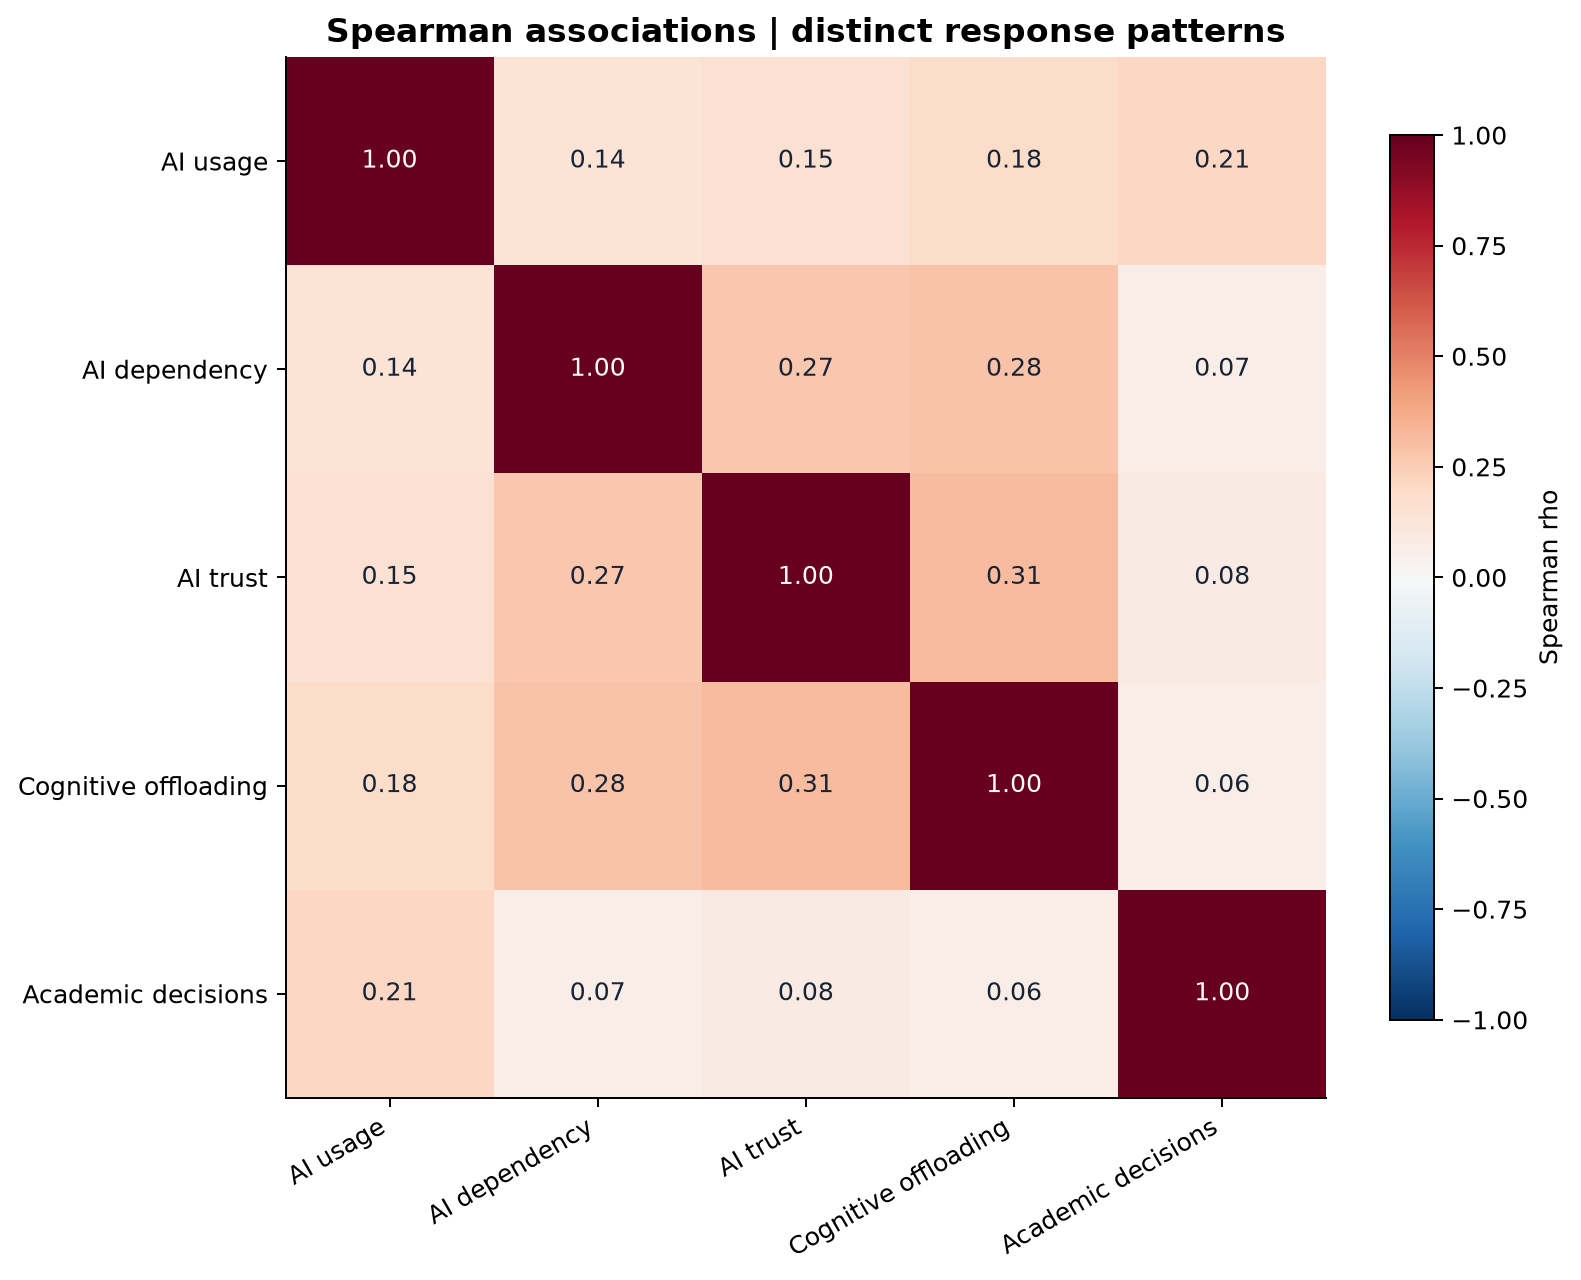

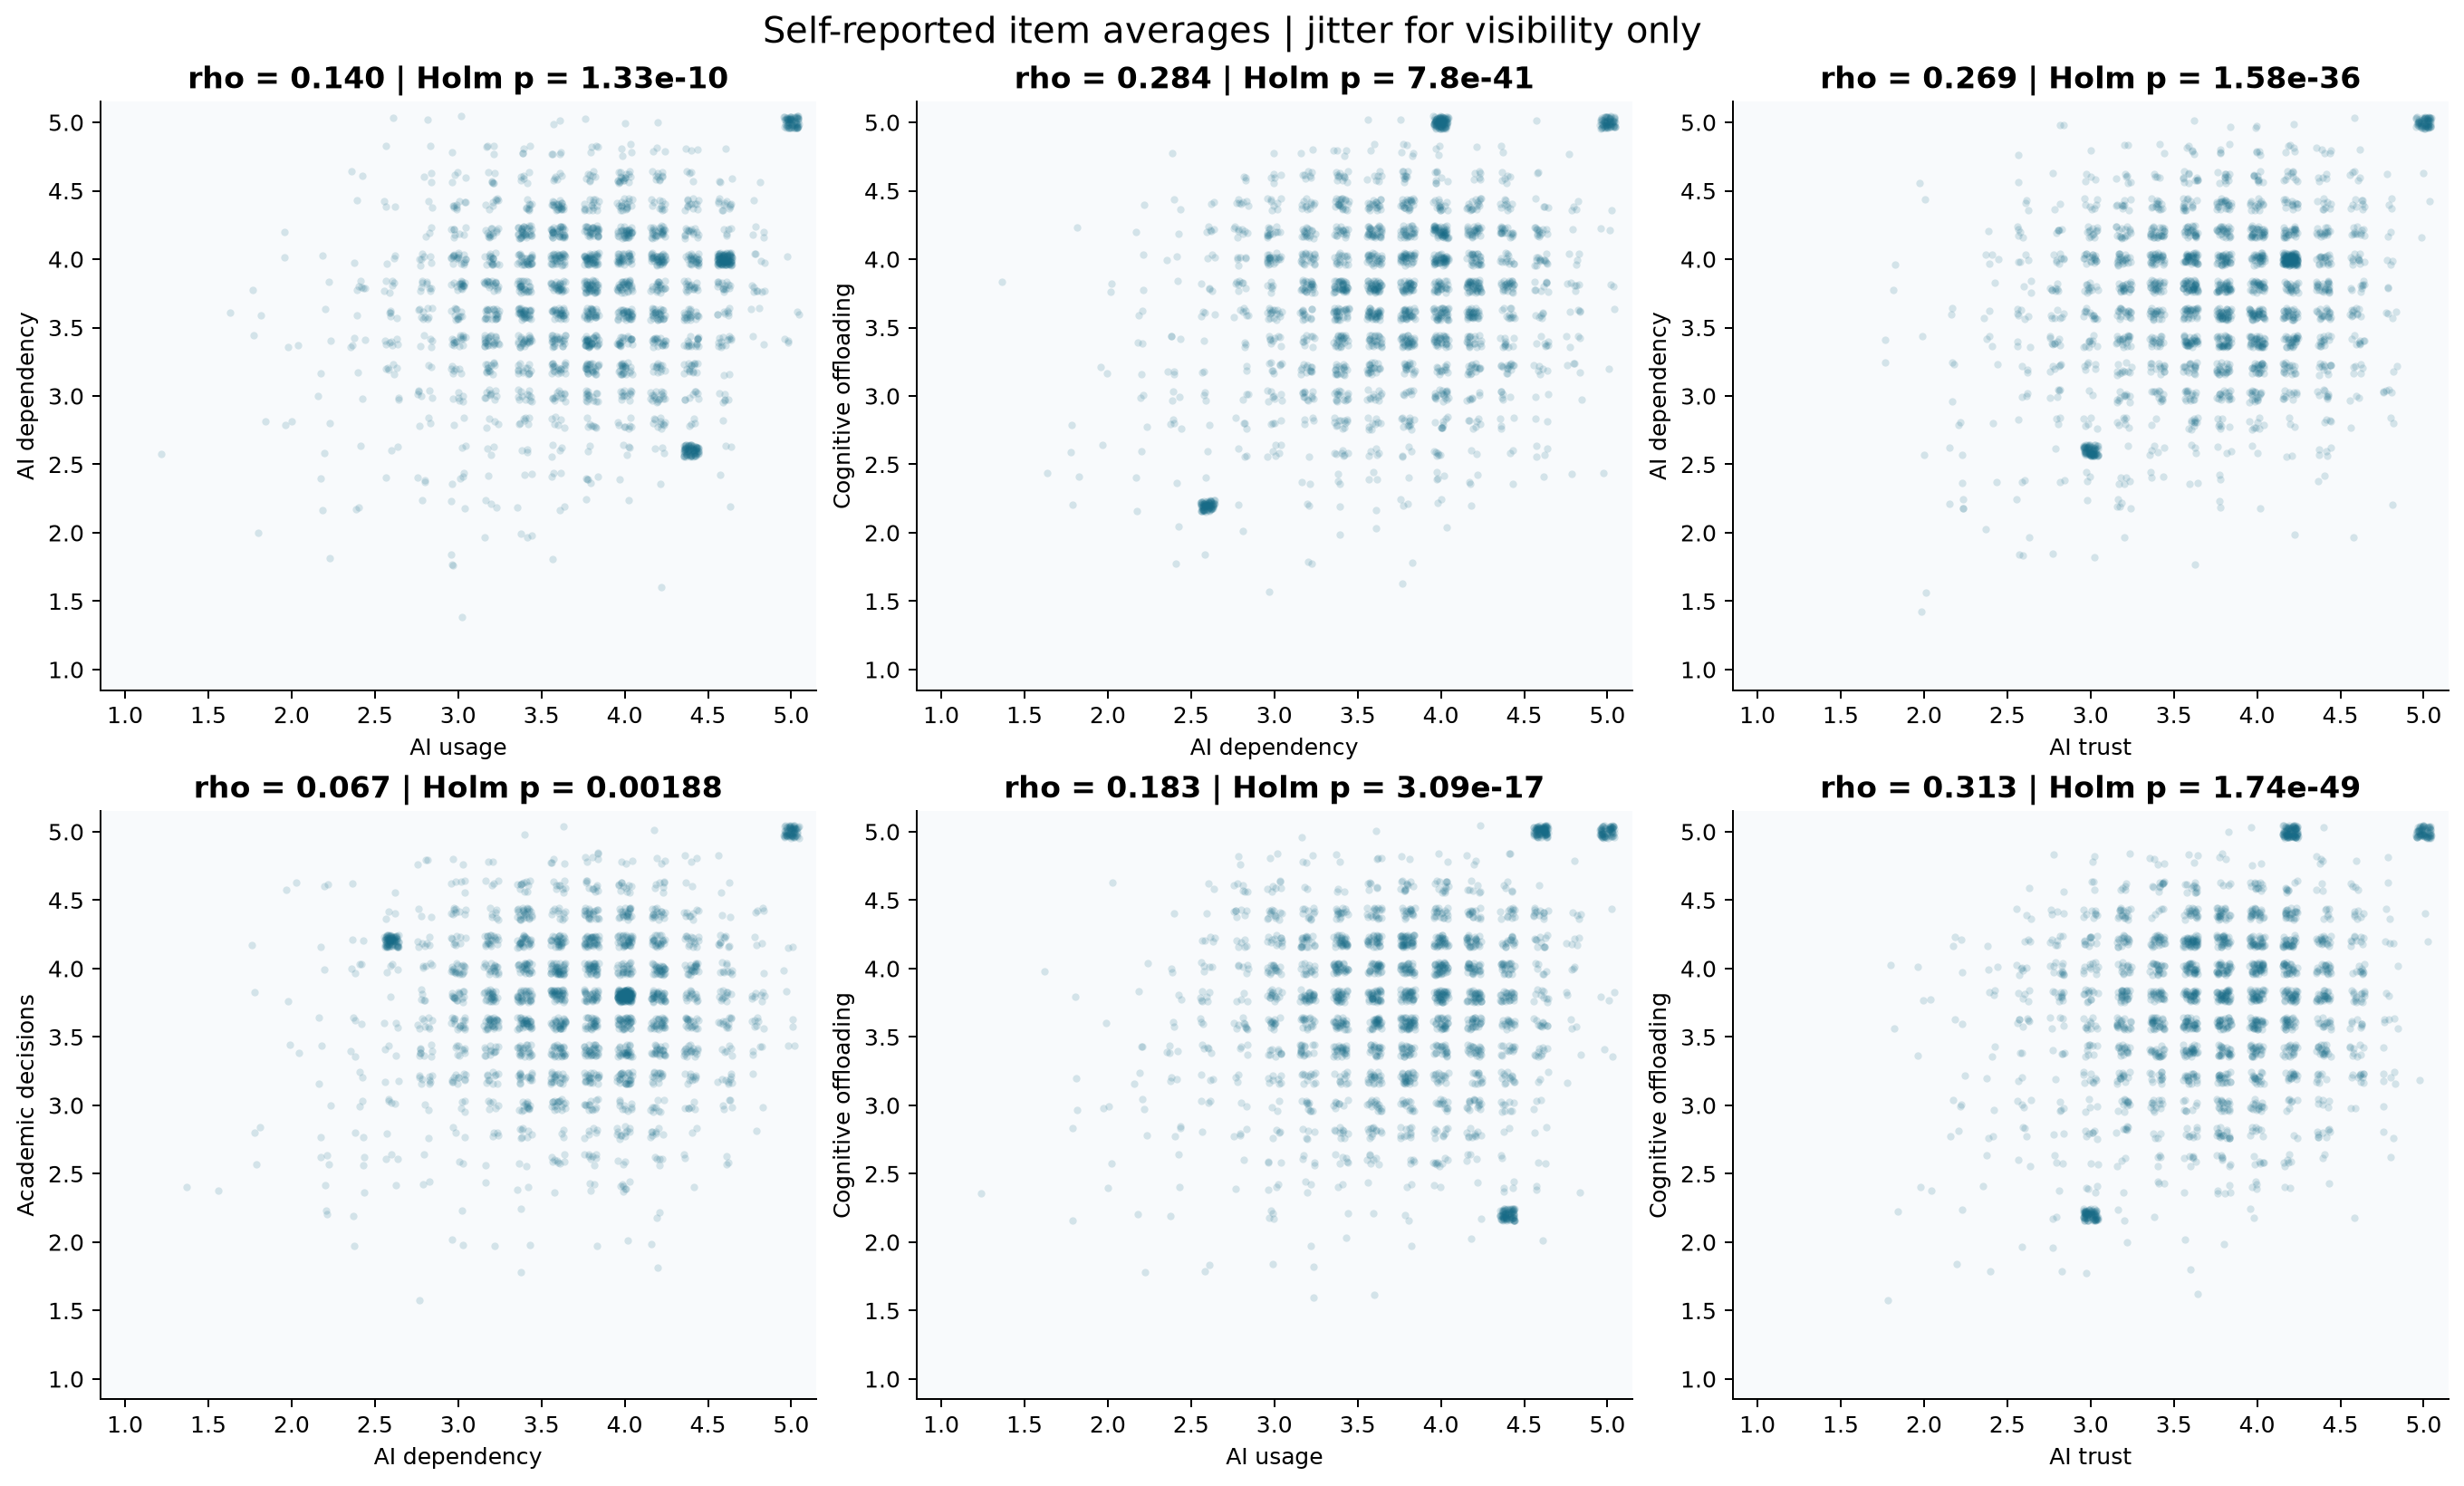

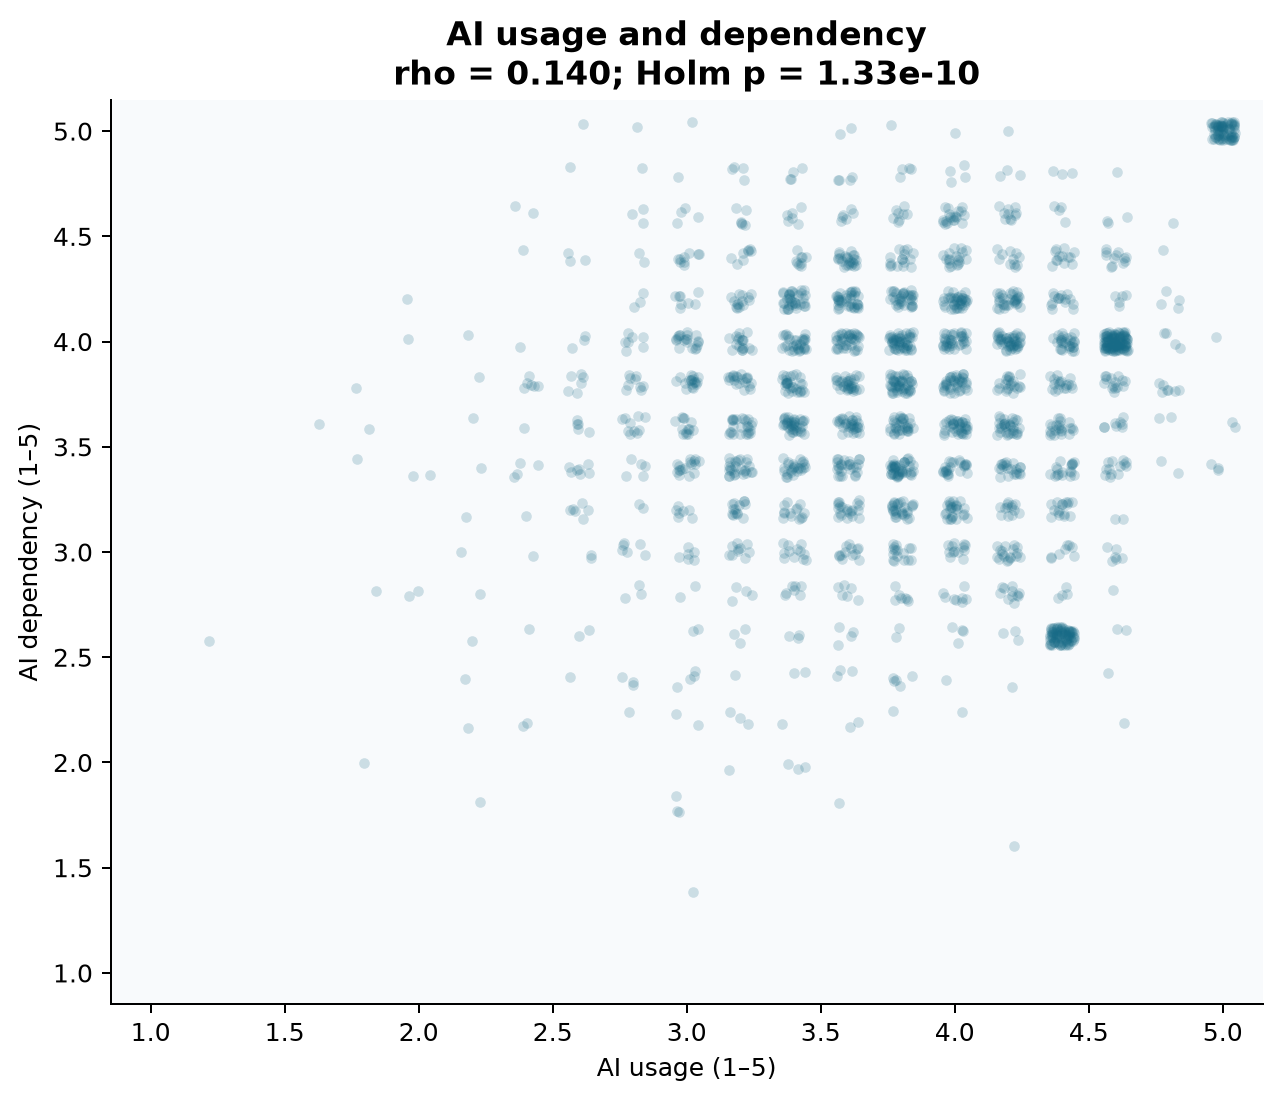

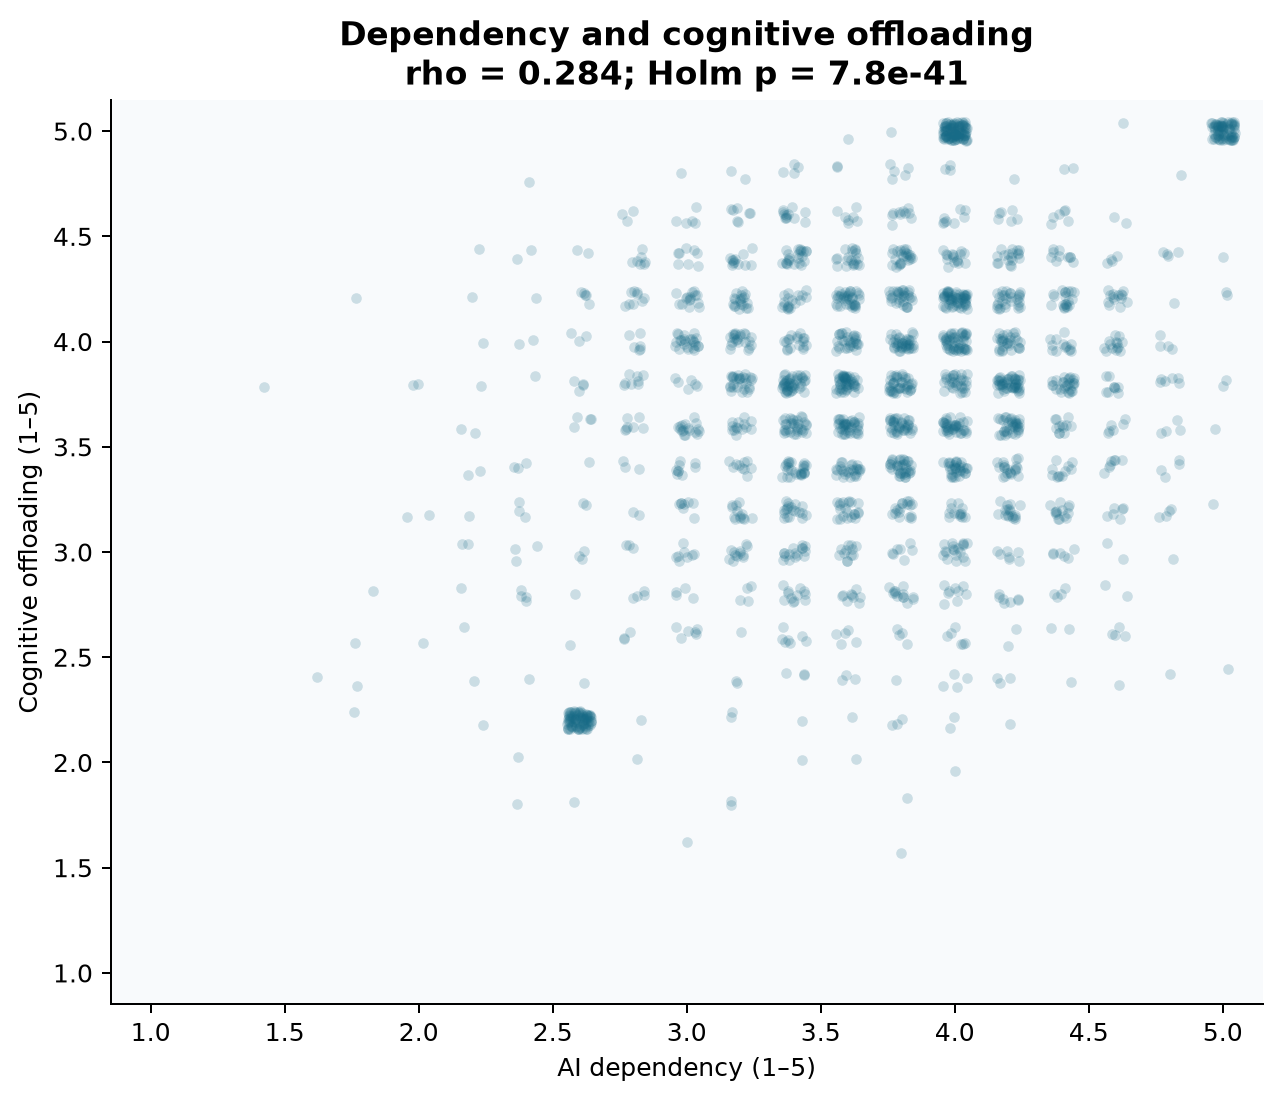

In [12]:
def holm_adjust(p_values):
    """Holm step-down adjusted p-values, returned in the original order."""
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values)
    adjusted_sorted = np.maximum.accumulate((len(values) - np.arange(len(values))) * values[order])
    result = np.empty(len(values), dtype=float)
    result[order] = np.minimum(adjusted_sorted, 1.0)
    return result

relationships = [
    ("AI_Usage_Index", "AI_Dependency_Index"),
    ("AI_Dependency_Index", "Cognitive_Offloading_Index"),
    ("AI_Trust_Index", "AI_Dependency_Index"),
    ("AI_Dependency_Index", "Academic_Decision_Index"),
    ("AI_Usage_Index", "Cognitive_Offloading_Index"),
    ("AI_Trust_Index", "Cognitive_Offloading_Index"),
]
correlation_rows = []
for sample_name, frame in [("primary_distinct", analysis_df), ("all_rows_sensitivity", composite_all)]:
    current_rows = []
    for left, right in relationships:
        result = stats.spearmanr(frame[left], frame[right], alternative="two-sided")
        current_rows.append({"sample": sample_name, "x": left, "y": right,
                             "n": len(frame), "rho": result.statistic, "p_value": result.pvalue})
    adjusted = holm_adjust([row["p_value"] for row in current_rows])
    for row, p_adjusted in zip(current_rows, adjusted):
        row["p_holm"] = p_adjusted
        row["interpretation"] = ("Evidence of monotonic association" if p_adjusted < 0.05
                                 else "Insufficient evidence of monotonic association")
    correlation_rows.extend(current_rows)
correlations = pd.DataFrame(correlation_rows)
primary_correlations = correlations.query("sample == 'primary_distinct'").copy()
save_table(correlations, "spearman_relationships.csv")
correlation_matrix = analysis_df[index_columns].corr(method="spearman")
save_table(correlation_matrix, "spearman_matrix.csv", index=True)
print(correlations.to_string(index=False, float_format=lambda value: f"{value:.6g}"))
print("All-row p-values may overstate evidence if repeated patterns are duplicate submissions.")

fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
im = ax.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(5), [short_names[name] for name in index_columns], rotation=30, ha="right")
ax.set_yticks(range(5), [short_names[name] for name in index_columns])
for row in range(5):
    for column in range(5):
        value = correlation_matrix.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.6 else "#172336")
ax.set_title("Spearman associations | distinct response patterns")
fig.colorbar(im, ax=ax, label="Spearman rho", shrink=0.85)
save_figure(fig, "03_spearman_heatmap")

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 9), layout="constrained")
for ax, (left, right), row in zip(axes.flat, relationships, primary_correlations.itertuples()):
    ax.scatter(analysis_df[left] + rng.uniform(-0.045, 0.045, len(analysis_df)),
               analysis_df[right] + rng.uniform(-0.045, 0.045, len(analysis_df)),
               s=11, alpha=0.16, color=COLORS[0], linewidths=0)
    ax.set(xlabel=short_names[left], ylabel=short_names[right], xlim=(0.85, 5.15), ylim=(0.85, 5.15),
           title=f"rho = {row.rho:.3f} | Holm p = {row.p_holm:.3g}")
fig.suptitle("Self-reported item averages | jitter for visibility only", fontsize=16)
save_figure(fig, "04_six_associations")
for number, (left, right), title in [(5, relationships[0], "AI usage and dependency"),
                                   (6, relationships[1], "Dependency and cognitive offloading")]:
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
    plot_rng = np.random.default_rng(SEED)
    ax.scatter(analysis_df[left] + plot_rng.uniform(-0.045, 0.045, len(analysis_df)),
               analysis_df[right] + plot_rng.uniform(-0.045, 0.045, len(analysis_df)),
               s=18, alpha=0.2, color=COLORS[0], linewidths=0)
    row = primary_correlations[(primary_correlations.x == left) & (primary_correlations.y == right)].iloc[0]
    ax.set(xlabel=short_names[left] + " (1–5)", ylabel=short_names[right] + " (1–5)",
           title=f"{title}\nrho = {row.rho:.3f}; Holm p = {row.p_holm:.3g}", xlim=(0.85, 5.15), ylim=(0.85, 5.15))
    save_figure(fig, f"{number:02d}_association")


**Output interpretation:** positive rho means higher values tend to co-occur;
negative rho means an inverse tendency. Read the magnitude alongside adjusted
p-values. Sensitivity estimates show how repeated patterns change the result.
Neither temporal order nor causality can be established by this survey.

## Phase 7 — Group assumptions and comparisons

**Objective and test choice:** inspect group counts, missingness, dispersion,
skew, tied values, and boxplots first. The outcomes are bounded, discrete item
averages, so rank-based comparisons are appropriate without relying on normality.
Each record belongs to one category per demographic variable; independence
between records is assumed, not verified by removing exact matches.
Mann–Whitney U compares two independent distributions using its asymptotic,
tie-corrected two-sided calculation. Kruskal–Wallis compares more than two with
tie correction. If any group has fewer than five records, use 9,999 seeded
permutations for the H statistic instead of its chi-square approximation.
The upper tail of H tests any group difference. Small-group pairwise U tests
also use 9,999 permutations. Permutation validity assumes exchangeability under
the null and does not resolve unknown respondent independence.
These are distribution/rank comparisons: differing shapes prevent a simple
median-shift interpretation. An omnibus difference does not identify a pair.
[Mann–Whitney U](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html),
[Kruskal–Wallis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html).

Report signed rank-biserial correlation `2U/(n1*n2)-1` for two groups (positive
means the alphabetically first group tends higher) and `H/(N-1)` as rank epsilon
squared for multiple groups. Holm adjustment covers the six outcome/demographic
omnibus tests per sample. Exploratory university pairwise tests form a separate
six-test family. Statistical significance does not imply practical importance.


Assumptions and descriptive checks BEFORE tests:
                   outcome        grouping              group    n  missing   mean  median    q25    q75     sd    skew  distinct_values  repeated_value_fraction
       AI_Dependency_Index          Gender             Female 1050        0 3.7895  3.8000 3.4000 4.2000 0.5659 -0.2123               17                   0.9838
       AI_Dependency_Index          Gender               Male 1112        0 3.6590  3.8000 3.2000 4.0000 0.6402 -0.2598               19                   0.9829
       AI_Dependency_Index University Type              Other    4        0 3.1500  3.4000 2.9500 3.6000 0.6608 -1.5595                3                   0.2500
       AI_Dependency_Index University Type Private University 1119        0 3.6686  3.8000 3.2000 4.0000 0.6401 -0.2758               19                   0.9830
       AI_Dependency_Index University Type  Public University 1039        0 3.7825  3.8000 3.4000 4.2000 0.5663 -0.1946               17     

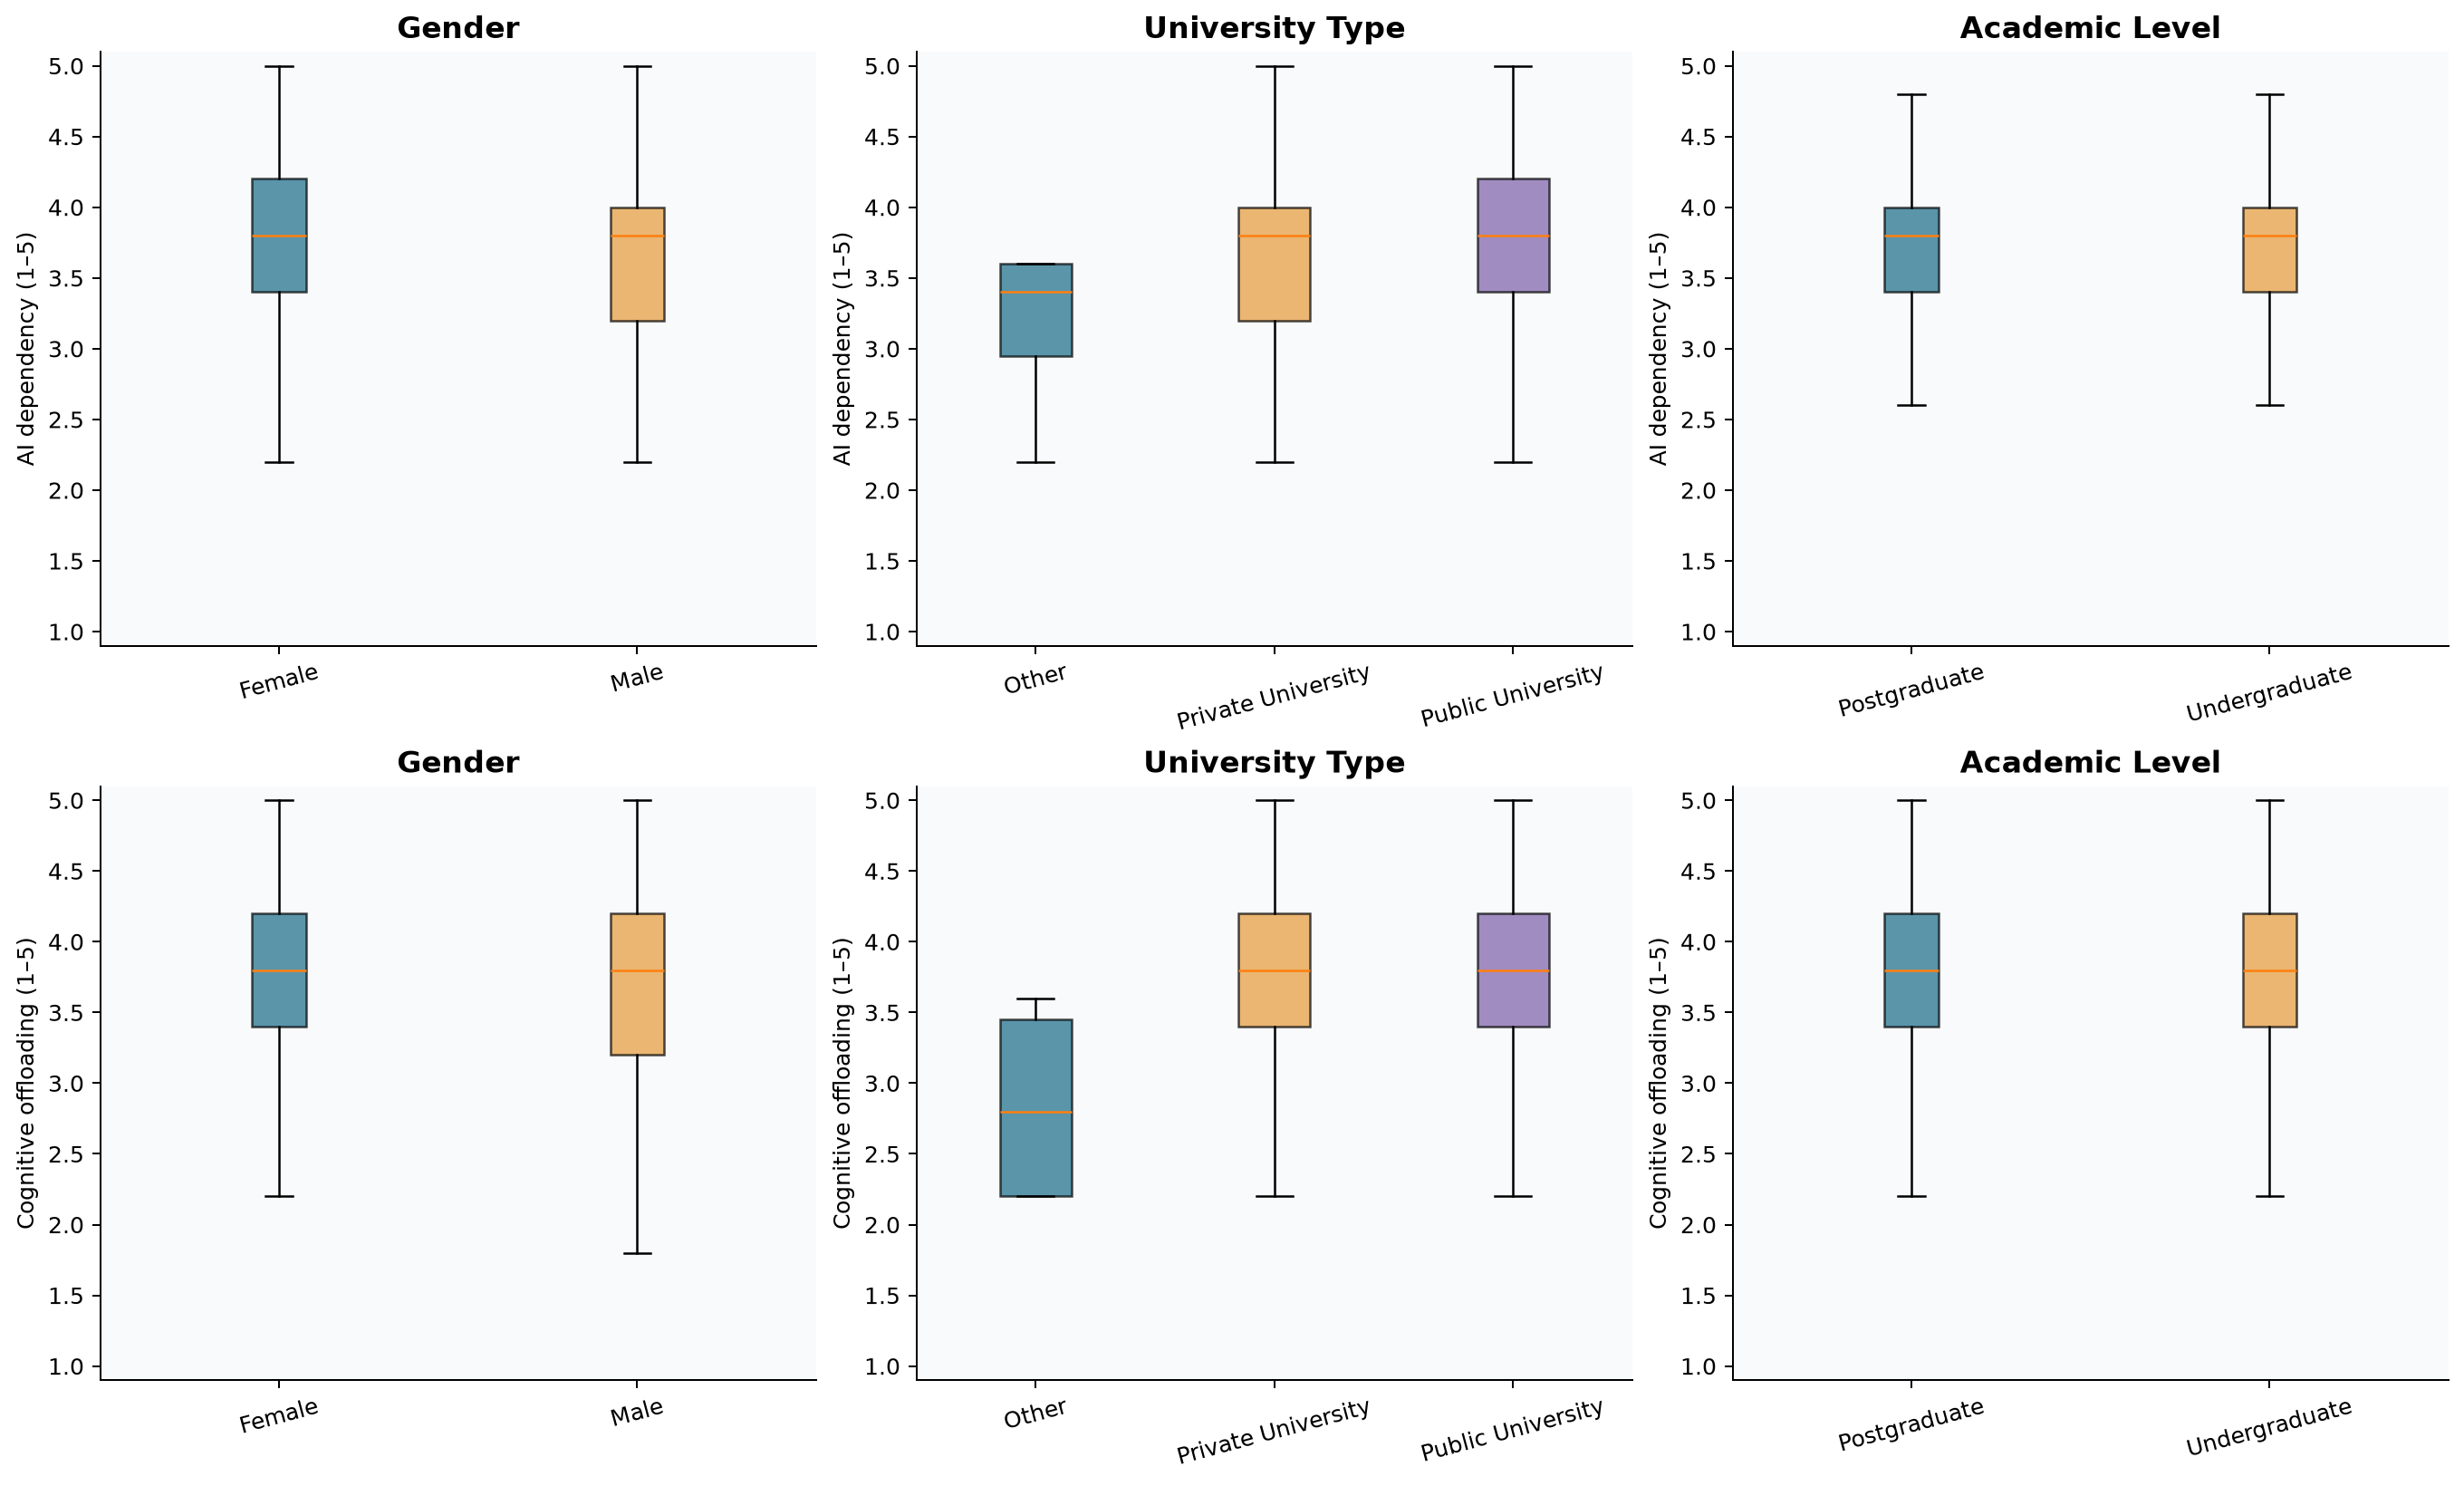

In [13]:
group_columns = ["Gender", "University Type", "Academic Level"]
group_outcomes = ["AI_Dependency_Index", "Cognitive_Offloading_Index"]
assumption_rows = []
for outcome in group_outcomes:
    for grouping in group_columns:
        for label, group in analysis_df.groupby(grouping, observed=True):
            values = group[outcome]
            assumption_rows.append({"outcome": outcome, "grouping": grouping, "group": label,
                "n": len(values), "missing": int(values.isna().sum()), "mean": values.mean(),
                "median": values.median(), "q25": values.quantile(0.25), "q75": values.quantile(0.75),
                "sd": values.std(), "skew": values.skew(), "distinct_values": values.nunique(),
                "repeated_value_fraction": 1 - values.nunique() / len(values)})
assumptions = pd.DataFrame(assumption_rows)
save_table(assumptions, "group_descriptives_assumptions.csv")
print("Assumptions and descriptive checks BEFORE tests:")
print(assumptions.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print("Minimum group size:", int(assumptions["n"].min()))
print("Groups smaller than five require permutation inference:")
print(assumptions.loc[assumptions.n < 5, ["outcome", "grouping", "group", "n"]].to_string(index=False))
assert assumptions["missing"].sum() == 0

fig, axes = plt.subplots(2, 3, figsize=(15, 9), layout="constrained")
for row_number, outcome in enumerate(group_outcomes):
    for column_number, grouping in enumerate(group_columns):
        ax = axes[row_number, column_number]
        labels = sorted(analysis_df[grouping].unique())
        samples = [analysis_df.loc[analysis_df[grouping] == label, outcome] for label in labels]
        artists = ax.boxplot(samples, patch_artist=True, showfliers=False)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels)
        for patch, color in zip(artists["boxes"], COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set(title=grouping, ylabel=short_names[outcome] + " (1–5)", ylim=(0.9, 5.1))
        ax.tick_params(axis="x", labelrotation=15)
save_figure(fig, "07_group_comparisons")


**Checks interpreted before testing:** Other university type has only four
distinct response patterns. Keep the category and use permutation-based H
p-values for university comparisons; use permutation U p-values for pairwise
comparisons involving this group. No outcomes are missing. Repeated
index values are expected because the item average lies on a 0.2 grid. Boxplots
and dispersion summaries show distribution shape; no assumption of equal shape
is imposed, so results below concern rank/distribution differences. A normality
pretest is unnecessary for this prespecified nonparametric strategy.


In [14]:
def seeded_permutation_test(samples, statistic, alternative):
    """Use the random_state API supported by the project's Anaconda environment."""
    return stats.permutation_test(
        samples, statistic, permutation_type="independent", vectorized=True,
        alternative=alternative, n_resamples=9999, batch=100,
        random_state=SEED,
    )

def kruskal_statistic(*samples, axis=-1):
    return stats.kruskal(*samples, axis=axis).statistic

def mannwhitney_statistic(x, y, axis=-1):
    # Only the U statistic is used; the outer permutation test calculates p.
    return stats.mannwhitneyu(x, y, axis=axis, method="asymptotic").statistic

group_test_rows = []
for sample_name, frame in [("primary_distinct", analysis_df), ("all_rows_sensitivity", composite_all)]:
    current_rows = []
    for outcome in group_outcomes:
        for grouping in group_columns:
            labels = sorted(frame[grouping].unique())
            samples = [frame.loc[frame[grouping] == label, outcome].to_numpy() for label in labels]
            if len(samples) == 2:
                result = stats.mannwhitneyu(*samples, alternative="two-sided", method="asymptotic")
                test_name = "Mann-Whitney U"
                effect = 2 * result.statistic / (len(samples[0]) * len(samples[1])) - 1
                effect_name = "rank_biserial_first_vs_second"
            else:
                if min(map(len, samples)) < 5:
                    result = seeded_permutation_test(samples, kruskal_statistic, alternative="greater")
                    test_name = "Kruskal-Wallis H (9999 permutations)"
                else:
                    result = stats.kruskal(*samples)
                    test_name = "Kruskal-Wallis H (asymptotic)"
                effect = result.statistic / (sum(map(len, samples)) - 1)
                effect_name = "rank_epsilon_squared"
            current_rows.append({"sample": sample_name, "outcome": outcome, "grouping": grouping,
                "groups_in_order": " / ".join(labels), "test": test_name,
                "statistic": result.statistic, "p_value": result.pvalue,
                "effect_size": effect, "effect_name": effect_name})
    for row, adjusted in zip(current_rows, holm_adjust([row["p_value"] for row in current_rows])):
        row["p_holm"] = adjusted
        row["interpretation"] = ("Evidence of distribution/rank differences" if adjusted < 0.05
                                 else "Insufficient evidence of distribution/rank differences")
    group_test_rows.extend(current_rows)
group_tests = pd.DataFrame(group_test_rows)
save_table(group_tests, "group_tests.csv")
print(group_tests.to_string(index=False, float_format=lambda value: f"{value:.6g}"))

from itertools import combinations
posthoc_rows = []
for outcome in group_outcomes:
    for first, second in combinations(sorted(analysis_df["University Type"].unique()), 2):
        x = analysis_df.loc[analysis_df["University Type"] == first, outcome]
        y_group = analysis_df.loc[analysis_df["University Type"] == second, outcome]
        if min(len(x), len(y_group)) < 5:
            result = seeded_permutation_test((x, y_group), mannwhitney_statistic, alternative="two-sided")
            p_method = "9999 permutations"
        else:
            result = stats.mannwhitneyu(x, y_group, alternative="two-sided", method="asymptotic")
            p_method = "asymptotic"
        posthoc_rows.append({"outcome": outcome, "first": first, "second": second,
            "p_method": p_method,
            "U": result.statistic, "p_value": result.pvalue,
            "rank_biserial": 2 * result.statistic / (len(x) * len(y_group)) - 1})
posthoc = pd.DataFrame(posthoc_rows)
posthoc["p_holm"] = holm_adjust(posthoc["p_value"])
save_table(posthoc, "university_pairwise_exploratory.csv")
print("\nExploratory pairwise university comparisons, Holm across six tests:")
print(posthoc.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


              sample                    outcome        grouping                                groups_in_order                                 test   statistic     p_value  effect_size                   effect_name      p_holm                                         interpretation
    primary_distinct        AI_Dependency_Index          Gender                                  Female / Male                       Mann-Whitney U      647816 8.95782e-06     0.109655 rank_biserial_first_vs_second 5.37469e-05              Evidence of distribution/rank differences
    primary_distinct        AI_Dependency_Index University Type Other / Private University / Public University Kruskal-Wallis H (9999 permutations)     15.9388      0.0002   0.00737567          rank_epsilon_squared       0.001              Evidence of distribution/rank differences
    primary_distinct        AI_Dependency_Index  Academic Level                   Postgraduate / Undergraduate                       Mann-Whitney U      5

**Output interpretation:** report the U/H statistic, adjusted p-value and effect
size together. A nonsignificant test does not prove identical groups. All-row
sensitivity p-values inherit the unresolved repeated-record issue. Group
associations do not explain why categories differ.

## Phases 8–9 — Two feature sets, one held-out split, training-only preprocessing

**Objective:** predict the continuous exploratory AI Dependency Index.
Model A uses the five AI Usage items and the five demographics, preserving
usage-item detail despite weak reliability of their average. Model B adds only
the trust, offloading, and academic-decision indices. These related constructs
make B an expanded associational predictor, not a causal or early-warning model.

The target's five constituent items and both dependency score versions are
explicitly forbidden from X. Split distinct patterns with `test_size=0.20` and
`random_state=42` once, then reuse the same rows and five shuffled training folds.
No hyperparameters or feature sets are adjusted after looking at the test set.
The candidate is selected by mean training-CV RMSE, with MAE as a tie-breaker;
the test set provides a final generalization check rather than a second tuning
criterion. All candidates' test results are reported for transparency.

Numeric median imputation and scaling, and categorical most-frequent imputation
and `OneHotEncoder(handle_unknown="ignore")`, are fitted inside each Pipeline.
There are no missing values in this dataset, but the serialized model includes
the imputation policy. Academic Level is also one-hot encoded to avoid an
unnecessary order assumption. [scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html)


In [15]:
from sklearn.base import clone
import inspect
from sklearn.model_selection import train_test_split, KFold, cross_validate, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

target_name = "AI_Dependency_Index"
categorical_features = ["Gender", "University Type", "Academic Level", "Department/Discipline"]
features_a = ai_usage_cols + demographic_columns
features_b = features_a + ["AI_Trust_Index", "Cognitive_Offloading_Index", "Academic_Decision_Index"]
feature_sets = {"A": features_a, "B": features_b}
for name, features in feature_sets.items():
    assert set(features).issubset(analysis_df.columns)
    assert not set(features).intersection(cognitive_dependence_cols + [target_name, "AI_Dependency_100"])
    print(f"Model {name} predictors ({len(features)}):", features)

train_rows, test_rows = train_test_split(analysis_df.index.to_numpy(), test_size=0.20, random_state=SEED)
y_train = analysis_df.loc[train_rows, target_name]
y_test = analysis_df.loc[test_rows, target_name]
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(train_rows))
raw_pattern_hash = pd.util.hash_pandas_object(df, index=False)
assert set(raw_pattern_hash.loc[train_rows]).isdisjoint(set(raw_pattern_hash.loc[test_rows]))
for fit_positions, validation_positions in cv_splits:
    assert set(raw_pattern_hash.loc[train_rows[fit_positions]]).isdisjoint(
        set(raw_pattern_hash.loc[train_rows[validation_positions]]))
split_manifest = pd.DataFrame({"source_row_position": analysis_df.index,
    "partition": np.where(analysis_df.index.isin(train_rows), "train", "test")})
split_manifest.to_csv(DATA / "split_manifest_local.csv", index=False)
print("Training patterns:", len(train_rows), "| Test patterns:", len(test_rows))
print("Exact complete-pattern overlap across split/folds: zero.")

def make_preprocessor(features):
    numeric = [name for name in features if name not in categorical_features]
    categorical = [name for name in features if name in categorical_features]
    # sparse_output replaced sparse in scikit-learn 1.2.
    dense_argument = "sparse_output" if "sparse_output" in inspect.signature(OneHotEncoder).parameters else "sparse"
    encoder = OneHotEncoder(handle_unknown="ignore", drop="first", **{dense_argument: False})
    return ColumnTransformer([
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")),
                              ("scaler", StandardScaler())]), numeric),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder)]), categorical),
    ], remainder="drop")

def regression_metrics(actual, predicted):
    return {"MAE": mean_absolute_error(actual, predicted),
            "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted)}


Model A predictors (10): ['AI Usage [I use generative AI tools regularly for academic purposes.]', 'AI Usage [I use AI tools for assignment writing.]', 'AI Usage [I use AI tools for study planning.]', 'AI Usage [I use AI tools for research-related tasks.]', 'AI Usage [I depend on AI tools to complete academic work faster.]', 'Gender', 'Age', 'University Type', 'Academic Level', 'Department/Discipline']
Model B predictors (13): ['AI Usage [I use generative AI tools regularly for academic purposes.]', 'AI Usage [I use AI tools for assignment writing.]', 'AI Usage [I use AI tools for study planning.]', 'AI Usage [I use AI tools for research-related tasks.]', 'AI Usage [I depend on AI tools to complete academic work faster.]', 'Gender', 'Age', 'University Type', 'Academic Level', 'Department/Discipline', 'AI_Trust_Index', 'Cognitive_Offloading_Index', 'Academic_Decision_Index']
Training patterns: 1729 | Test patterns: 433
Exact complete-pattern overlap across split/folds: zero.


**Output interpretation:** the same training/test response patterns and CV folds
are used for every candidate. No scaler, imputer, encoder, or model has learned
from held-out test rows. Fixed item means require no learned preprocessing.
One-hot reference categories (`drop="first"`) avoid exact dummy redundancy in
linear models; unknown categories are handled by the stated encoder policy.

## Phase 10 — Baseline and regression comparisons

**Why these models:** DummyRegressor predicts the training mean and establishes
whether more complex predictors add value. Linear Regression provides a simple
additive benchmark; Ridge adds L2 regularization for related predictors. Random
Forest can capture nonlinearities and interactions; Gradient Boosting provides
a second nonlinear ensemble with sequential shallow trees. The preset tree
depth/leaf controls moderate flexibility. These are fixed demonstration settings,
not claimed optimal parameters. No extra XGBoost dependency is needed.

Evaluate MAE and RMSE in dependency-index units (1–5) and R² relative to the
evaluation-sample mean. Negative R² is possible. Five-fold CV runs on training
data only, cloning the entire pipeline for each fold. Report mean and SD across
folds; fold SD is not a confidence interval. Select by CV before computing any
test metrics. The saved best pipeline remains fitted only on training rows.


A | Dummy: CV RMSE=0.6120
A | Linear Regression: CV RMSE=0.5952
A | Ridge: CV RMSE=0.5893
A | Random Forest: CV RMSE=0.5047
A | Gradient Boosting: CV RMSE=0.5383
B | Dummy: CV RMSE=0.6120
B | Linear Regression: CV RMSE=0.5442
B | Ridge: CV RMSE=0.5392
B | Random Forest: CV RMSE=0.4989
B | Gradient Boosting: CV RMSE=0.4965
CV-selected candidate, locked before test evaluation: ('B', 'Gradient Boosting')
feature_set             model  CV_MAE_mean  CV_MAE_sd  CV_RMSE_mean  CV_RMSE_sd  CV_R2_mean  CV_R2_sd  Test_MAE  Test_RMSE  Test_R2  selected_by_cv
          A     Random Forest       0.3901     0.0246        0.5047      0.0273      0.3120    0.0433    0.4032     0.5341   0.2040           False
          A Gradient Boosting       0.4344     0.0212        0.5383      0.0238      0.2173    0.0358    0.4331     0.5428   0.1780           False
          A             Ridge       0.4748     0.0219        0.5893      0.0241      0.0620    0.0361    0.4605     0.5815   0.0564           False
   

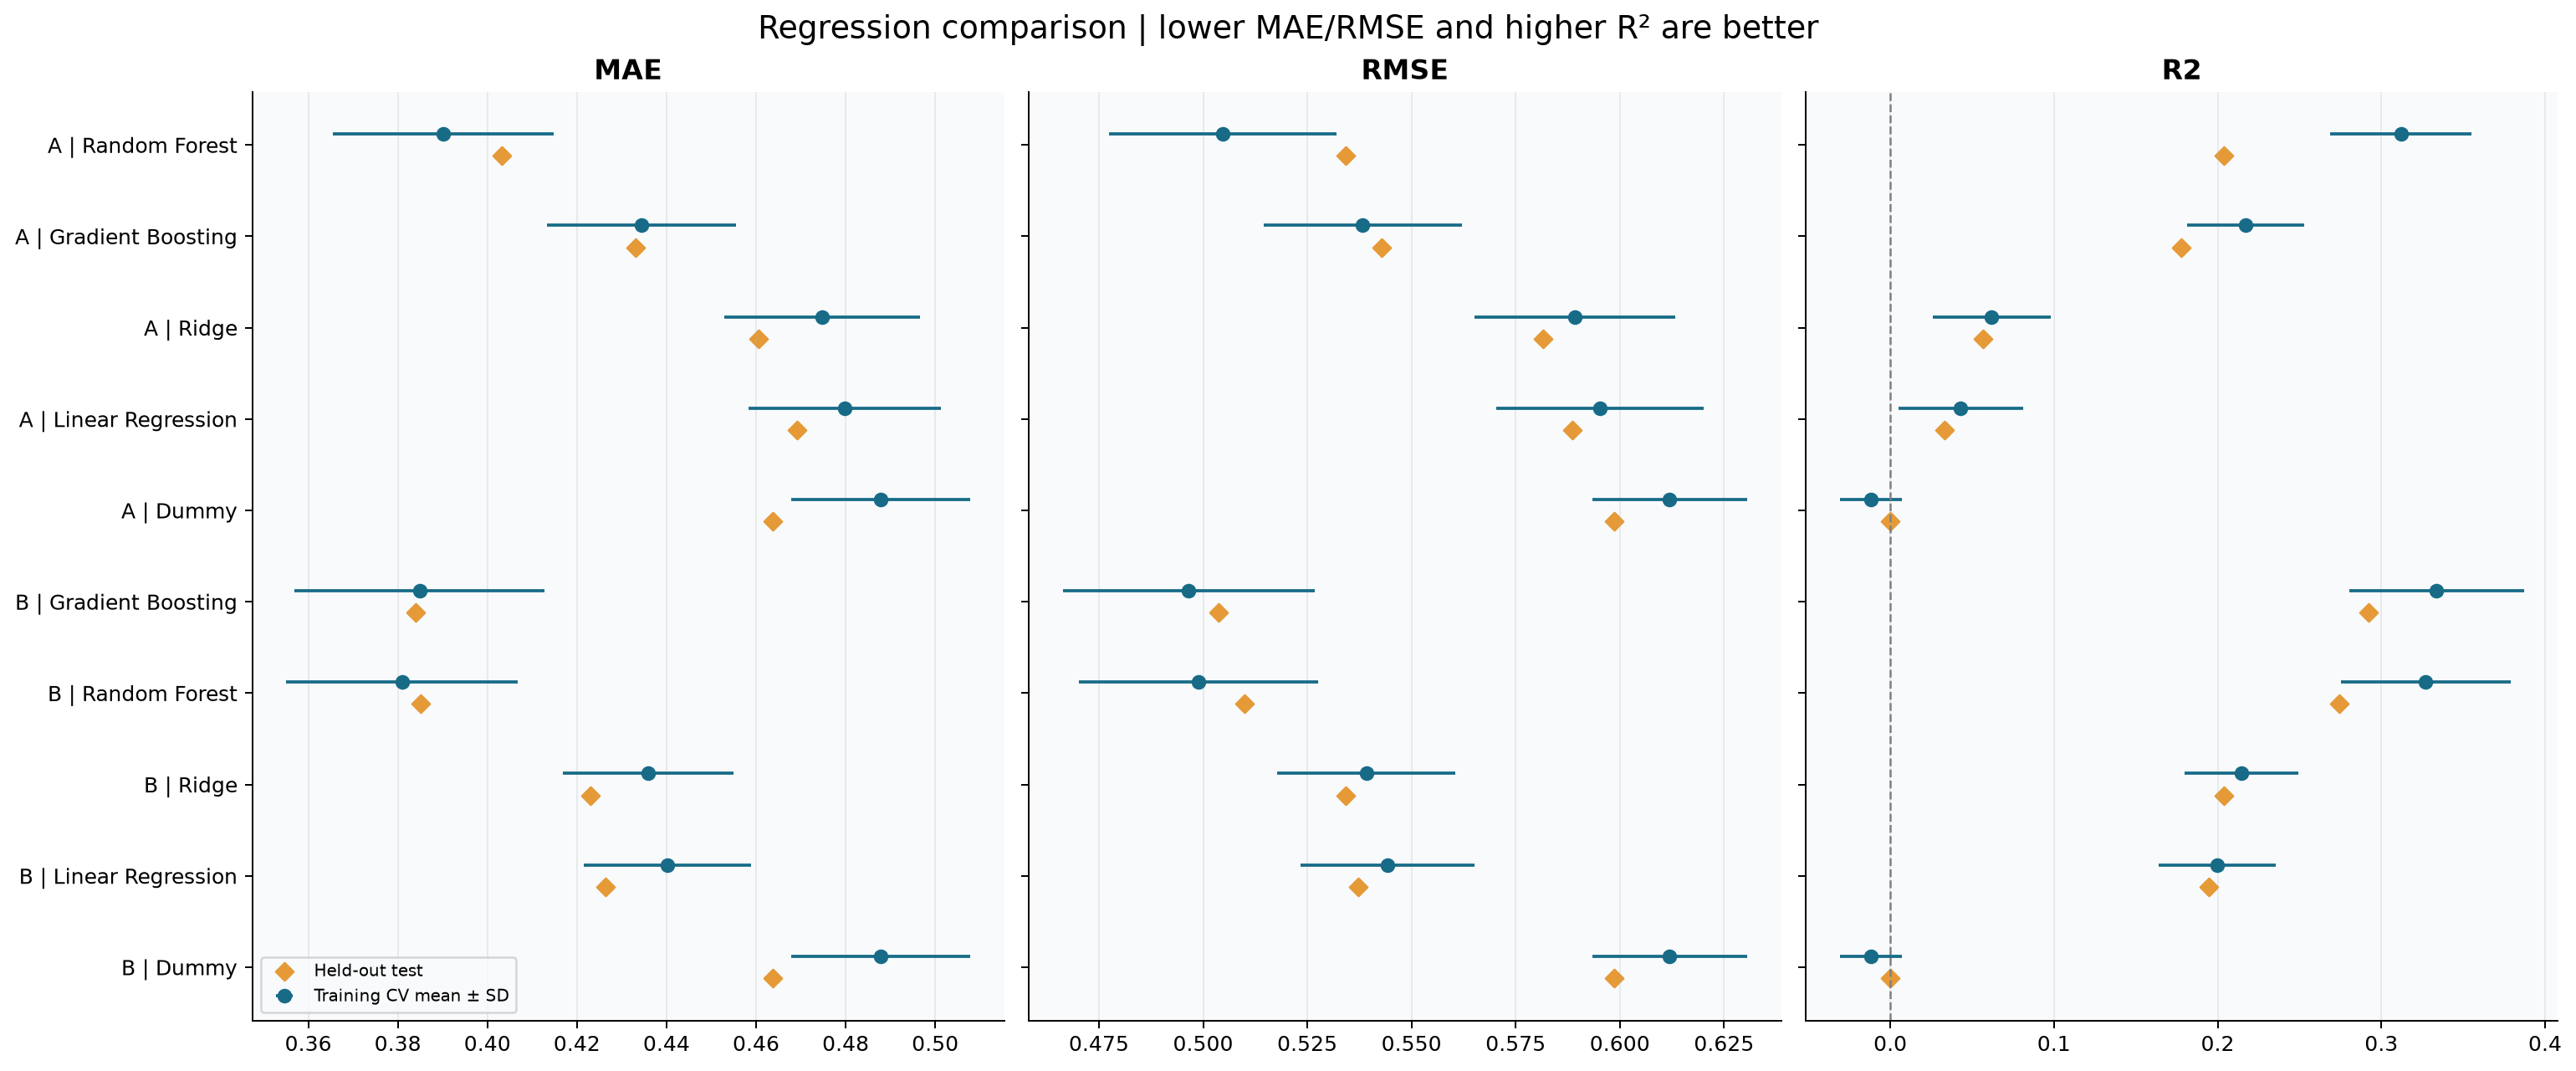

In [16]:
candidates = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(n_estimators=160, min_samples_leaf=5,
        max_features=1.0, random_state=SEED, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=160, learning_rate=0.05,
        max_depth=2, min_samples_leaf=8, random_state=SEED),
}
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
fitted_models = {}
comparison_rows = []
fold_rows = []
with threadpool_limits(limits=2):
    for feature_set, features in feature_sets.items():
        X_train = analysis_df.loc[train_rows, features]
        for model_name, estimator in candidates.items():
            pipeline = Pipeline([("preprocessor", make_preprocessor(features)), ("model", clone(estimator))])
            scores = cross_validate(pipeline, X_train, y_train, cv=cv_splits,
                                    scoring=scoring, n_jobs=1, error_score="raise")
            row = {"feature_set": feature_set, "model": model_name}
            for metric in scoring:
                values = scores[f"test_{metric}"] * (-1 if metric != "R2" else 1)
                row[f"CV_{metric}_mean"] = values.mean()
                row[f"CV_{metric}_sd"] = values.std(ddof=1)
                for fold, value in enumerate(values, 1):
                    fold_rows.append({"feature_set": feature_set, "model": model_name,
                                      "fold": fold, "metric": metric, "value": value})
            pipeline.fit(X_train, y_train)
            fitted_models[(feature_set, model_name)] = pipeline
            comparison_rows.append(row)
            print(f"{feature_set} | {model_name}: CV RMSE={row['CV_RMSE_mean']:.4f}", flush=True)

comparison = pd.DataFrame(comparison_rows)
cv_order = comparison.sort_values(["CV_RMSE_mean", "CV_MAE_mean", "feature_set", "model"])
best_key = tuple(cv_order.iloc[0][["feature_set", "model"]])
best_a_key = tuple(cv_order.query("feature_set == 'A'").iloc[0][["feature_set", "model"]])
print("CV-selected candidate, locked before test evaluation:", best_key)

for row_number, row in comparison.iterrows():
    key = (row["feature_set"], row["model"])
    predicted = fitted_models[key].predict(analysis_df.loc[test_rows, feature_sets[key[0]]])
    for metric, value in regression_metrics(y_test, predicted).items():
        comparison.loc[row_number, f"Test_{metric}"] = value
comparison["selected_by_cv"] = [(row.feature_set, row.model) == best_key for row in comparison.itertuples()]
comparison = comparison.sort_values(["feature_set", "CV_RMSE_mean"]).reset_index(drop=True)
save_table(comparison, "model_comparison.csv")
save_table(pd.DataFrame(fold_rows), "training_cv_fold_scores.csv")
best_model = fitted_models[best_key]
best_features = feature_sets[best_key[0]]
X_test_best = analysis_df.loc[test_rows, best_features]
best_predictions = best_model.predict(X_test_best)
best_result = comparison[comparison.selected_by_cv].iloc[0]
best_a_result = comparison[(comparison.feature_set == best_a_key[0]) & (comparison.model == best_a_key[1])].iloc[0]
joblib.dump(best_model, MODELS / "best_regression_pipeline.joblib")
joblib.dump(fitted_models[best_a_key], MODELS / "best_model_a_pipeline.joblib")
model_metadata = {"target": target_name, "feature_set": best_key[0], "model": best_key[1],
    "features": best_features, "training_rows": len(train_rows), "test_rows": len(test_rows),
    "selection": "minimum mean 5-fold training CV RMSE; MAE tie-breaker",
    "random_state": SEED, "versions": versions, "likert_mapping": likert_mapping,
    "limitations": "Exploratory self-report item average with weak reliability; not for individual decisions."}
(MODELS / "model_metadata.json").write_text(json.dumps(model_metadata, indent=2), encoding="utf-8")
print(comparison.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(17, 7), layout="constrained")
labels = [f"{row.feature_set} | {row.model}" for row in comparison.itertuples()]
positions = np.arange(len(comparison))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    ax.errorbar(comparison[f"CV_{metric}_mean"], positions - 0.12,
                xerr=comparison[f"CV_{metric}_sd"], fmt="o", color=COLORS[0], label="Training CV mean ± SD")
    ax.scatter(comparison[f"Test_{metric}"], positions + 0.12, marker="D", color=COLORS[1], label="Held-out test")
    ax.set_yticks(positions, labels if metric == "MAE" else [])
    ax.set_title(metric)
    ax.grid(axis="x")
    ax.invert_yaxis()
    if metric == "R2":
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Regression comparison | lower MAE/RMSE and higher R² are better", fontsize=15)
save_figure(fig, "08_model_comparison")


**Output interpretation:** compare each candidate with the same-feature-set
dummy baseline. A CV winner is a relative choice among these candidates, not
proof of useful prediction. Test performance is reported without selecting a
different winner after seeing it. Both feature sets predict the same weakly
reliable item average; Model B's related survey constructs limit interpretation.

## Phase 10b — All-row sensitivity without cross-partition duplicate leakage

**Objective:** ask how results change if each row represents an independent
response and repeated patterns receive their original multiplicity. Assign every
copy to the partition of its primary pattern; use GroupKFold on training patterns
so copies never cross CV folds. Evaluate only the already selected A candidate,
the overall selected candidate, and their dummy baselines. No sensitivity result
changes the locked primary model. This is a different multiplicity-weighted
estimand and is not proof that any row is independent.


In [17]:
train_pattern_hashes = set(raw_pattern_hash.loc[train_rows])
test_pattern_hashes = set(raw_pattern_hash.loc[test_rows])
all_train_rows = df.index[raw_pattern_hash.isin(train_pattern_hashes)]
all_test_rows = df.index[raw_pattern_hash.isin(test_pattern_hashes)]
assert len(all_train_rows) + len(all_test_rows) == len(df)
all_groups = raw_pattern_hash.loc[all_train_rows].to_numpy()
if "shuffle" in inspect.signature(GroupKFold).parameters:
    group_cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    group_cv_splits = list(group_cv.split(composite_all.loc[all_train_rows], groups=all_groups))
else:
    # Older GroupKFold cannot shuffle. Expand the existing seed-42 primary
    # training folds to include every copy of each pattern in the same fold.
    group_cv_splits = []
    for fit_positions, validation_positions in cv_splits:
        fit_hashes = raw_pattern_hash.loc[train_rows[fit_positions]].to_numpy()
        validation_hashes = raw_pattern_hash.loc[train_rows[validation_positions]].to_numpy()
        group_cv_splits.append((np.flatnonzero(np.isin(all_groups, fit_hashes)),
                                np.flatnonzero(np.isin(all_groups, validation_hashes))))
    print("Compatibility mode: multiplicity-expanded primary CV folds; identical patterns remain grouped.")
for fit_positions, validation_positions in group_cv_splits:
    assert set(all_groups[fit_positions]).isdisjoint(set(all_groups[validation_positions]))
sensitivity_keys = list(dict.fromkeys([best_a_key, ("A", "Dummy"), best_key, (best_key[0], "Dummy")]))
sensitivity_rows = []
with threadpool_limits(limits=2):
    for feature_set, model_name in sensitivity_keys:
        features = feature_sets[feature_set]
        pipeline = clone(fitted_models[(feature_set, model_name)])
        X_train_all = composite_all.loc[all_train_rows, features]
        y_train_all = composite_all.loc[all_train_rows, target_name]
        scores = cross_validate(pipeline, X_train_all, y_train_all, cv=group_cv_splits,
                                scoring=scoring, n_jobs=1, error_score="raise")
        pipeline.fit(X_train_all, y_train_all)
        prediction = pipeline.predict(composite_all.loc[all_test_rows, features])
        row = {"feature_set": feature_set, "model": model_name,
               "n_train": len(all_train_rows), "n_test": len(all_test_rows)}
        for metric in scoring:
            row[f"CV_{metric}_mean"] = scores[f"test_{metric}"].mean() * (-1 if metric != "R2" else 1)
        for metric, value in regression_metrics(composite_all.loc[all_test_rows, target_name], prediction).items():
            row[f"Test_{metric}"] = value
        sensitivity_rows.append(row)
model_sensitivity = pd.DataFrame(sensitivity_rows)
save_table(model_sensitivity, "model_all_rows_grouped_sensitivity.csv")
print(model_sensitivity.to_string(index=False, float_format=lambda value: f"{value:.4f}"))
print("The original 80/20 split is by distinct patterns; multiplicity changes the all-row proportions.")


feature_set             model  n_train  n_test  CV_MAE_mean  CV_RMSE_mean  CV_R2_mean  Test_MAE  Test_RMSE  Test_R2
          A     Random Forest     2172     441       0.5496        0.7141      0.1868    0.3990     0.5334   0.2491
          A             Dummy     2172     441       0.6959        0.8555     -0.2325    0.5223     0.6528  -0.1248
          B Gradient Boosting     2172     441       0.5119        0.6610      0.3009    0.3788     0.5024   0.3338
          B             Dummy     2172     441       0.6959        0.8555     -0.2325    0.5223     0.6528  -0.1248
The original 80/20 split is by distinct patterns; multiplicity changes the all-row proportions.


**Output interpretation:** repeated-pattern weights can materially change both
the relationship being modeled and its evaluation. Pattern-grouped sensitivity
prevents identical full records from appearing on both sides of validation,
but cannot repair unknown provenance or establish independence.

## Phase 11 — Held-out error analysis

**Objective:** inspect actual versus predicted scores, residuals defined as
`actual - predicted`, residual summaries, and the largest absolute errors. Local
error-case exports use source row positions solely for traceability and omit
demographics. They are not student labels and should not be published. Potential
explanations such as measurement noise or unmeasured factors remain hypotheses.


Residual summary:
                count      mean       std       min        5%       25%       50%       75%       95%       max
residual        433.0  0.000453  0.504219 -1.804775 -0.826756 -0.294447  0.025998  0.299265  0.796017  1.304344
absolute_error  433.0  0.383947  0.326313  0.006040  0.022584  0.141816  0.299265  0.548478  0.985591  1.804775
Largest errors (local row positions only):
 source_row_position  actual  predicted  residual  absolute_error
                1981     2.0   3.804775 -1.804775        1.804775
                2320     2.0   3.749341 -1.749341        1.749341
                2339     1.8   3.528367 -1.728367        1.728367
                 336     1.8   3.276601 -1.476601        1.476601
                 881     2.2   3.670354 -1.470354        1.470354
                 388     2.4   3.847757 -1.447757        1.447757
                2178     1.8   3.187229 -1.387229        1.387229
                 245     2.4   3.731357 -1.331357        1.331357
         

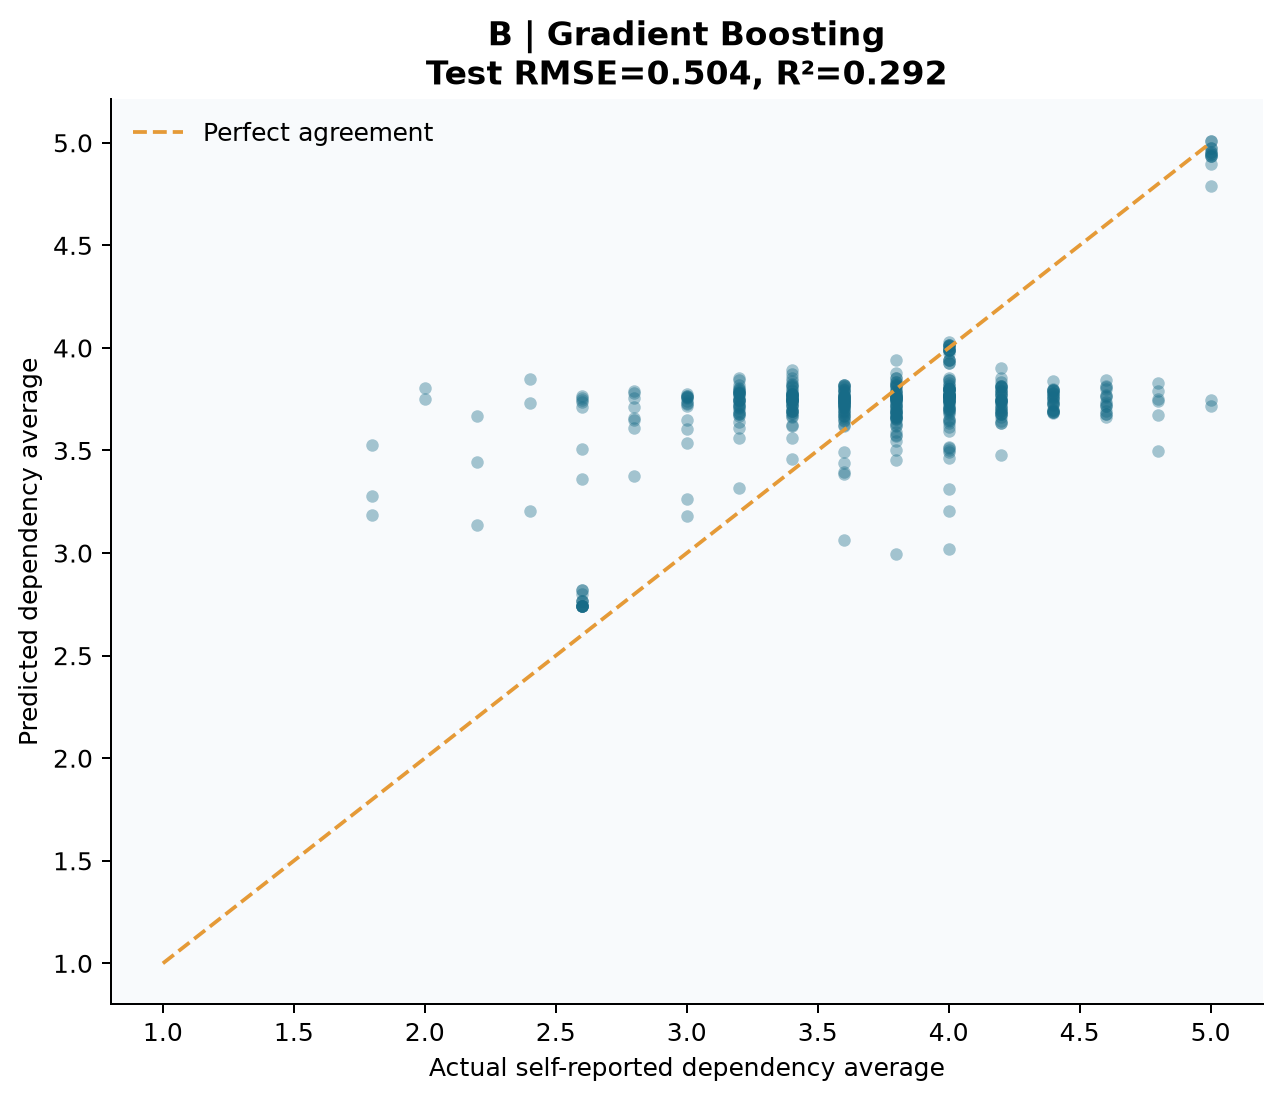

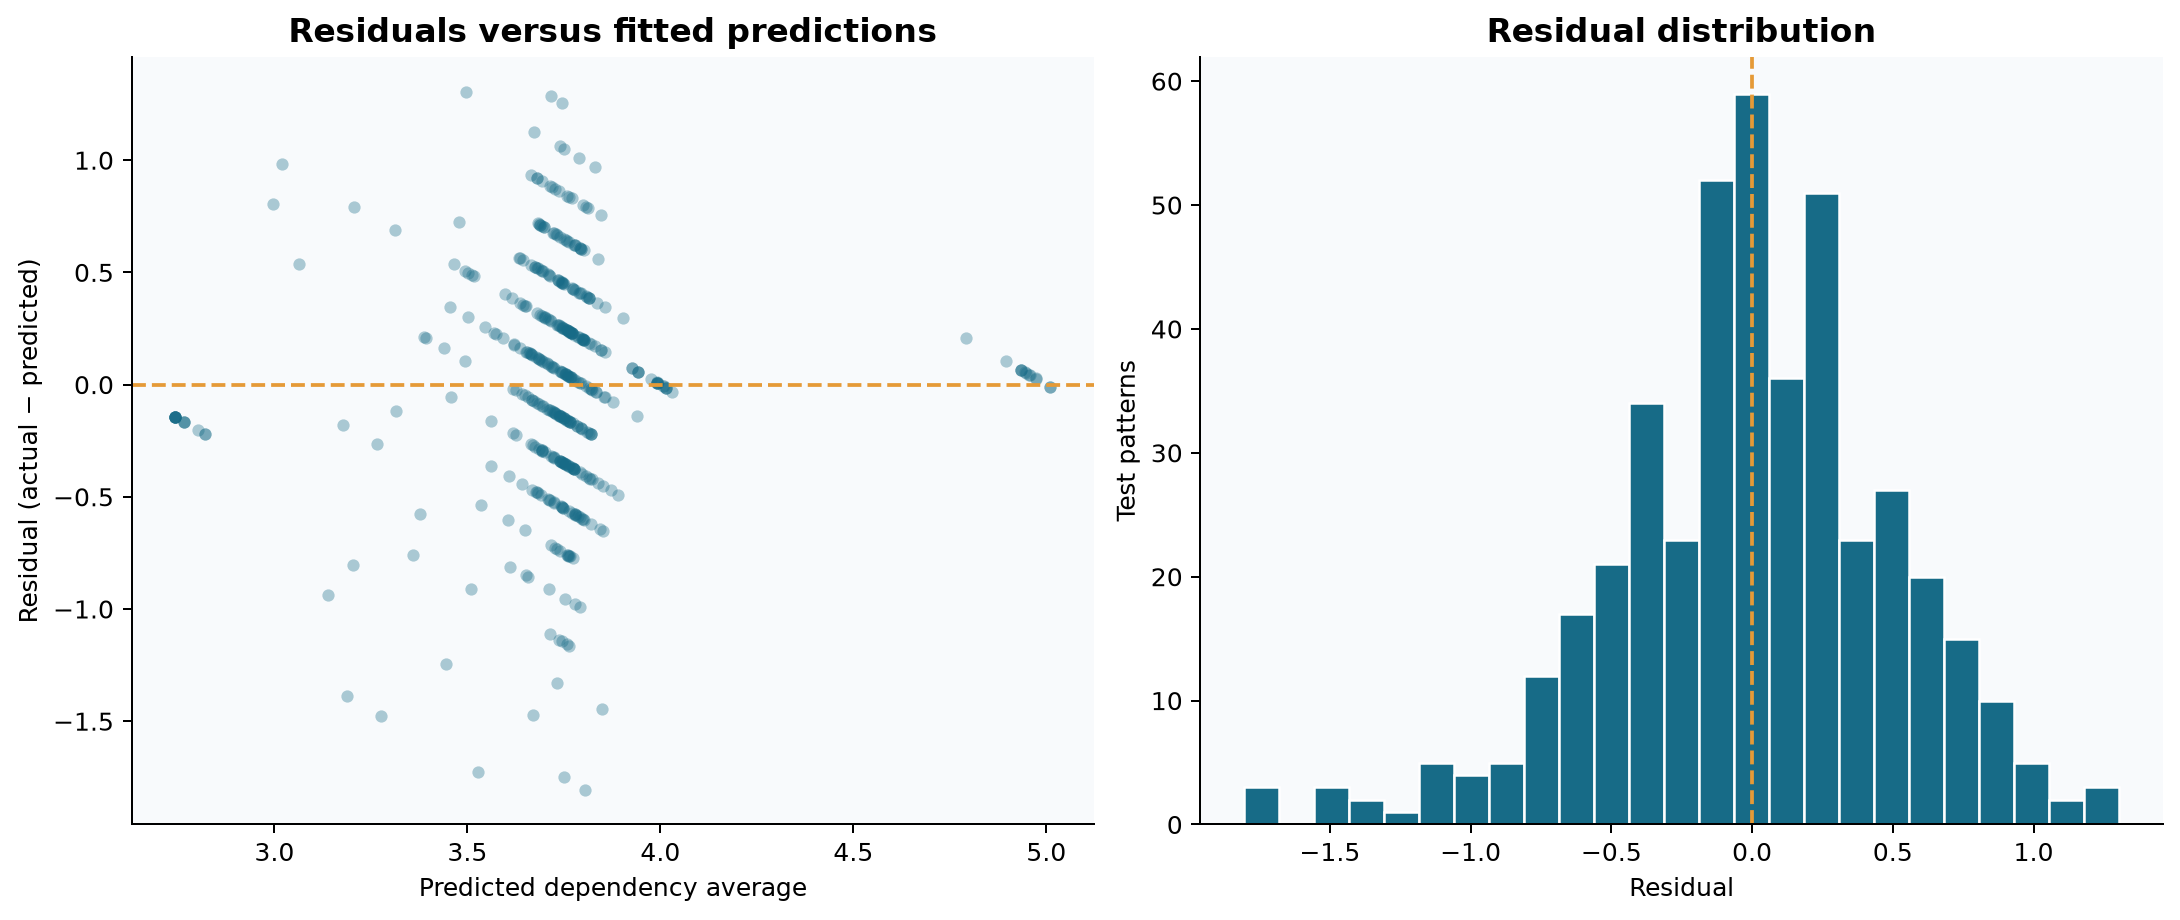

In [18]:
residuals = y_test.to_numpy() - best_predictions
errors = pd.DataFrame({"source_row_position": test_rows, "actual": y_test.to_numpy(),
                       "predicted": best_predictions, "residual": residuals,
                       "absolute_error": np.abs(residuals)})
errors.to_csv(DATA / "test_errors_local.csv", index=False)
largest_errors = errors.nlargest(10, "absolute_error")
largest_errors.to_csv(DATA / "largest_prediction_errors_local.csv", index=False)
residual_summary = errors[["residual", "absolute_error"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
save_table(residual_summary, "residual_summary.csv", index=True)
print("Residual summary:")
print(residual_summary.to_string())
print("Largest errors (local row positions only):")
print(largest_errors.to_string(index=False))
outside_bounds = int(((best_predictions < 1) | (best_predictions > 5)).sum())
print("Predictions outside theoretical range [1,5]:", outside_bounds)
print("Predictions are not clipped; metrics evaluate the fitted model directly.")

fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
ax.scatter(y_test, best_predictions, s=25, alpha=0.38, color=COLORS[0], linewidths=0)
ax.plot([1, 5], [1, 5], "--", color=COLORS[1], label="Perfect agreement")
ax.set(xlabel="Actual self-reported dependency average", ylabel="Predicted dependency average",
       title=f"{best_key[0]} | {best_key[1]}\nTest RMSE={best_result.Test_RMSE:.3f}, R²={best_result.Test_R2:.3f}")
ax.legend(frameon=False)
save_figure(fig, "09_actual_vs_predicted")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
axes[0].scatter(best_predictions, residuals, s=24, alpha=0.35, color=COLORS[0], linewidths=0)
axes[0].axhline(0, linestyle="--", color=COLORS[1])
axes[0].set(xlabel="Predicted dependency average", ylabel="Residual (actual − predicted)", title="Residuals versus fitted predictions")
axes[1].hist(residuals, bins=25, color=COLORS[0], edgecolor="white")
axes[1].axvline(0, linestyle="--", color=COLORS[1])
axes[1].set(xlabel="Residual", ylabel="Test patterns", title="Residual distribution")
save_figure(fig, "10_residuals")

error_by_actual = errors.groupby("actual", observed=True).agg(n=("actual", "size"),
    mean_residual=("residual", "mean"), MAE=("absolute_error", "mean")).reset_index()
save_table(error_by_actual, "errors_by_observed_target_value.csv")
print("Errors at each exact observed target value:")
print(error_by_actual.to_string(index=False))


**Output interpretation:** positive residuals mean underprediction; negative
ones mean overprediction. The exact-target summary can reveal errors near the
scale endpoints without inventing low/medium/high categories. Large errors
cannot diagnose respondents or demonstrate deficient cognition. Weak target
reliability, omitted influences and limited model flexibility are plausible
contributors, but this analysis does not establish their contribution.

## Phase 12 — Explainability with held-out permutation importance and optional SHAP

**Why this method:** permutation importance measures the increase in test RMSE
after shuffling one original input column while retaining the trained pipeline.
It works for every candidate and keeps each demographic feature's one-hot
columns together. Use 20 repeats with a fixed seed. Repeat SD is perturbation
variability, not a population confidence interval. Correlated predictors can
share importance; near-zero or negative values do not prove irrelevance.
[scikit-learn permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

For a selected tree, attempt SHAP with a training-only background and a fixed
test sample, verify that base value plus SHAP contributions reconstructs model
predictions, then create the summary plot. If unavailable or incompatible,
report the exception and retain the valid permutation analysis. If the winner
is linear or dummy, tree SHAP is inapplicable. Neither method estimates causes.


Selected model permutation importance:
                                                              feature  RMSE_increase_mean  RMSE_increase_sd
                                           Cognitive_Offloading_Index            0.058918          0.007863
                                                       AI_Trust_Index            0.041959          0.005979
                                                                  Age            0.004146          0.002090
                    AI Usage [I use AI tools for assignment writing.]            0.002199          0.000891
                                                Department/Discipline            0.002000          0.001592
                                                      University Type            0.001857          0.000820
                                              Academic_Decision_Index            0.001540          0.000903
                        AI Usage [I use AI tools for study planning.]            0.000808        

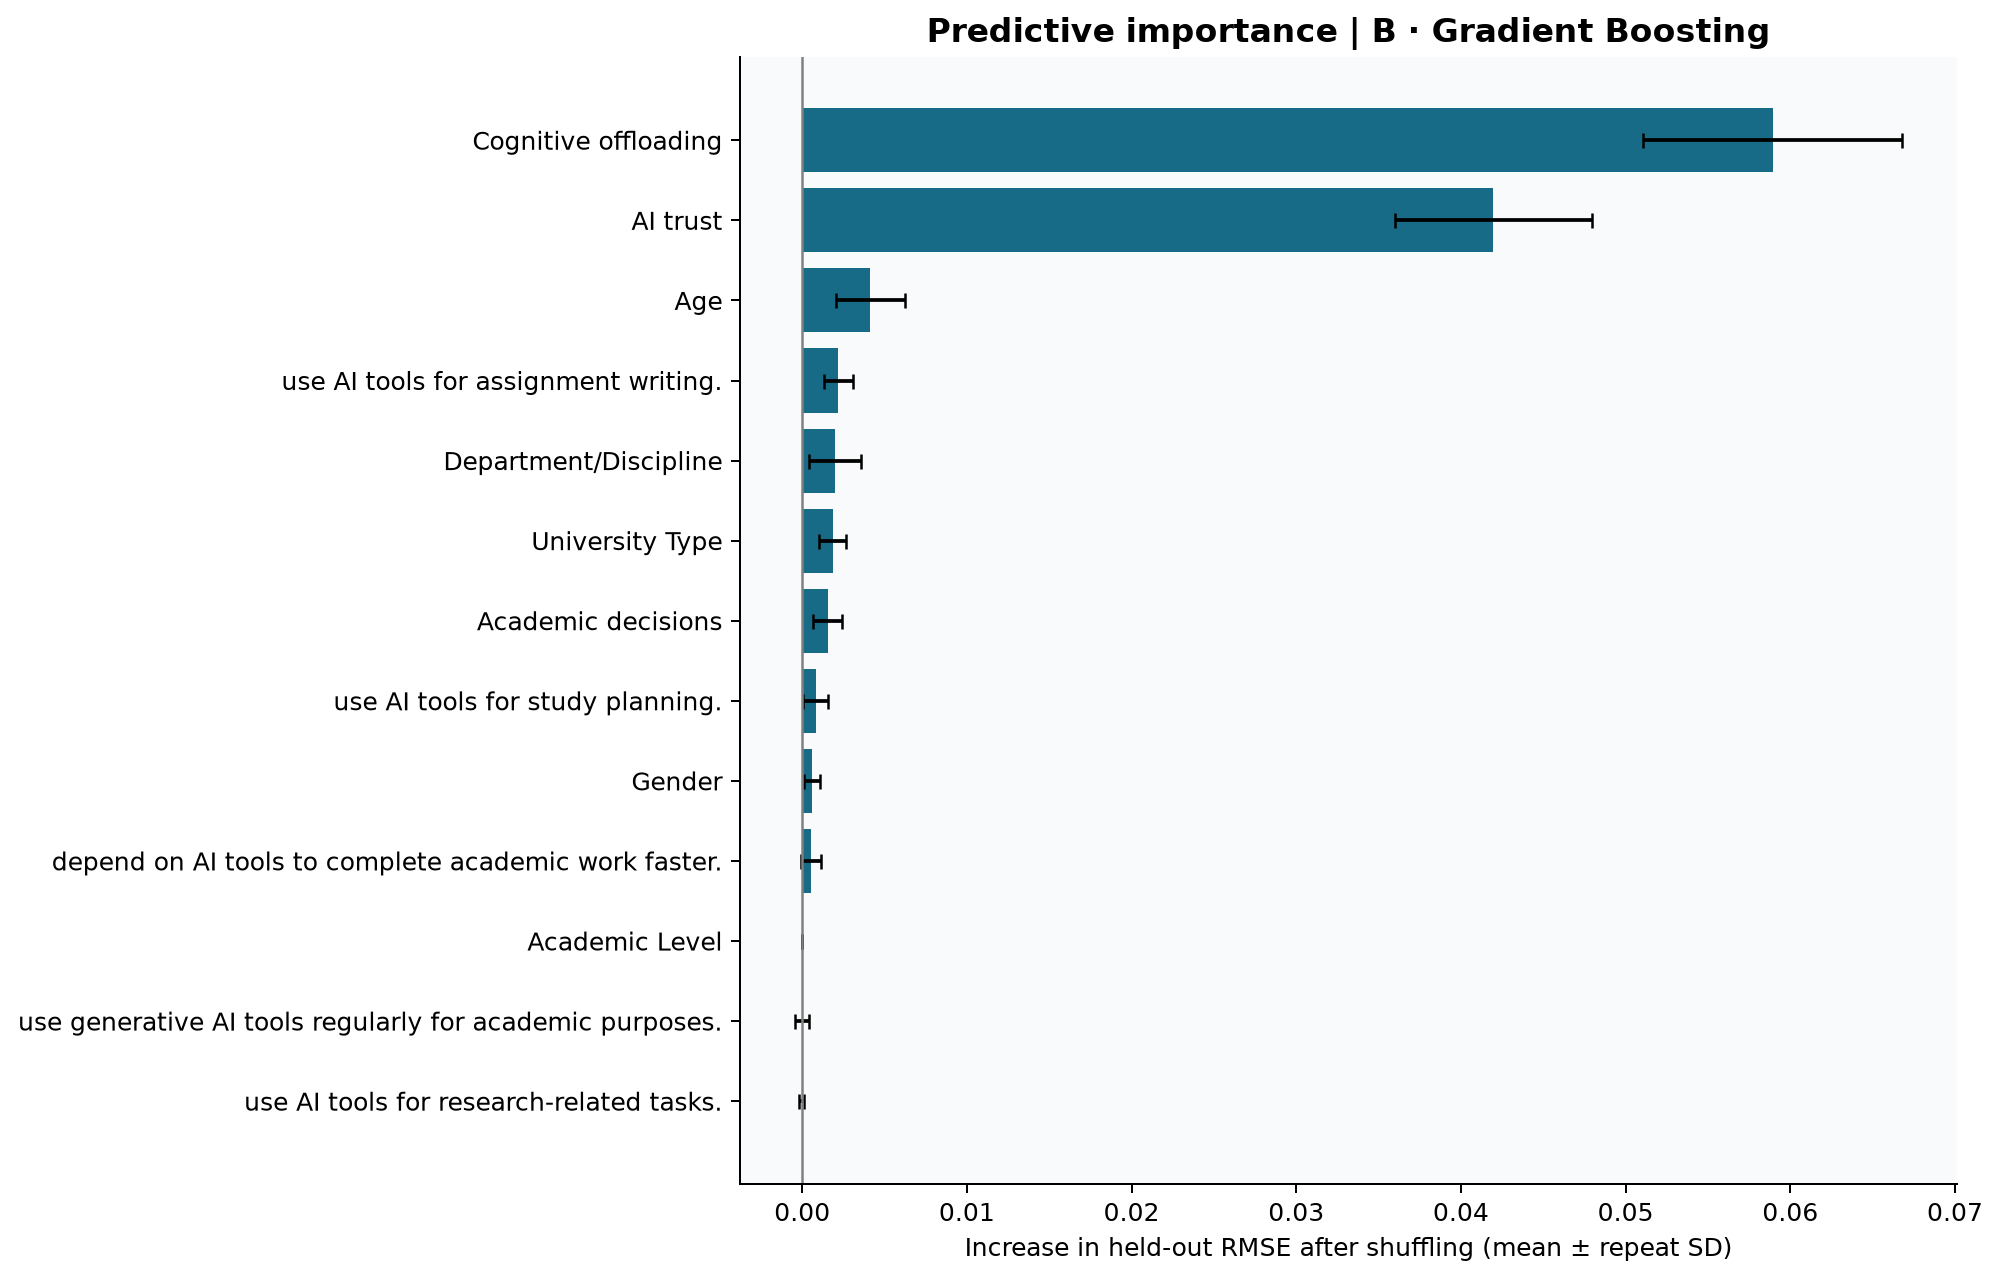

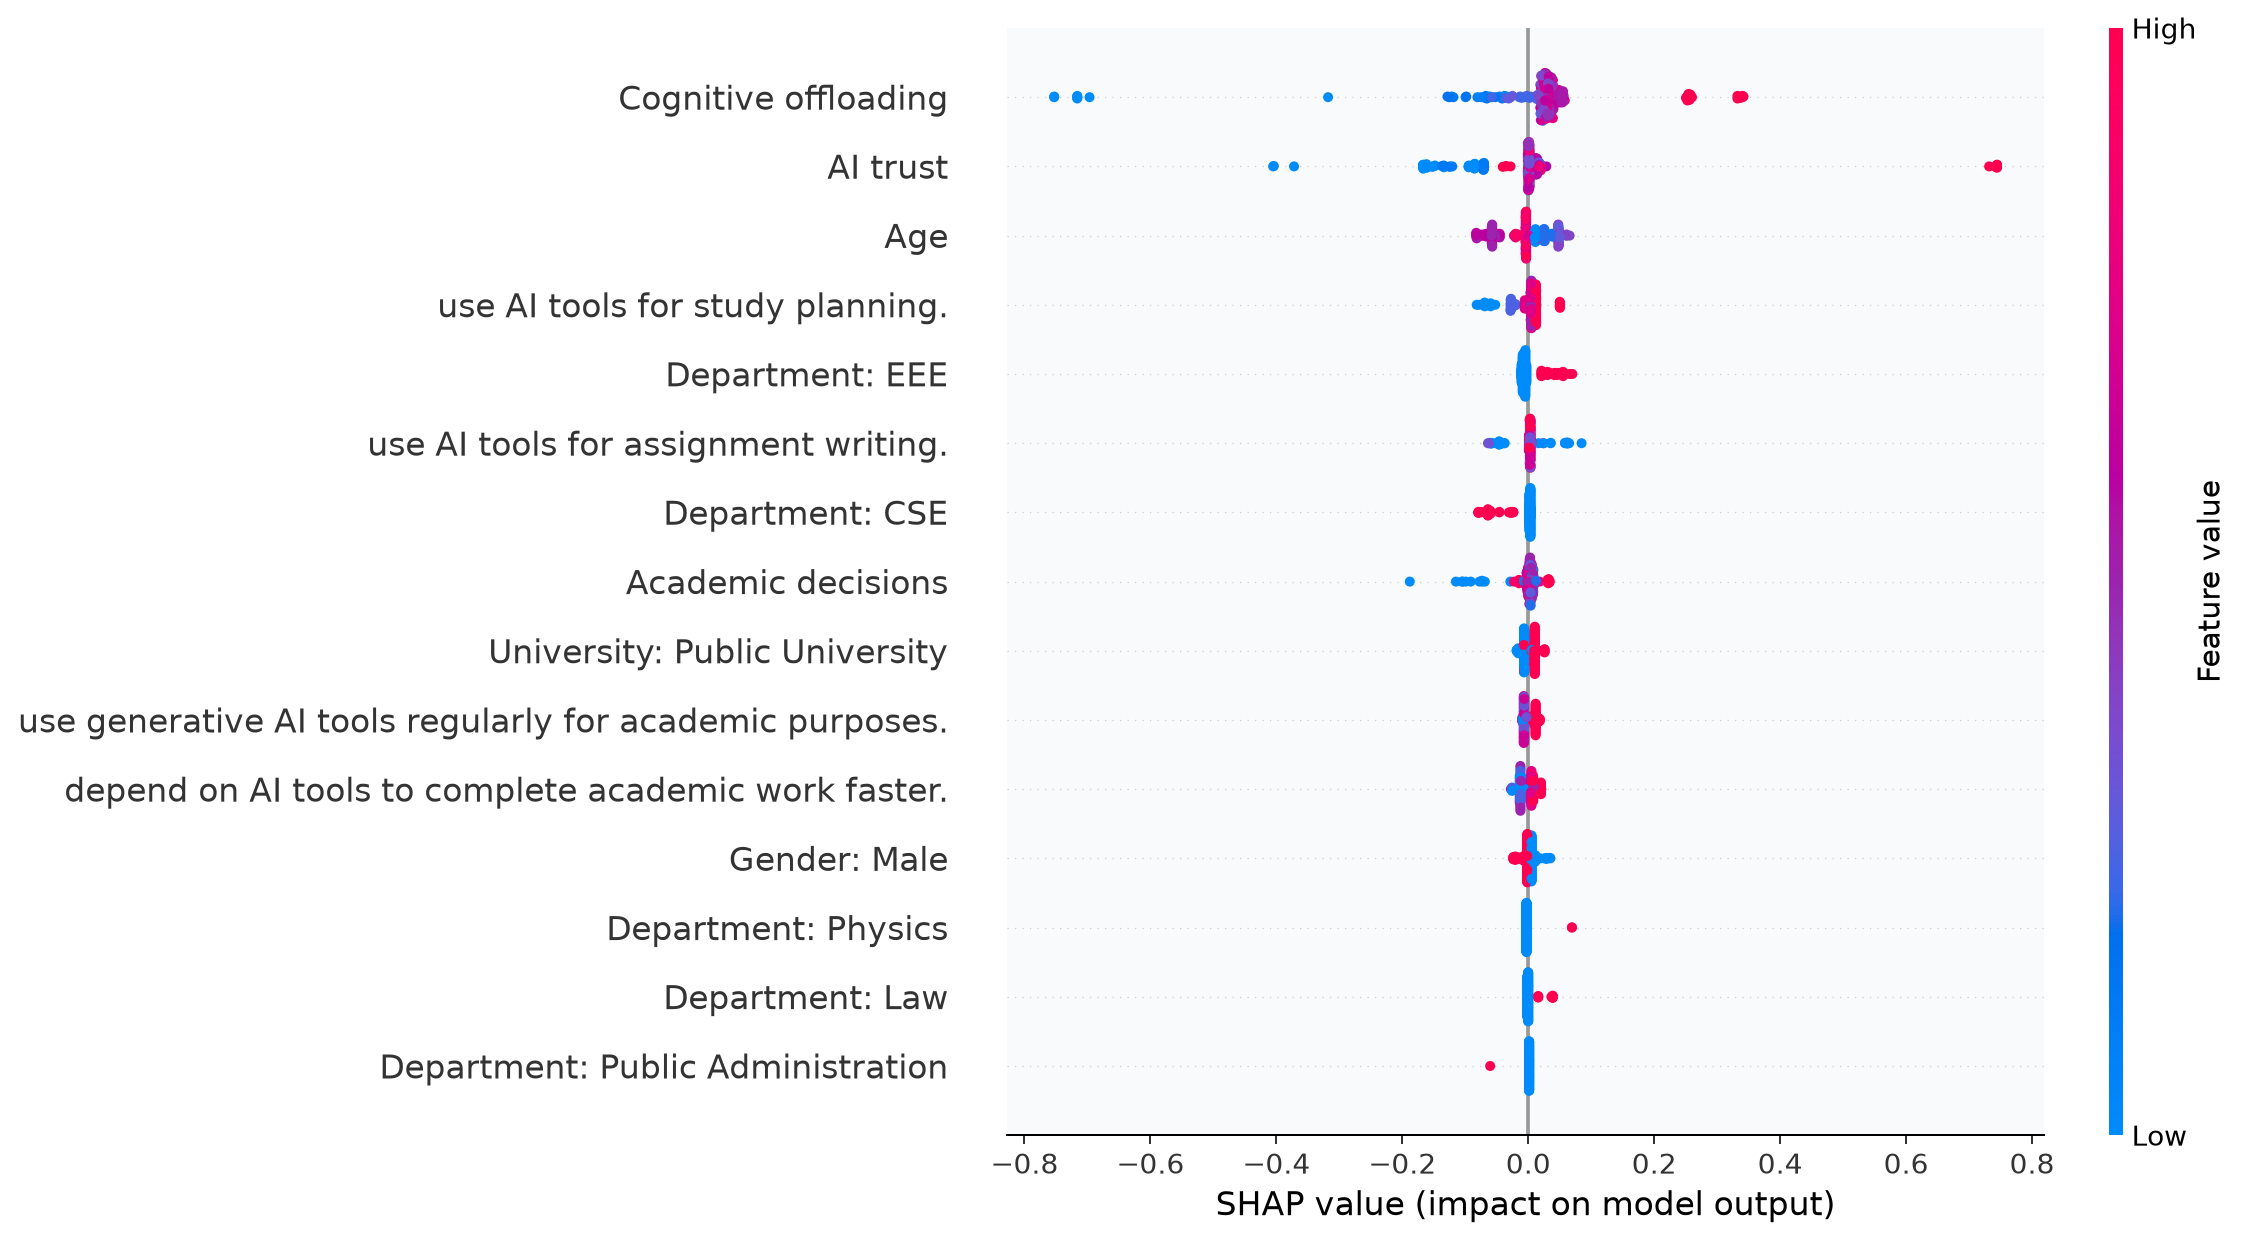

In [19]:
from sklearn.inspection import permutation_importance

def permutation_table(key):
    features = feature_sets[key[0]]
    with threadpool_limits(limits=2):
        result = permutation_importance(fitted_models[key], analysis_df.loc[test_rows, features], y_test,
            scoring="neg_root_mean_squared_error", n_repeats=20, random_state=SEED, n_jobs=1)
    return pd.DataFrame({"feature": features, "RMSE_increase_mean": result.importances_mean,
                         "RMSE_increase_sd": result.importances_std}).sort_values("RMSE_increase_mean", ascending=False)

importance = permutation_table(best_key)
importance_a = importance.copy() if best_a_key == best_key else permutation_table(best_a_key)
save_table(importance, "permutation_importance_best.csv")
save_table(importance_a, "permutation_importance_model_a.csv")
print("Selected model permutation importance:")
print(importance.to_string(index=False, float_format=lambda value: f"{value:.6f}"))
print("Model A permutation importance:")
print(importance_a.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

def readable_feature(name):
    if name in short_names:
        return short_names[name]
    if " [" in name:
        return name.split(" [", 1)[1].rstrip("]").replace("I ", "", 1)
    return name

fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
plot_importance = importance.head(13).sort_values("RMSE_increase_mean")
ax.barh([readable_feature(name) for name in plot_importance.feature], plot_importance.RMSE_increase_mean,
        xerr=plot_importance.RMSE_increase_sd, color=COLORS[0], capsize=3)
ax.axvline(0, color="gray", linewidth=1)
ax.set(xlabel="Increase in held-out RMSE after shuffling (mean ± repeat SD)",
       title=f"Predictive importance | {best_key[0]} · {best_key[1]}")
save_figure(fig, "11_permutation_importance")

shap_status = "Not attempted: the CV-selected estimator is not a tree model; permutation importance used."
shap_importance = None
selected_estimator = best_model.named_steps["model"]
if isinstance(selected_estimator, (RandomForestRegressor, GradientBoostingRegressor)):
    try:
        import shap
        transformer = best_model.named_steps["preprocessor"]
        background_raw = analysis_df.loc[train_rows, best_features].sample(n=min(100, len(train_rows)), random_state=SEED)
        explain_raw = X_test_best.sample(n=min(250, len(X_test_best)), random_state=SEED)
        background = np.asarray(transformer.transform(background_raw), dtype=float)
        explain_x = np.asarray(transformer.transform(explain_raw), dtype=float)
        feature_names = transformer.get_feature_names_out()
        with threadpool_limits(limits=2):
            explainer = shap.TreeExplainer(selected_estimator, data=background, feature_perturbation="interventional")
            explanation = explainer(explain_x, check_additivity=True)
        reconstructed = np.asarray(explanation.base_values).reshape(-1) + explanation.values.sum(axis=1)
        np.testing.assert_allclose(reconstructed, selected_estimator.predict(explain_x), rtol=1e-4, atol=1e-5)
        shap_importance = pd.DataFrame({"transformed_feature": feature_names,
            "mean_absolute_SHAP": np.abs(explanation.values).mean(axis=0)}).sort_values("mean_absolute_SHAP", ascending=False)
        save_table(shap_importance, "shap_importance_transformed.csv")
        display_names = [readable_feature(name.split("__", 1)[-1]) for name in feature_names]
        display_names = [name.replace("Department/Discipline_", "Department: ")
                             .replace("University Type_", "University: ")
                             .replace("Gender_", "Gender: ") for name in display_names]
        shap_plot_options = {}
        if "rng" in inspect.signature(shap.summary_plot).parameters:
            shap_plot_options["rng"] = np.random.default_rng(SEED)
        else:
            np.random.seed(SEED)
        shap.summary_plot(explanation.values, explain_x, feature_names=display_names,
                          max_display=15, show=False, plot_size=(13, 7), **shap_plot_options)
        save_figure(plt.gcf(), "12_shap_summary")
        shap_status = f"SHAP {shap.__version__} executed on {len(explain_x)} held-out patterns; additivity verified."
        print(shap_importance.head(15).to_string(index=False))
    except Exception as error:
        shap_status = f"SHAP unavailable/incompatible: {type(error).__name__}: {error}. Valid permutation importance is the alternative."
        plt.close("all")
print(shap_status)
(TABLES / "shap_status.txt").write_text(shap_status, encoding="utf-8")
print("Importance means useful to this prediction model, not a cause of AI dependency.")


**Output interpretation:** assess model performance before interpreting feature
rankings. A poorly predictive model cannot establish robust substantive
importance. SHAP, when successful, explains transformed features on the stated
test sample, whereas permutation importance ranks original input columns on the
full held-out set. Test explanations are descriptive and are not used to retune
or reselect the model.

## Phase 13 — Exploratory student-response profiles

**Why K-Means:** it provides a transparent exploratory partition of the five
numeric item averages. StandardScaler gives each index equal variance weight.
This is a separate descriptive unsupervised analysis of the full primary subset;
its scaler and labels never feed the regression. K-Means assumes Euclidean,
roughly compact groups and will partition data even without natural clusters.

Evaluate k=2–6 with 20 initializations and a fixed seed. Choose the largest
silhouette score among those candidates (smaller k wins an exact tie); report
inertia and all silhouette values. This is an explicit selection rule rather
than a subjective preferred profile count. PCA with two components is used
only for visualization after clustering in the original five standardized
dimensions. [scikit-learn silhouette guidance](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis)

Inspect original-scale centroids first; then use dependency-rank-relative names
that describe these fitted clusters only. No validated cutoffs or individual
diagnoses are created. Repeated 80% subsamples assess partition stability via
adjusted Rand agreement, which measures agreement rather than validity.


In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

cluster_scaler = StandardScaler()
cluster_x = cluster_scaler.fit_transform(analysis_df[index_columns])
cluster_candidates = {}
cluster_rows = []
with threadpool_limits(limits=2):
    for k in range(2, 7):
        candidate = KMeans(n_clusters=k, n_init=20, random_state=SEED)
        labels = candidate.fit_predict(cluster_x)
        cluster_candidates[k] = candidate
        cluster_rows.append({"k": k, "inertia": candidate.inertia_,
                             "silhouette": silhouette_score(cluster_x, labels)})
cluster_quality = pd.DataFrame(cluster_rows)
best_k = int(cluster_quality.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0].k)
kmeans = cluster_candidates[best_k]
cluster_labels = kmeans.labels_
# Use means of the final assigned members, in original units. This avoids tiny
# center/member discrepancies when K-Means stops at its convergence tolerance.
centroids = analysis_df[index_columns].groupby(cluster_labels).mean()
centroids.index.name = "cluster"
print("Candidate cluster quality:")
print(cluster_quality.to_string(index=False))
print("Selected k:", best_k)
print("Original-scale centroids BEFORE assigning descriptive names:")
print(centroids.to_string())
save_table(cluster_quality, "cluster_quality.csv")
save_table(centroids, "cluster_centroids_original_scale.csv", index=True)


Candidate cluster quality:
 k     inertia  silhouette
 2 8631.021733    0.169327
 3 7360.443595    0.223357
 4 6480.810568    0.187369
 5 5821.585058    0.193252
 6 5266.397364    0.201604
Selected k: 3
Original-scale centroids BEFORE assigning descriptive names:
         AI_Usage_Index  AI_Dependency_Index  AI_Trust_Index  Cognitive_Offloading_Index  Academic_Decision_Index
cluster                                                                                                          
0              3.744192             3.835052        3.865567                    3.823230                 3.734845
1              3.665200             3.124400        3.138400                    3.083600                 3.697600
2              4.724638             4.374879        4.496618                    4.890821                 4.285990


**Output interpretation before naming:** each centroid is a within-cluster mean
on the original 1–5 response scale. Compare all five coordinates; a silhouette
near zero suggests overlap and weak separation, even when it is the largest
among the tested k values. The next cell names clusters by their observed
dependency-centroid rank and states their complete profiles numerically.


                                        profile     n  AI_Usage_Index  AI_Dependency_Index  AI_Trust_Index  Cognitive_Offloading_Index  Academic_Decision_Index
cluster                                                                                                                                                        
0        Intermediate dependency profile 2 of 3  1455        3.744192             3.835052        3.865567                    3.823230                 3.734845
1           Relatively lower dependency profile   500        3.665200             3.124400        3.138400                    3.083600                 3.697600
2          Relatively higher dependency profile   207        4.724638             4.374879        4.496618                    4.890821                 4.285990
Cluster 0: Intermediate dependency profile 2 of 3 (n=1455): AI usage=3.74, AI dependency=3.84, AI trust=3.87, Cognitive offloading=3.82, Academic decisions=3.73.
Cluster 1: Relatively lower dependency

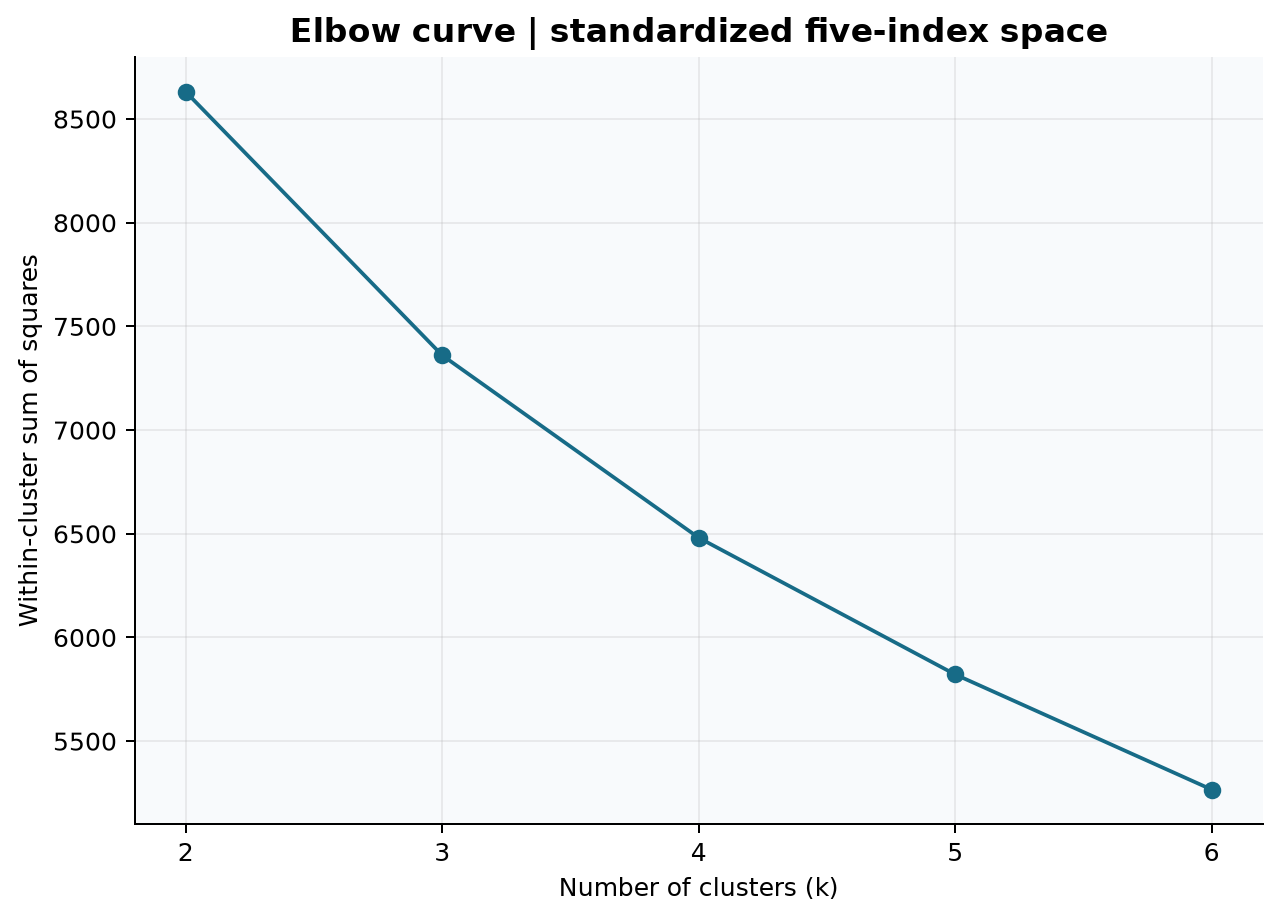

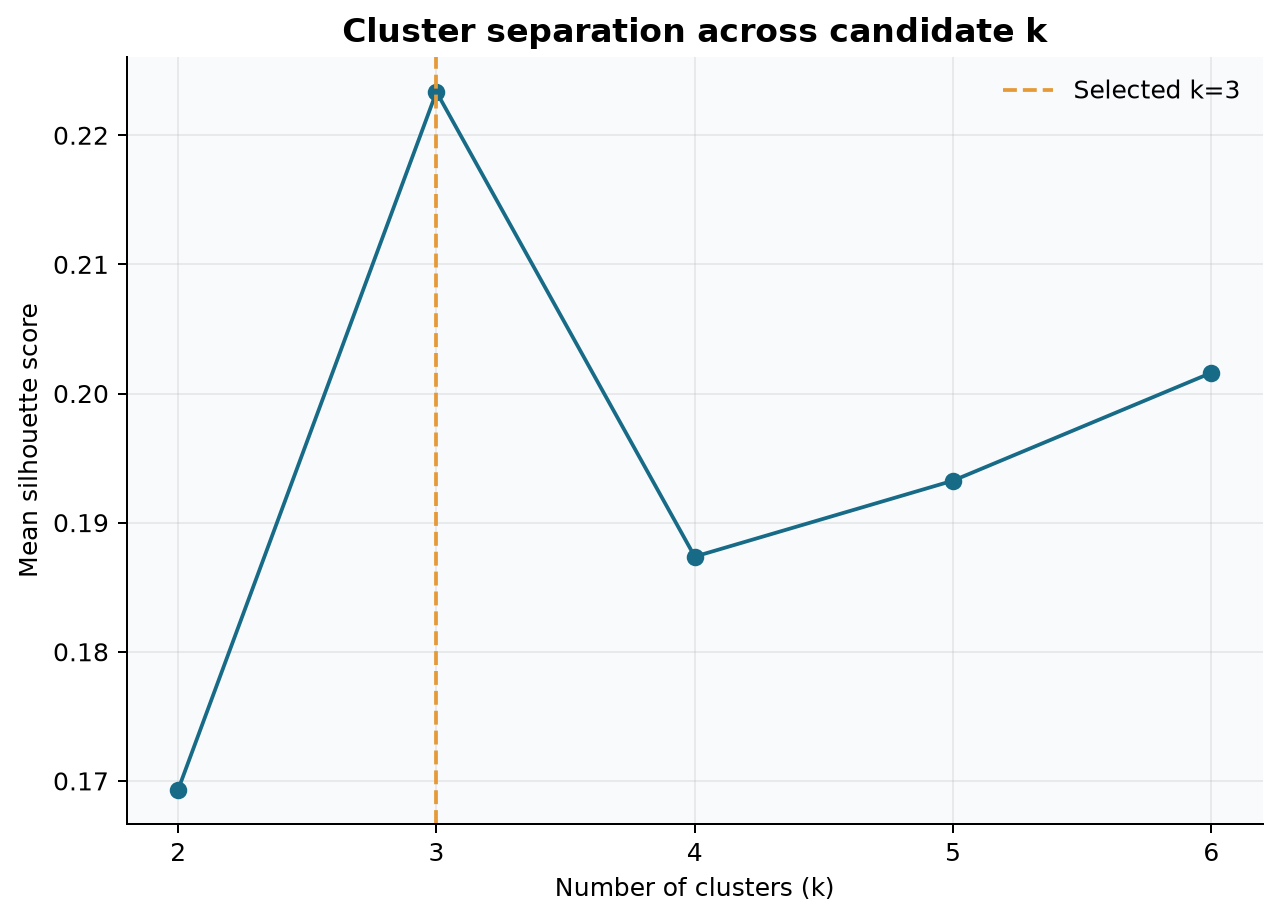

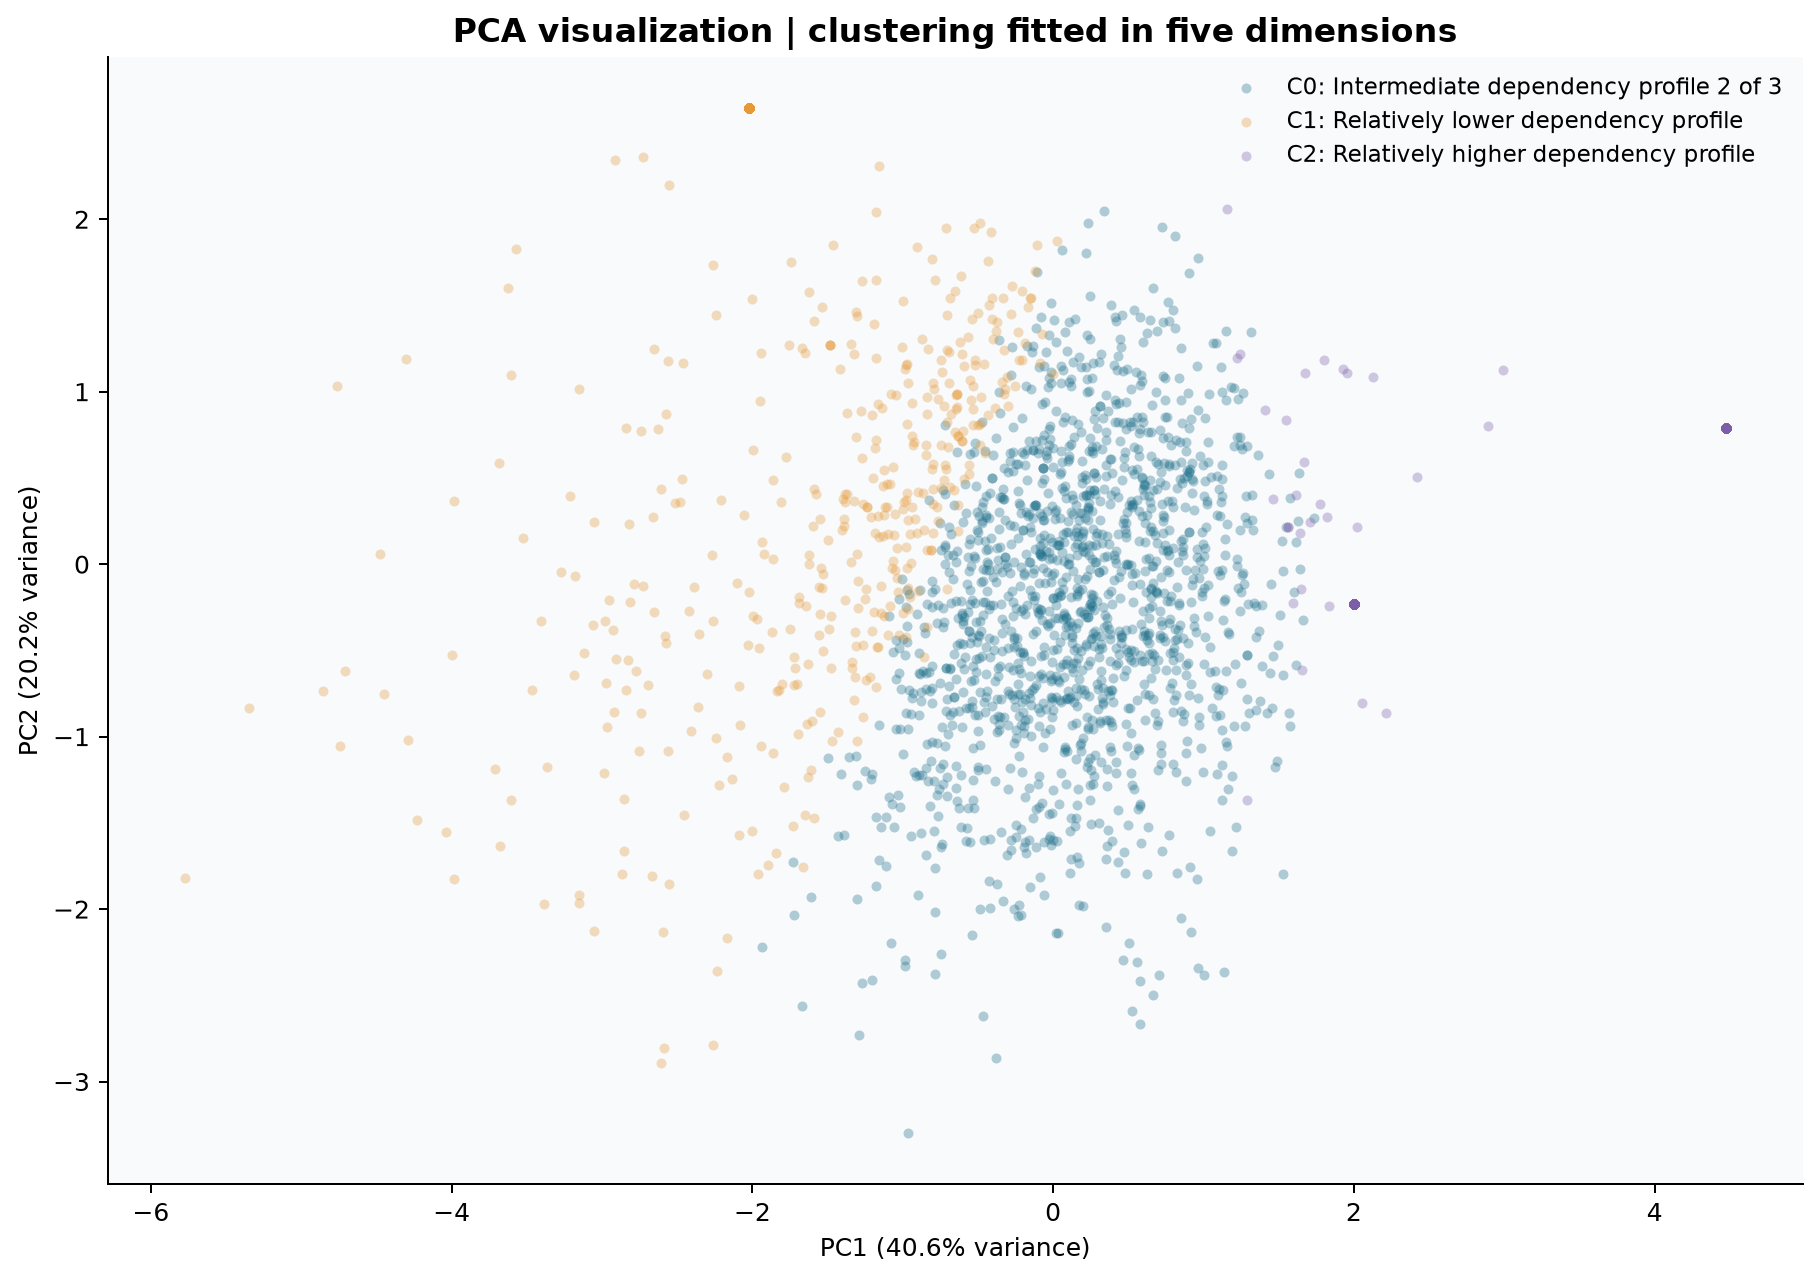

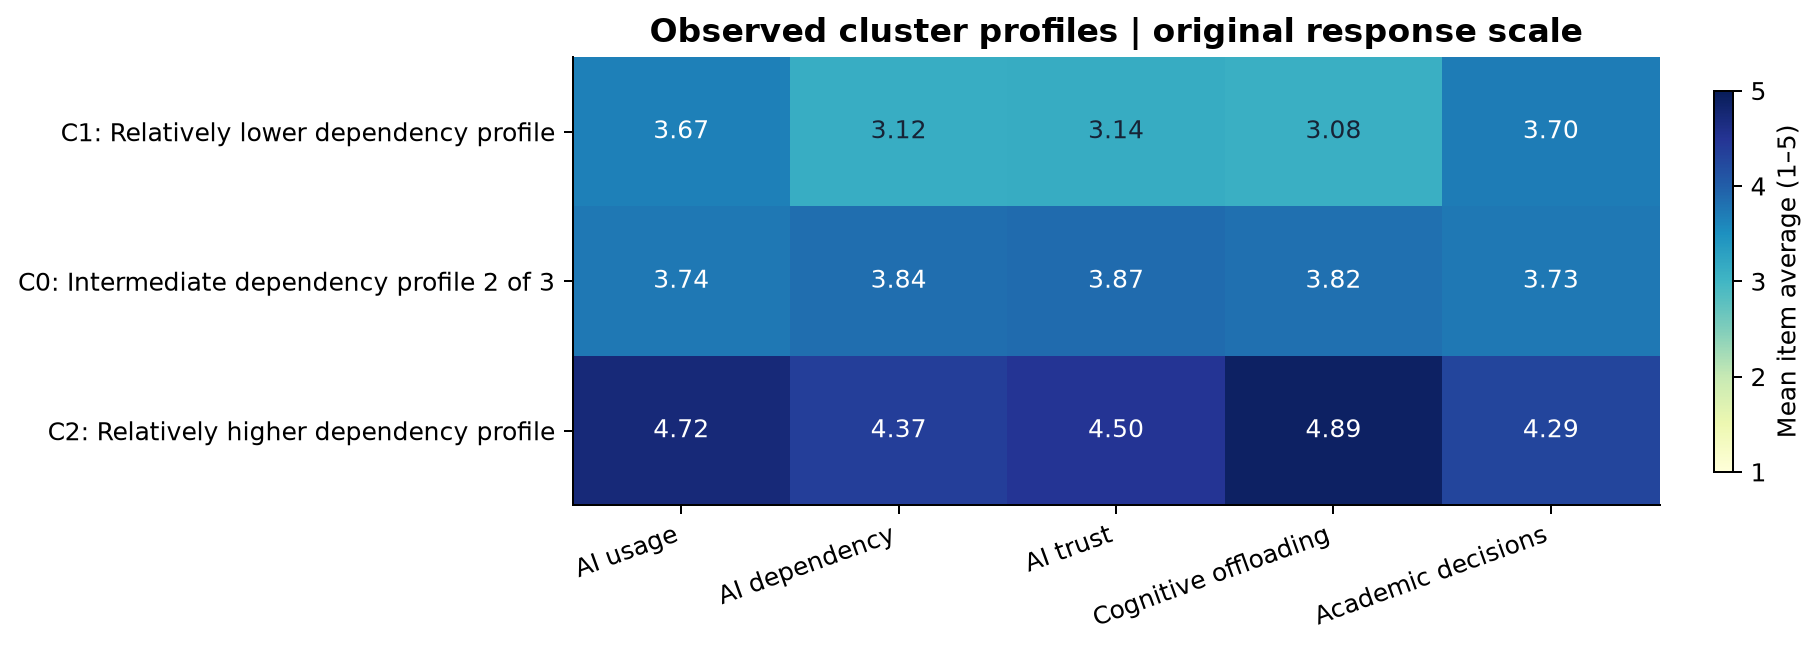

In [21]:
dependency_order = centroids[target_name].sort_values().index.tolist()
cluster_names = {}
for rank, cluster in enumerate(dependency_order, start=1):
    if rank == 1:
        name = "Relatively lower dependency profile"
    elif rank == best_k:
        name = "Relatively higher dependency profile"
    else:
        name = f"Intermediate dependency profile {rank} of {best_k}"
    cluster_names[int(cluster)] = name
cluster_profiles = centroids.copy()
cluster_profiles.insert(0, "profile", [cluster_names[int(cluster)] for cluster in cluster_profiles.index])
cluster_profiles.insert(1, "n", pd.Series(cluster_labels).value_counts().reindex(cluster_profiles.index).to_numpy())
save_table(cluster_profiles, "cluster_profiles.csv", index=True)
cluster_assignments = analysis_df[index_columns].copy()
cluster_assignments.insert(0, "source_row_position", analysis_df.index)
cluster_assignments["cluster"] = cluster_labels
cluster_assignments["profile"] = [cluster_names[int(cluster)] for cluster in cluster_labels]
cluster_assignments.to_csv(DATA / "cluster_assignments_local.csv", index=False)
print(cluster_profiles.to_string())
for cluster, row in cluster_profiles.iterrows():
    details = ", ".join(f"{short_names[column]}={row[column]:.2f}" for column in index_columns)
    print(f"Cluster {cluster}: {row['profile']} (n={row['n']}): {details}.")

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.plot(cluster_quality.k, cluster_quality.inertia, "o-", color=COLORS[0])
ax.set(xticks=cluster_quality.k, xlabel="Number of clusters (k)", ylabel="Within-cluster sum of squares",
       title="Elbow curve | standardized five-index space")
ax.grid()
save_figure(fig, "13_elbow_curve")
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.plot(cluster_quality.k, cluster_quality.silhouette, "o-", color=COLORS[0])
ax.axvline(best_k, color=COLORS[1], linestyle="--", label=f"Selected k={best_k}")
ax.set(xticks=cluster_quality.k, xlabel="Number of clusters (k)", ylabel="Mean silhouette score", title="Cluster separation across candidate k")
ax.grid()
ax.legend(frameon=False)
save_figure(fig, "14_silhouette_scores")

pca = PCA(n_components=2, random_state=SEED)
pca_coordinates = pca.fit_transform(cluster_x)
fig, ax = plt.subplots(figsize=(10, 7), layout="constrained")
for cluster in range(best_k):
    mask = cluster_labels == cluster
    ax.scatter(pca_coordinates[mask, 0], pca_coordinates[mask, 1], s=16, alpha=0.33,
               color=COLORS[cluster % len(COLORS)], label=f"C{cluster}: {cluster_names[cluster]}", linewidths=0)
ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
       title="PCA visualization | clustering fitted in five dimensions")
ax.legend(frameon=False, fontsize=9)
save_figure(fig, "15_pca_clusters")

fig, ax = plt.subplots(figsize=(10, max(3.5, best_k * 0.85)), layout="constrained")
ordered_centroids = centroids.loc[dependency_order]
im = ax.imshow(ordered_centroids, cmap="YlGnBu", vmin=1, vmax=5, aspect="auto")
ax.set_xticks(range(5), [short_names[column] for column in index_columns], rotation=20, ha="right")
ax.set_yticks(range(best_k), [f"C{cluster}: {cluster_names[int(cluster)]}" for cluster in dependency_order])
for row in range(best_k):
    for column in range(5):
        value = ordered_centroids.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", color="white" if value > 3.5 else "#172336")
ax.set_title("Observed cluster profiles | original response scale")
fig.colorbar(im, ax=ax, label="Mean item average (1–5)", shrink=0.85)
save_figure(fig, "16_cluster_profiles")

stability_rows = []
cluster_rng = np.random.default_rng(SEED)
with threadpool_limits(limits=2):
    for repetition in range(10):
        sampled_positions = cluster_rng.choice(len(analysis_df), size=int(0.8 * len(analysis_df)), replace=False)
        sample_scaler = StandardScaler().fit(analysis_df[index_columns].iloc[sampled_positions])
        sample_x = sample_scaler.transform(analysis_df[index_columns].iloc[sampled_positions])
        sample_model = KMeans(n_clusters=best_k, n_init=20, random_state=SEED).fit(sample_x)
        full_assignment = sample_model.predict(sample_scaler.transform(analysis_df[index_columns]))
        stability_rows.append({"repeat": repetition + 1,
            "adjusted_rand_vs_full_partition": adjusted_rand_score(cluster_labels, full_assignment)})
stability = pd.DataFrame(stability_rows)
save_table(stability, "cluster_subsample_stability.csv")
print("PCA variance retained:", pca.explained_variance_ratio_.sum())
print("Subsample partition agreement (descriptive, not independent validation):")
print(stability.describe().to_string())
joblib.dump({"scaler": cluster_scaler, "kmeans": kmeans, "pca": pca,
             "features": index_columns, "names": cluster_names}, MODELS / "clustering_bundle.joblib")


**Output interpretation:** names are relative to these fitted centroids, not
low/medium/high dependency cutoffs. K-Means assignments are exploratory profile
memberships, not diagnoses or supervised classification targets. Resampling
agreement and silhouette address different questions; a stable partition can
still describe overlapping rather than naturally distinct groups.

## Supplementary enhancement analyses

**Objective:** implement the feasible improvements using the current data while
keeping the original primary analysis unchanged. These diagnostics remain
exploratory because the item averages are weakly reliable and Likert responses
are ordinal. They do not repair measurement validity, identify duplicate people,
or provide external validation.

1. **Measurement diagnostics:** display item-level Spearman correlations and
run a seeded parallel-analysis screen followed by exploratory FactorAnalysis.
The factor model treats coded responses as approximately continuous, so it is a
screening tool; confirmatory work should use a new, validated instrument and an
appropriate ordinal-factor model.
2. **Training-only tuning:** use RandomizedSearchCV for Model A's Random Forest
and Model B's Gradient Boosting pipeline. The fixed test set is deliberately
excluded. These results therefore do not replace the preregistered-style primary
comparison or provide a new final test score.
3. **Alternative clustering:** compare Ward agglomerative clustering and Gaussian
mixtures with K-Means using the same standardized five-index data. Silhouette
quantifies separation; Gaussian-mixture BIC is an internal fit criterion. Neither
method can validate naturally occurring student types.


Parallel-analysis screening results:
construct
AI_Dependency_Index           1
AI_Trust_Index                1
AI_Usage_Index                1
Academic_Decision_Index       2
Cognitive_Offloading_Index    1
Factor loadings are exploratory approximate-continuous results, not validated ordinal EFA.
Training-only tuning results; the held-out test set was not used:
             search  n_candidates  best_training_CV_RMSE                                                                                                                           best_parameters
    A_Random_Forest             8               0.502854                             {"model__n_estimators": 180, "model__min_samples_leaf": 2, "model__max_features": 0.7, "model__max_depth": 6}
B_Gradient_Boosting             8               0.495125 {"model__subsample": 1.0, "model__n_estimators": 160, "model__min_samples_leaf": 12, "model__max_depth": 3, "model__learning_rate": 0.02}
Alternative clustering comparison:
            meth

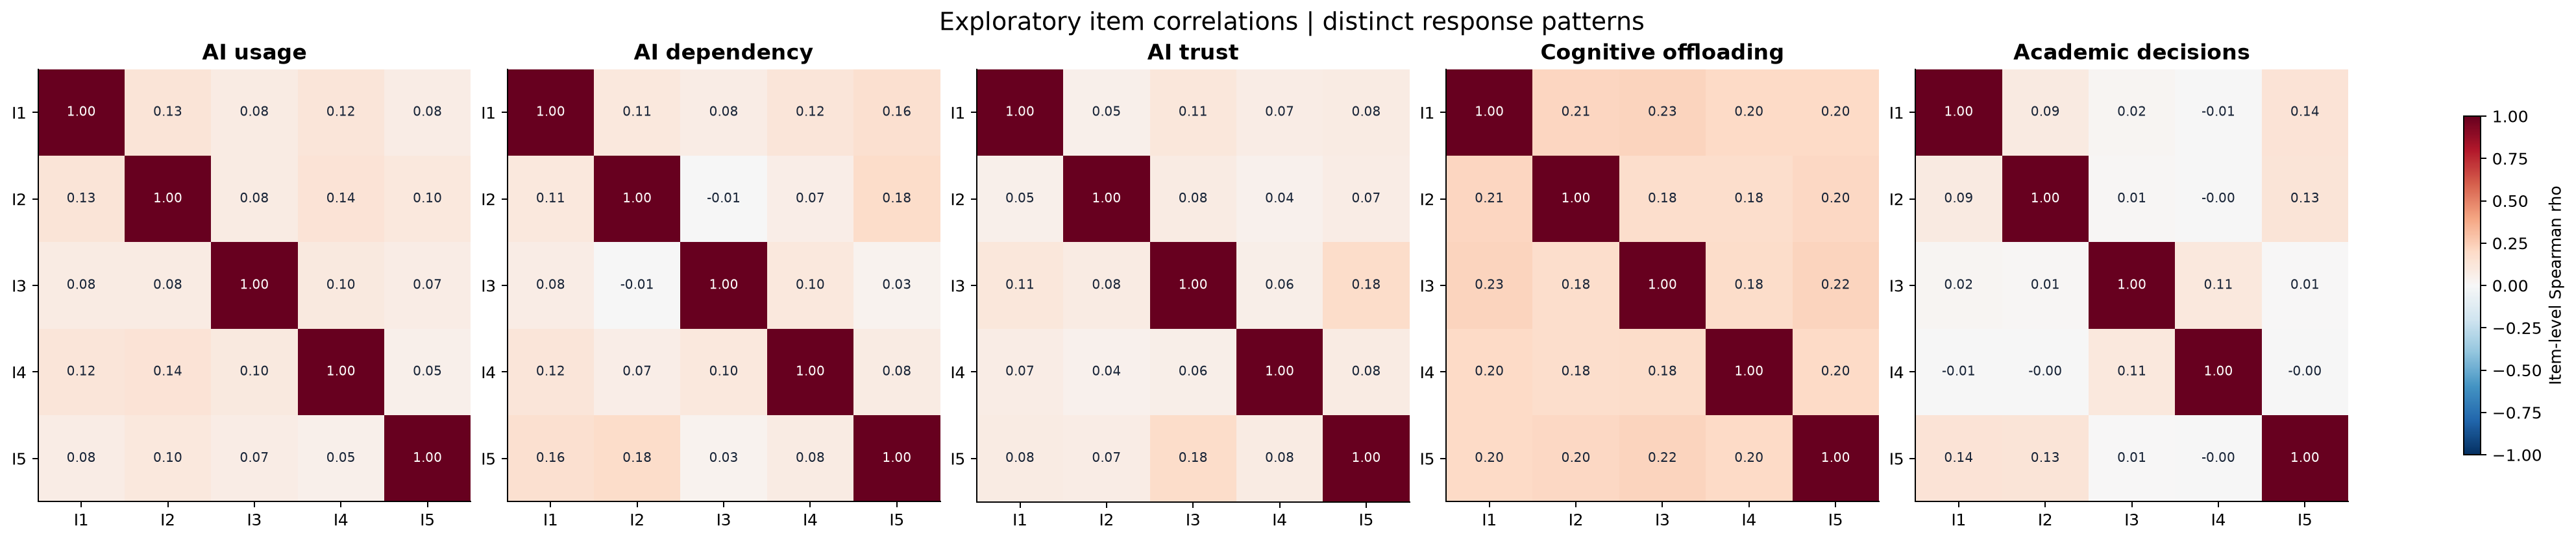

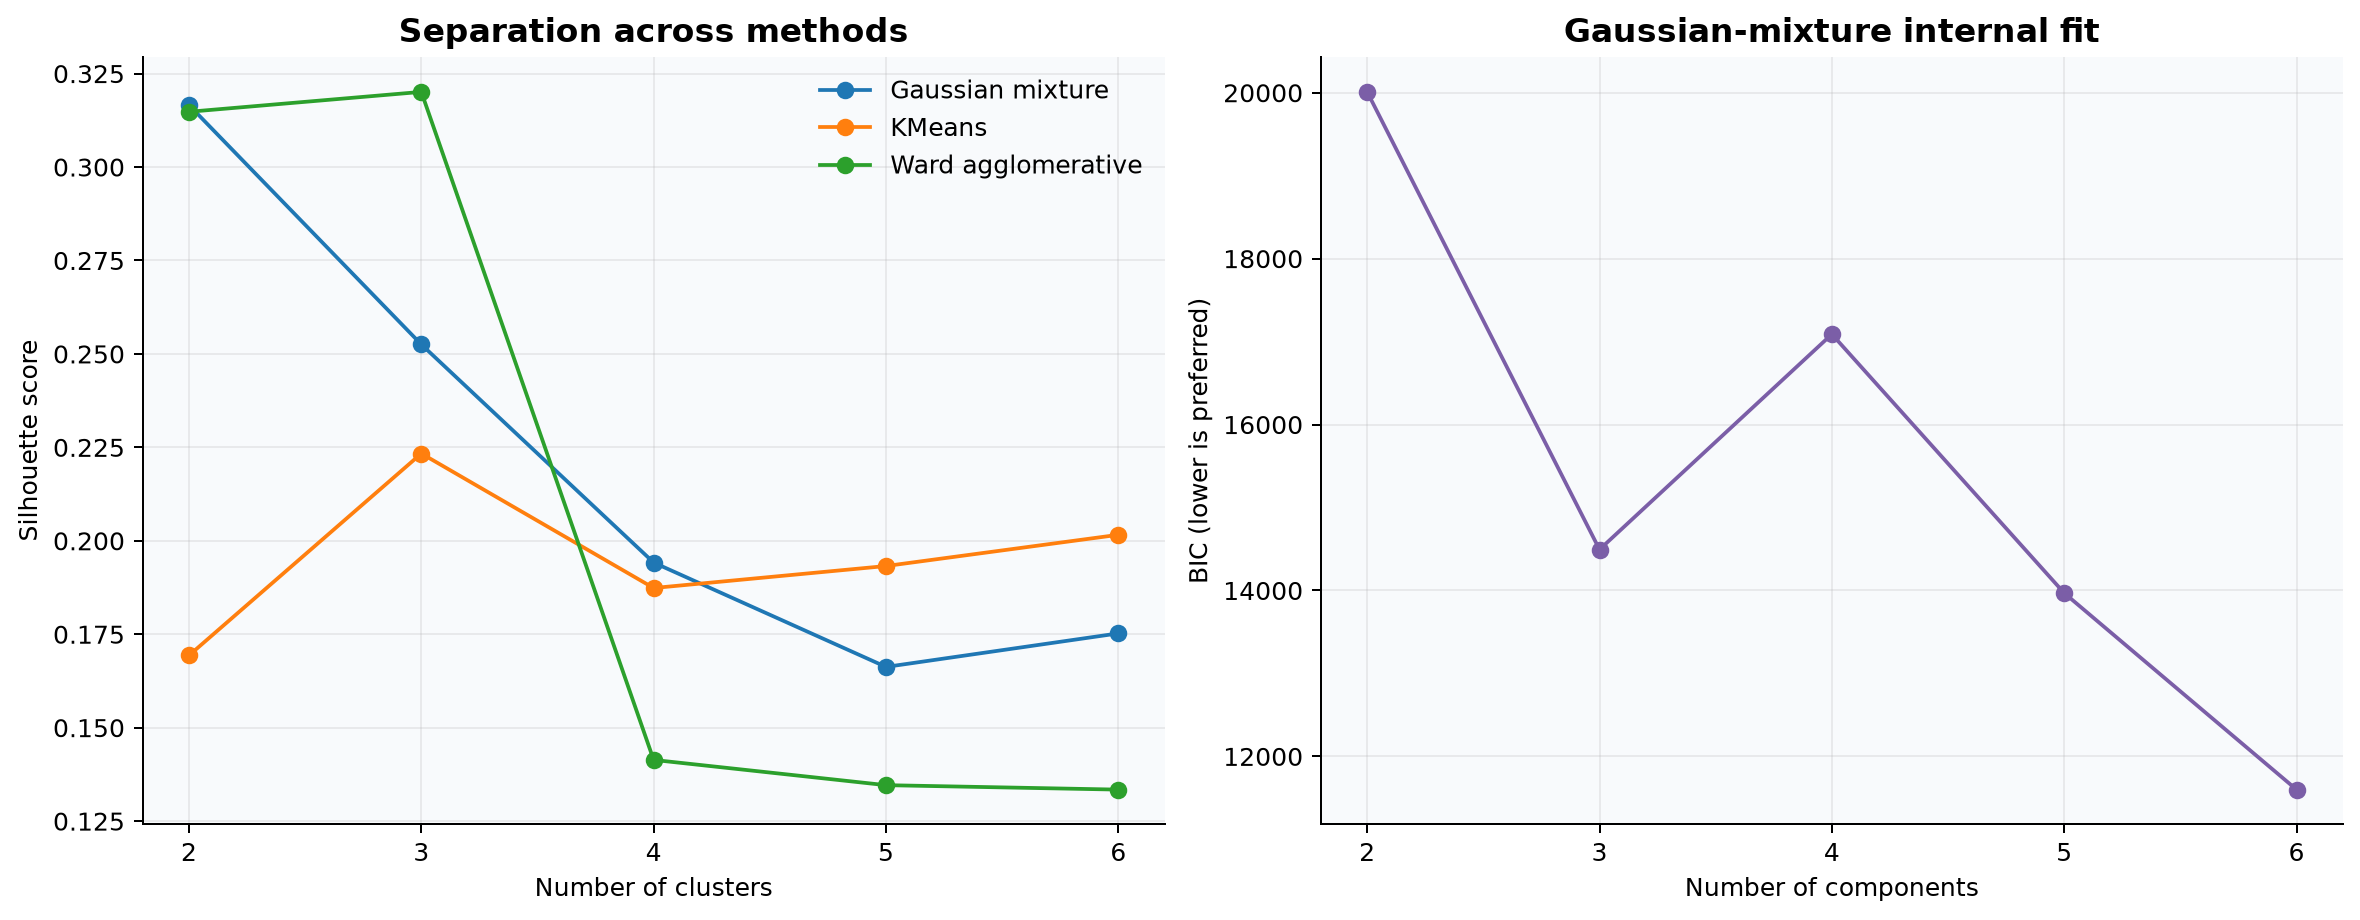

In [22]:
from sklearn.decomposition import FactorAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# 1. Item-level diagnostic correlations and approximate parallel analysis.
measurement_rows = []
loading_rows = []
measurement_rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, len(constructs), figsize=(22, 4.5), layout="constrained")
for ax, (index_name, item_columns) in zip(axes, constructs.items()):
    item_frame = analysis_df[item_columns]
    spearman_items = item_frame.corr(method="spearman")
    observed_eigenvalues = np.linalg.eigvalsh(np.corrcoef(item_frame.to_numpy(dtype=float), rowvar=False))[::-1]
    random_eigenvalues = []
    for _ in range(200):
        random_data = measurement_rng.normal(size=item_frame.shape)
        random_eigenvalues.append(np.linalg.eigvalsh(np.corrcoef(random_data, rowvar=False))[::-1])
    parallel_threshold = np.quantile(np.asarray(random_eigenvalues), 0.95, axis=0)
    suggested_factors = max(1, int(np.sum(observed_eigenvalues > parallel_threshold)))
    factor_input = StandardScaler().fit_transform(item_frame)
    factor_model = FactorAnalysis(n_components=suggested_factors, random_state=SEED).fit(factor_input)
    for factor_number, loading_vector in enumerate(factor_model.components_, start=1):
        for item, loading in zip(item_columns, loading_vector):
            loading_rows.append({"construct": index_name, "factor": factor_number,
                                 "item": item, "loading": loading})
    for number, (observed, threshold) in enumerate(zip(observed_eigenvalues, parallel_threshold), start=1):
        measurement_rows.append({"construct": index_name, "component": number,
                                 "observed_eigenvalue": observed,
                                 "parallel_95th_percentile": threshold,
                                 "retained_by_parallel_analysis": observed > threshold,
                                 "suggested_factor_count": suggested_factors})
    image = ax.imshow(spearman_items, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set(title=short_names[index_name], xticks=range(5), yticks=range(5))
    ax.set_xticklabels([f"I{i}" for i in range(1, 6)])
    ax.set_yticklabels([f"I{i}" for i in range(1, 6)])
    for row in range(5):
        for column in range(5):
            ax.text(column, row, f"{spearman_items.iloc[row, column]:.2f}", ha="center", va="center",
                    color="white" if abs(spearman_items.iloc[row, column]) > 0.55 else "#172336", fontsize=8)
fig.colorbar(image, ax=axes, label="Item-level Spearman rho", shrink=0.75)
fig.suptitle("Exploratory item correlations | distinct response patterns", fontsize=15)
save_figure(fig, "17_item_correlations")
measurement_diagnostics = pd.DataFrame(measurement_rows)
factor_loadings = pd.DataFrame(loading_rows)
save_table(measurement_diagnostics, "measurement_parallel_analysis.csv")
save_table(factor_loadings, "exploratory_factor_loadings.csv")
print("Parallel-analysis screening results:")
print(measurement_diagnostics.groupby("construct", observed=True)["suggested_factor_count"].first().to_string())
print("Factor loadings are exploratory approximate-continuous results, not validated ordinal EFA.")

# 2. Training-only model tuning. No held-out test prediction is calculated here.
tuning_specs = {
    "A_Random_Forest": {
        "features": feature_sets["A"],
        "estimator": RandomForestRegressor(random_state=SEED, n_jobs=1),
        "parameters": {
            "model__n_estimators": [120, 180, 240],
            "model__max_depth": [None, 6, 12],
            "model__min_samples_leaf": [2, 5, 10],
            "model__max_features": [0.7, 1.0],
        },
    },
    "B_Gradient_Boosting": {
        "features": feature_sets["B"],
        "estimator": GradientBoostingRegressor(random_state=SEED),
        "parameters": {
            "model__n_estimators": [100, 160, 220],
            "model__learning_rate": [0.02, 0.05, 0.08],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [5, 8, 12],
            "model__subsample": [0.8, 1.0],
        },
    },
}
tuning_rows = []
tuned_models = {}
with threadpool_limits(limits=2):
    for label, specification in tuning_specs.items():
        pipeline = Pipeline([("preprocessor", make_preprocessor(specification["features"])),
                             ("model", specification["estimator"])])
        search = RandomizedSearchCV(pipeline, specification["parameters"], n_iter=8,
            scoring="neg_root_mean_squared_error", cv=cv_splits, random_state=SEED,
            n_jobs=1, refit=True, return_train_score=False)
        search.fit(analysis_df.loc[train_rows, specification["features"]], y_train)
        tuned_models[label] = search.best_estimator_
        tuning_rows.append({"search": label, "n_candidates": 8,
            "best_training_CV_RMSE": -search.best_score_, "best_parameters": json.dumps(search.best_params_)})
        joblib.dump(search.best_estimator_, MODELS / f"{label.lower()}_training_cv_tuned.joblib")
tuning_results = pd.DataFrame(tuning_rows)
save_table(tuning_results, "training_only_hyperparameter_search.csv")
print("Training-only tuning results; the held-out test set was not used:")
print(tuning_results.to_string(index=False))

# 3. Alternative exploratory clustering methods on the same five standardized indices.
alternative_cluster_rows = []
with threadpool_limits(limits=2):
    for method in ["KMeans", "Ward agglomerative", "Gaussian mixture"]:
        for k in range(2, 7):
            if method == "KMeans":
                labels = cluster_candidates[k].labels_
                bic = np.nan
            elif method == "Ward agglomerative":
                labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(cluster_x)
                bic = np.nan
            else:
                mixture = GaussianMixture(n_components=k, covariance_type="full", n_init=10, random_state=SEED)
                labels = mixture.fit_predict(cluster_x)
                bic = mixture.bic(cluster_x)
            alternative_cluster_rows.append({"method": method, "k": k,
                "silhouette": silhouette_score(cluster_x, labels), "BIC": bic})
alternative_clustering = pd.DataFrame(alternative_cluster_rows)
save_table(alternative_clustering, "alternative_clustering_comparison.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for method, subset in alternative_clustering.groupby("method", observed=True):
    axes[0].plot(subset.k, subset.silhouette, "o-", label=method)
mixture_subset = alternative_clustering.query("method == 'Gaussian mixture'")
axes[0].set(title="Separation across methods", xlabel="Number of clusters", ylabel="Silhouette score", xticks=range(2, 7))
axes[0].legend(frameon=False)
axes[0].grid()
axes[1].plot(mixture_subset.k, mixture_subset.BIC, "o-", color=COLORS[2])
axes[1].set(title="Gaussian-mixture internal fit", xlabel="Number of components", ylabel="BIC (lower is preferred)", xticks=range(2, 7))
axes[1].grid()
save_figure(fig, "18_alternative_clustering")
print("Alternative clustering comparison:")
print(alternative_clustering.to_string(index=False, float_format=lambda value: f"{value:.4f}"))


**Output interpretation:** these additions are supplementary. Parallel analysis
and FactorAnalysis do not establish a validated scale. The randomized searches
report training-CV RMSE only, because the already-inspected test split is not
reused for selecting a new “best” model. Alternative clustering can show whether
separation is method-sensitive, but it cannot identify true student populations.

Improvements requiring new information are not implemented: longitudinal design,
behavioral measures, duplicate provenance, external validation, and deployment
need data governance and/or independently collected data beyond this CSV.

## Phase 14 — Optional classification deliberately omitted

**Objective:** retain continuous regression as the primary task. No validated
cutoffs have been supplied, and quantile classification is unnecessary for
answering the research questions. Therefore no classes, clinical labels,
classification metrics, or confusion matrices are fabricated.


In [23]:
classification_performed = False
print("Classification omitted: no validated cutoffs and no need for an exploratory categorization.")
print("All ML performance reported above comes from continuous regression.")


Classification omitted: no validated cutoffs and no need for an exploratory categorization.
All ML performance reported above comes from continuous regression.


**Output interpretation:** this is a deliberate scope decision for an optional
phase. Cluster labels remain unsupervised descriptions and are never used as
dependency severity classes.

## Phases 15–16 — Research answers, final report, and figure inventory

**Objective:** derive the seven answers from computed tables only, incorporating
effect sizes, held-out evaluation, and cluster quality. Save a Markdown research
report, an HTML companion with figures, and a machine-readable result summary.
The final conclusions are created only after all preceding calculations succeed.


In [24]:
def association_answer(row):
    direction = "positive" if row.rho > 0 else "negative" if row.rho < 0 else "zero"
    evidence = ("Evidence of an association after Holm adjustment" if row.p_holm < 0.05
                else "Insufficient evidence of an association after Holm adjustment")
    return (f"{evidence}: Spearman rho={row.rho:.3f} ({direction}), "
            f"raw p={row.p_value:.4g}, Holm-adjusted p={row.p_holm:.4g}, n={int(row.n):,}.")

rq_answers = {}
rq_questions = {
    "RQ1": "Is greater academic AI usage associated with greater self-reported AI dependency?",
    "RQ2": "Is AI dependency associated with greater cognitive offloading?",
    "RQ3": "Is greater trust in AI associated with greater AI dependency?",
    "RQ4": "How is AI dependency associated with AI-influenced academic decision-making?",
    "RQ5": "Can AI usage patterns and demographic factors predict variation in AI Dependency Index?",
    "RQ6": "Which variables are most useful for predicting AI dependency?",
    "RQ7": "Are there distinct student profiles based on the five item averages?",
}
for number in range(1, 5):
    rq_answers[f"RQ{number}"] = association_answer(primary_correlations.iloc[number - 1]) + " This is a cross-sectional association, not causation."
a_dummy = comparison[(comparison.feature_set == "A") & (comparison.model == "Dummy")].iloc[0]
a_improvement = a_dummy.Test_RMSE - best_a_result.Test_RMSE
a_cv_improvement = a_dummy.CV_RMSE_mean - best_a_result.CV_RMSE_mean
prediction_verdict = ("The selected Model A improves on the dummy in both CV and held-out RMSE."
    if a_improvement > 0 and a_cv_improvement > 0 else
    "The selected Model A does not improve on the dummy in both CV and held-out RMSE.")
rq_answers["RQ5"] = (
    f"{prediction_verdict} A/{best_a_key[1]} has CV RMSE={best_a_result.CV_RMSE_mean:.3f}; "
    f"test MAE={best_a_result.Test_MAE:.3f}, RMSE={best_a_result.Test_RMSE:.3f}, R²={best_a_result.Test_R2:.3f}. "
    f"The dummy test RMSE is {a_dummy.Test_RMSE:.3f}; absolute RMSE improvement is {a_improvement:.3f} index units. "
    "Prediction refers to a weakly reliable item average in this sample; external usefulness is unestablished.")
positive_importance = importance[importance.RMSE_increase_mean > 0].head(5)
ranked_features = "; ".join(
    f"{readable_feature(row.feature)} (RMSE increase {row.RMSE_increase_mean:.4f} ± repeat SD {row.RMSE_increase_sd:.4f})"
    for row in positive_importance.itertuples())
if len(positive_importance):
    rq_answers["RQ6"] = (f"In the CV-selected {best_key[0]}/{best_key[1]} model, the largest positive held-out permutation effects are: "
        + ranked_features + ". Rankings are model-specific, affected by correlated inputs, and do not identify causes.")
else:
    rq_answers["RQ6"] = "No input has a positive mean held-out permutation effect in the selected model; this model does not establish useful predictor rankings."
chosen_silhouette = float(cluster_quality.loc[cluster_quality.k == best_k, "silhouette"].iloc[0])
rq_answers["RQ7"] = (
    f"Among k=2–6, k={best_k} has the largest silhouette ({chosen_silhouette:.3f}). "
    f"PCA retains {pca.explained_variance_ratio_.sum():.1%} of standardized variance in two dimensions. "
    f"Mean subsample adjusted-Rand agreement is {stability.adjusted_rand_vs_full_partition.mean():.3f}. "
    "The fitted profiles summarize these response patterns; the silhouette, centroid differences, weak scale reliability "
    "and lack of external validation do not establish naturally distinct student populations.")
for key, answer in rq_answers.items():
    print(key, rq_questions[key])
    print(answer, "\n")

primary_group_results = group_tests.query("sample == 'primary_distinct'")
group_table = primary_group_results[["outcome", "grouping", "test", "statistic", "p_holm", "effect_size", "effect_name"]]
report_sections = [
    "# AI Dependency and Cognitive Offloading Among University Students: An Explainable Machine Learning Study",
    "## Scope and central limitation\nAn exploratory analysis of self-reported survey responses. "
    "Weak internal consistency and large repeated-record effects limit construct interpretation. "
    "The indices do not objectively measure intelligence, memory, cognitive ability, or clinical conditions.",
    f"## Data and analysis population\nThe supplied CSV contains {len(df):,} rows and {df.shape[1]} columns, "
    f"matching the specified schema, with no missing values. There are {duplicate_count:,} exact duplicate rows "
    f"beyond their first occurrences. The primary analysis gives each of {len(analysis_df):,} distinct complete "
    "response patterns equal weight. Full-row files are retained and sensitivity analyses preserve original multiplicity. "
    "Identical answers do not prove repeated respondents. Some full patterns occur 100 or 200 times. "
    "Possible department synonyms remain separate because no authoritative category mapping was supplied.",
    "## Measurement and reliability\nFive prespecified five-item averages are calculated after the exact "
    "Likert labels are mapped from 1 to 5. Raw Cronbach's alpha uses sample variances. These values are internal "
    "consistency evidence, not construct validity. The weak primary values mean these averages are descriptive "
    "exploratory summaries. No items were removed or recoded to improve alpha. "
    "[Tavakol and Dennick (2011)](https://pmc.ncbi.nlm.nih.gov/articles/PMC4205511/).\n\n"
    + markdown_table(reliability[["construct", "alpha_primary_distinct", "alpha_all_rows"]]),
    "## Descriptive indices\nPrimary distinct-pattern summaries:\n\n" + markdown_table(index_summary.reset_index().rename(columns={"index": "construct"})),
    "## Statistical methods and six prespecified associations\nSpearman rho is appropriate for monotonic "
    "relationships among tied Likert-derived averages. Two-sided asymptotic p-values assume independent records; "
    "Holm correction is applied across six tests per analysis population. Statistical evidence does not establish "
    "practical importance or causation. [SciPy Spearman reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).\n\n"
    + markdown_table(primary_correlations[["x", "y", "rho", "p_value", "p_holm"]], digits=6),
    "## Repeated-record association sensitivity\nAll-row p-values may be optimistic if repetitions are repeated "
    "submissions. Different row weights change the estimand.\n\n"
    + markdown_table(correlations[["sample", "x", "y", "rho", "p_holm"]], digits=6),
    "## Group comparisons\nGroup counts, ties, skew, quartiles and boxplots were inspected before tests. "
    "Rank tests suit the bounded discrete outcomes. Other university type has only four distinct patterns, "
    "so university omnibus H tests and small-group pairwise U tests use 9,999 seeded permutations. "
    "H uses its upper tail for any group difference; U comparisons are two-sided. No outcomes are missing, "
    "but respondent independence and null exchangeability remain unverified. "
    "[SciPy permutation reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html). "
    "Interpret results as distribution/rank differences, "
    "not necessarily median shifts. Rank-biserial effect is 2U/(n1*n2)-1 for the alphabetically first versus second "
    "group; rank epsilon squared is H/(N-1) for multiple groups. Holm adjustment covers six omnibus comparisons. "
    "Exploratory university pairwise results have their own six-test Holm correction in the exported table. "
    "[Mann–Whitney U reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html), "
    "[Kruskal–Wallis reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html).\n\n"
    + markdown_table(group_table, digits=6),
    "## Regression design and results\nModel A uses the five usage items plus all demographics. Model B "
    "additionally uses the trust, offloading and academic-decision averages, making it an expanded associational "
    "model. All dependency items and score variants are excluded from predictors. "
    f"The seed-42 80/20 split contains {len(train_rows):,} training and {len(test_rows):,} test patterns. "
    "Five identical shuffled training folds are used across models. Scalers, imputers and one-hot encoders "
    "are fitted inside pipelines on training data only. Dummy, linear, ridge, random forest and gradient "
    "boosting models provide constant, additive, regularized and nonlinear benchmarks. Parameters are fixed; "
    "no test-driven tuning is performed. CV RMSE selects the candidate before all held-out results are computed. "
    f"The selected pipeline is {best_key[0]}/{best_key[1]}; it is saved without refitting on the test set. "
    "[scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html).\n\n"
    + markdown_table(comparison[["feature_set", "model", "CV_RMSE_mean", "CV_RMSE_sd", "Test_MAE", "Test_RMSE", "Test_R2", "selected_by_cv"]]),
    "## Regression multiplicity sensitivity\nAll copies of a response pattern stay in the same partition "
    "and GroupKFold fold. The primary candidates are frozen before this analysis. Because the split is by "
    "pattern, the multiplicity-weighted row counts do not necessarily remain 80/20.\n\n"
    + markdown_table(model_sensitivity),
    "## Error analysis\nResidual is actual minus prediction. Positive values mean underprediction. "
    f"There are {outside_bounds} held-out predictions outside 1–5; predictions were not clipped. "
    "Largest-error cases are saved locally without demographics; they are not student diagnoses. "
    "Measurement noise, unobserved factors and model flexibility may contribute to errors, but these "
    "explanations are not established by the current analysis.\n\n"
    + markdown_table(residual_summary.reset_index().rename(columns={"index": "quantity"})),
    "## Explainability\nPermutation importance is computed on held-out rows using 20 seeded shuffles "
    "per original feature. Positive values indicate worsening RMSE after perturbation; standard deviations "
    "describe repeat variability, not confidence intervals. Correlated variables may share importance. "
    "Predictive importance does not establish a causal effect. "
    "[scikit-learn permutation documentation](https://scikit-learn.org/stable/modules/permutation_importance.html). "
    + shap_status + "\n\n" + markdown_table(importance),
    "## Clustering\nK-Means uses only the five standardized indices, with k=2–6 and 20 initializations. "
    "The highest silhouette determines k; inertia is reported for context. PCA is visualization only, "
    "and all centroids are shown in original 1–5 units. Names were assigned only after printing centroids. "
    "The words lower/higher describe relative fitted profiles and do not define validated dependency categories. "
    "[scikit-learn silhouette analysis](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis).\n\n"
    + markdown_table(cluster_quality) + "\n\n" + markdown_table(cluster_profiles.reset_index()),
    "## Supplementary enhancement analyses\nMeasurement diagnostics use item-level Spearman correlations, "
    "a 200-replicate parallel-analysis screen, and approximate-continuous FactorAnalysis. This does not replace "
    "ordinal psychometric validation. Suggested factor counts are:\n\n"
    + markdown_table(measurement_diagnostics.groupby("construct", observed=True)["suggested_factor_count"].first().reset_index())
    + "\n\nTraining-only RandomizedSearchCV tuned the Model A Random Forest and Model B Gradient Boosting candidates. "
    "The held-out test set was excluded, so these results are not compared or substituted for the primary test results.\n\n"
    + markdown_table(tuning_results)
    + "\n\nAlternative clustering uses the same standardized indices and reports internal criteria only. "
    "No method validates naturally occurring student types.\n\n"
    + markdown_table(alternative_clustering),
    "## Research questions\n" + "\n\n".join(f"### {key}: {rq_questions[key]}\n{answer}" for key, answer in rq_answers.items()),
    "## Conclusions supported by this dataset\nThe four dependency-related research associations are "
    f"positive, with primary Spearman coefficients from {primary_correlations.iloc[:4].rho.min():.3f} "
    f"to {primary_correlations.iloc[:4].rho.max():.3f}. The academic-decision association is particularly small "
    "despite its adjusted p-value. Usage items and demographics improve prediction over the training-mean "
    f"baseline; the expanded {best_key[1]} model reaches test R²={best_result.Test_R2:.3f}. "
    "Cognitive offloading and trust have the largest positive permutation effects in that fitted model. "
    f"The {best_k}-profile partition has silhouette {chosen_silhouette:.3f}, consistent with substantial overlap. "
    "Weak primary reliability and repeated-record sensitivity are central findings, so these results support "
    "an exploratory portfolio demonstration and further measurement/provenance investigation, not causal "
    "claims, validated student categories or individual assessments.",
    "## Limitations and ethics\n"
    "- Sampling frame, university identifiers, recruitment, response rate, consent and provenance are unavailable. "
    "The Bangladesh-student framing follows the supplied dataset description; geographic representativeness cannot be verified.\n"
    "- Exact duplicates have unknown origin. Distinct-pattern analysis may remove independent coincident responses; "
    "full-row sensitivity may overweight repeated submissions. Neither policy verifies independence.\n"
    "- Weak reliability undermines latent-construct interpretations and limits target measurement quality. "
    "Equal item weights and interval-like scoring are descriptive assumptions, not psychometric validation.\n"
    "- Cross-sectional self-reports can share response styles and reporting biases. Temporal order, reverse "
    "association, confounding and causal effects cannot be resolved. No intelligence, memory or ability tests were administered.\n"
    "- Model B uses conceptually overlapping self-report constructs. Prediction is not prospective early warning. "
    "A single held-out split and training CV do not establish external generalization or subgroup fairness.\n"
    "- Pipelines prevent learned-preprocessing leakage and direct target leakage. Pattern separation prevents exact "
    "row overlap, but cannot identify repeated people whose answers differ. Exploratory EDA preceded modeling; "
    "feature sets and candidate settings follow the prespecified design and were not tuned to test results.\n"
    "- K-Means always forms partitions; silhouette and descriptive stability do not validate distinct natural populations.\n"
    "- No arbitrary supervised severity categories, diagnoses, impairment labels or causal recommendations are produced. "
    "Keep row-level exports, error cases, assignments and trained artifacts local until sharing rights are established.",
    "## Future improvements\n"
    "1. **Strengthen measurement.** All five primary item averages have weak internal consistency (alpha 0.221–0.529). "
    "Inspect item-level associations and conduct exploratory factor analysis in a future, appropriately designed measurement study "
    "to assess whether the items reflect one dimension or several. Revise and validate the questionnaire before treating these averages as established constructs.\n\n"
    "2. **Resolve repeated-response provenance.** The dataset contains 451 exact duplicate rows beyond their first occurrences. "
    "Anonymous respondent identifiers or other privacy-preserving collection metadata would help distinguish repeat submissions "
    "from independent students giving identical answers.\n\n"
    "3. **Tune models using training data only.** GridSearchCV or RandomizedSearchCV could tune Random Forest and Gradient Boosting "
    "hyperparameters inside cross-validation. A final test set must remain untouched until model selection is complete.\n\n"
    f"4. **Study prediction error, especially at score extremes.** The selected Gradient Boosting model has held-out RMSE={best_result.Test_RMSE:.3f} "
    f"and R²={best_result.Test_R2:.3f}; its predictions are concentrated toward the target's central range. Future work could test "
    "pre-registered feature engineering, additional behavioral variables, alternative regressors, and larger independently collected samples.\n\n"
    f"5. **Validate profile structure.** k={best_k} has the highest tested silhouette ({chosen_silhouette:.3f}), but the value indicates overlap. "
    "Compare K-Means with hierarchical clustering and Gaussian mixture models, then test whether comparable profiles replicate in an independent sample.\n\n"
    "6. **Collect longitudinal and behavioral evidence.** Multi-semester data and appropriate behavioral measures, such as logged AI-use frequency "
    "or independent problem-solving tasks, could clarify temporal patterns. They would still require careful consent, privacy controls, and causal design.\n\n"
    "7. **Externally validate the study.** Test the measurement structure and frozen model in independently collected samples from different universities, "
    "disciplines, regions, and countries. The present sample's representativeness cannot be verified.\n\n"
    "8. **Consider an interactive portfolio demonstration only after validation.** A FastAPI backend and React frontend could present an exploratory model estimate "
    "and model explanation. It should minimise data collection, protect respondent privacy, and clearly state that the output is neither a diagnosis nor a validated assessment.",
    "## Reproducibility and deliverables\nRun `python build_project.py` from the repository root. "
    "The script executes every notebook code cell in order, captures real outputs and figures, and stops on "
    "errors. It uses a standard-library notebook writer because nbformat/nbclient are unavailable locally. "
    "Core versions are pinned in requirements.txt; SHAP is optional and its execution status is reported above. "
    "The notebook includes the source code for every analysis. See README.md for the artifact map and data policy.",
]
final_report = "\n\n".join(report_sections) + "\n"
Path("FINAL_REPORT.md").write_text(final_report, encoding="utf-8")

figure_paths = sorted(FIGURES.glob("*.png"))
inventory = pd.DataFrame({"figure": [path.name for path in figure_paths],
                          "path": [path.as_posix() for path in figure_paths]})
save_table(inventory, "figure_inventory.csv")
print("Saved FINAL_REPORT.md and", len(figure_paths), "PNG/SVG figure pairs.")

import html
import re

def inline_html(text):
    escaped = html.escape(text)
    escaped = re.sub(r"`([^`]+)`", lambda match: "<code>" + match.group(1) + "</code>", escaped)
    return re.sub(r"\[([^\]]+)\]\((https?://[^)]+)\)",
                  lambda match: '<a href="' + match.group(2) + '">' + match.group(1) + '</a>', escaped)

def section_html(section):
    """Render this report's headings, tables and lists using the standard library."""
    result = []
    table_open = False
    list_open = False
    for line in section.splitlines():
        if table_open and not line.startswith("|"):
            result.append("</table></div>")
            table_open = False
        if list_open and not line.startswith("- "):
            result.append("</ul>")
            list_open = False
        if not line.strip():
            continue
        if line.startswith("|"):
            values = [value.strip() for value in line.strip("|").split("|")]
            if all(value and set(value) <= set("-: ") for value in values):
                continue
            tag = "td" if table_open else "th"
            if not table_open:
                result.append('<div class="table-scroll"><table>')
                table_open = True
            result.append("<tr>" + "".join(f"<{tag}>{inline_html(value)}</{tag}>" for value in values) + "</tr>")
        elif line.startswith("#"):
            level = min(len(line) - len(line.lstrip("#")), 6)
            result.append(f"<h{level}>{inline_html(line.lstrip('# ').strip())}</h{level}>")
        elif line.startswith("- "):
            if not list_open:
                result.append("<ul>")
                list_open = True
            result.append("<li>" + inline_html(line[2:]) + "</li>")
        else:
            result.append("<p>" + inline_html(line) + "</p>")
    if table_open:
        result.append("</table></div>")
    if list_open:
        result.append("</ul>")
    return "".join(result)

html_sections = []
for section in report_sections:
    html_sections.append("<section>" + section_html(section) + "</section>")
html_figures = "".join(f'<figure><img src="{path.as_posix()}" alt="{html.escape(path.stem)}"><figcaption>{html.escape(path.stem)}</figcaption></figure>' for path in figure_paths)
report_html = ('<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">'
    '<title>AI Dependency Study — Executed Results</title><style>body{font:16px/1.6 system-ui;background:#f5f7fb;color:#173047;max-width:1180px;margin:32px auto;padding:0 24px}'
    'section,figure{background:white;padding:24px;border-radius:12px;margin:20px 0;overflow:auto}'
    'h1,h2,h3{line-height:1.25;color:#176b87}h1{font-size:2.1rem}p,li{max-width:95ch}'
    'table{border-collapse:collapse;font-size:13px;min-width:100%}th,td{padding:10px;text-align:left;border-bottom:1px solid #dce6eb}'
    'th{background:#eaf2f6;position:sticky;top:0}tr:nth-child(even){background:#f8fafc}.table-scroll{overflow-x:auto}'
    'a{color:#176b87}code{background:#edf2f7;padding:2px 5px;border-radius:4px}img{max-width:100%;height:auto}'
    'figcaption{color:#526577}@media print{body{background:white}section,figure{break-inside:avoid;padding:10px}}'
    '</style><p>Executed exploratory analysis · Self-reported measures</p>'
    + ''.join(html_sections) + '<h2>Figure gallery</h2>' + html_figures + '</html>')
Path("FINAL_REPORT.html").write_text(report_html, encoding="utf-8")

summary = {"n_raw": len(df), "n_primary": len(analysis_df), "duplicate_rows_beyond_first": duplicate_count,
    "best_feature_set": best_key[0], "best_model": best_key[1],
    "test_metrics": regression_metrics(y_test, best_predictions),
    "best_model_a": best_a_key[1], "cluster_k": best_k, "silhouette": chosen_silhouette,
    "shap_status": shap_status, "research_answers": rq_answers}
(OUT / "results_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")


RQ1 Is greater academic AI usage associated with greater self-reported AI dependency?
Evidence of an association after Holm adjustment: Spearman rho=0.140 (positive), raw p=6.66e-11, Holm-adjusted p=1.332e-10, n=2,162. This is a cross-sectional association, not causation. 

RQ2 Is AI dependency associated with greater cognitive offloading?
Evidence of an association after Holm adjustment: Spearman rho=0.284 (positive), raw p=1.559e-41, Holm-adjusted p=7.797e-41, n=2,162. This is a cross-sectional association, not causation. 

RQ3 Is greater trust in AI associated with greater AI dependency?
Evidence of an association after Holm adjustment: Spearman rho=0.269 (positive), raw p=3.958e-37, Holm-adjusted p=1.583e-36, n=2,162. This is a cross-sectional association, not causation. 

RQ4 How is AI dependency associated with AI-influenced academic decision-making?
Evidence of an association after Holm adjustment: Spearman rho=0.067 (positive), raw p=0.001875, Holm-adjusted p=0.001875, n=2,162.

**Output interpretation:** the saved report answers every research question
using the executed results and explicitly limits what those results support.
The figure inventory lists the requested demographic, index, association,
group, regression, error, explanation, and clustering visuals.

## Phases 19–20 — Ethical handling, reproducibility and final verification

**Objective:** preserve respondent privacy, document how to rerun the project,
and verify meaningful invariants: encoded values, exact target construction,
train/test separation, saved-model prediction parity, and presence of the
requested artifacts. No individual is labeled cognitively impaired or diagnosed.
The Streamlit app is a deployable questionnaire demo. Its exploratory estimate is
clearly separated from the research findings and is not a validated assessment.


In [25]:
assert len(clean_df) == len(df)
assert analysis_df.shape[0] == 2162
assert analysis_df[clean_df.columns].duplicated().sum() == 0
assert all(len(columns) == 5 for columns in constructs.values())
np.testing.assert_allclose(analysis_df[target_name], analysis_df[cognitive_dependence_cols].mean(axis=1))
assert analysis_df[index_columns].ge(1).all().all() and analysis_df[index_columns].le(5).all().all()
assert len(comparison) == 10 and comparison.filter(regex="^(CV|Test)_").notna().all().all()
restored_pipeline = joblib.load(MODELS / "best_regression_pipeline.joblib")
np.testing.assert_allclose(restored_pipeline.predict(X_test_best), best_predictions, rtol=1e-12, atol=1e-12)
restored_clusters = joblib.load(MODELS / "clustering_bundle.joblib")
np.testing.assert_array_equal(restored_clusters["kmeans"].predict(restored_clusters["scaler"].transform(analysis_df[index_columns])), cluster_labels)
assert int(cluster_profiles.n.sum()) == len(analysis_df)
expected_assets = [DATA / "cleaned_survey_all_rows.csv", DATA / "composite_indices_all_rows.csv",
                   TABLES / "model_comparison.csv", TABLES / "reliability.csv",
                   TABLES / "spearman_relationships.csv", TABLES / "group_tests.csv",
                   TABLES / "permutation_importance_best.csv", TABLES / "cluster_profiles.csv",
                   TABLES / "measurement_parallel_analysis.csv", TABLES / "exploratory_factor_loadings.csv",
                   TABLES / "training_only_hyperparameter_search.csv", TABLES / "alternative_clustering_comparison.csv",
                   MODELS / "best_regression_pipeline.joblib", Path("FINAL_REPORT.md"), Path("FINAL_REPORT.html")]
assert all(path.is_file() and path.stat().st_size > 0 for path in expected_assets)
requirements = ("# Versions used for the executed notebook and Streamlit Community Cloud.\n"
                "# Choose Python 3.11 in Streamlit Community Cloud advanced settings because\n"
                "# the saved scikit-learn 1.2.2 pipeline must use the same library version.\n"
                + "\n".join(f"{name}=={version}" for name, version in versions.items())
                + "\nstreamlit>=1.30,<2.0\n")
Path("requirements.txt").write_text(requirements, encoding="utf-8")
optional_requirements = "# Optional SHAP; the project falls back to permutation importance.\n"
try:
    optional_requirements += "shap==" + importlib.metadata.version("shap") + "\n"
except importlib.metadata.PackageNotFoundError:
    optional_requirements += "shap\n"
Path("requirements-optional.txt").write_text(optional_requirements, encoding="utf-8")

readme = f"""# AI Dependency and Cognitive Offloading Among University Students

An explainable machine-learning portfolio study using self-reported survey data.
**This is exploratory:** primary Cronbach's alpha values are weak, duplicate
origins are unknown, and no cognitive ability or clinical condition is measured.

## Start here

- [Anaconda-compatible notebook](AI_Dependency_Study_anaconda_compatible.ipynb): sequential objectives, executable code, actual outputs, and interpretation.
- [Final research report](FINAL_REPORT.md): methods, results, seven research answers, and limitations.
- [HTML report and figure gallery](FINAL_REPORT.html): open locally in a browser; keep the outputs/figures folder beside it.
- [Model comparison](outputs/tables/model_comparison.csv).
- [Reliability and duplicate sensitivity](outputs/tables/reliability.csv).

## Actual results

- Raw dataset: {len(df):,} rows, 30 columns; no missing responses.
- Primary analysis: {len(analysis_df):,} distinct complete response patterns; {duplicate_count:,} repetitions beyond first copies.
- CV-selected model: {best_key[0]} / {best_key[1]}.
- Held-out MAE {best_result.Test_MAE:.4f}; RMSE {best_result.Test_RMSE:.4f}; R² {best_result.Test_R2:.4f}.
- Selected K-Means k={best_k}, silhouette={chosen_silhouette:.4f}; partitions do not establish natural student categories.
- {shap_status}

## Reproduce

Use Python 3.12 from the repository root. Place the original CSV there with the
exact filename below. The data is not downloaded or fabricated by the project.

```text
_(AI_Cognitive_Dependence_Survey_Data_BD_StudentsResponses) - Sheet1.csv
```

```powershell
python -m venv .venv
.venv/Scripts/python -m pip install -r requirements.txt
.venv/Scripts/python build_project.py
```

SHAP is optional: install `requirements-optional.txt` to attempt tree SHAP.
If SHAP cannot be imported or its additivity check fails, the exception is reported
and the already-executed permutation analysis is used. XGBoost is not required.
The core notebook also runs sequentially in an IDE with the installed Python kernel.
For a browser notebook interface, install JupyterLab separately if desired.

## Interactive Streamlit prediction demo

After running all notebook cells, start the questionnaire demo with:

```powershell
python -m pip install -r requirements.txt
python -m streamlit run app.py
```

Use the `python -m streamlit` form because it works even when Streamlit's Scripts
folder is not on PowerShell's PATH. A visitor selects demographic details and
answers 20 self-report questions. On submission, the saved model returns an
estimated AI Dependency Index. The app does not save form entries.

For example, it may display: "Based on your responses, the model estimates an AI
Dependency Index of 3.8/5." The value varies with the selected responses and is
an exploratory model output, not a psychological assessment.

### Held-out model validation plot

This plot compares the model's predictions with actual values in the held-out
test patterns. It does not represent dashboard users or a clinical assessment.

![Actual versus predicted AI Dependency Index on the held-out test set](outputs/figures/09_actual_vs_predicted.png)

The notebook detects older SciPy seed arguments, OneHotEncoder parameter names,
GroupKFold shuffle support, and SHAP plotting arguments. On older scikit-learn,
the all-row sensitivity expands the seeded primary training folds by response
pattern, preserving group separation. Sensitivity estimates may differ with this
fold layout; use the pinned versions for exact reproduction of the saved report.

`build_project.py` recovers the Phase 1 cells from the saved full notebook, executes all code cells
in a shared Python namespace, and writes their real stdout, warnings, errors
and PNG figures into standard nbformat-4 JSON. This avoids an nbformat/nbclient
dependency. On errors it saves a partial notebook with the traceback and stops.
Reruns overwrite generated results. Seeds are 42 where random state applies.

## Artifact map

| Path | Contents |
| --- | --- |
| `build_project.py` | Self-contained complete notebook source and executable build; it recovers the Phase 1 audit cells from the saved full notebook |
| `outputs/phase1/` | Audit report, column checks, actual label frequencies |
| `outputs/data/cleaned_survey_all_rows.csv` | All {len(df):,} records, 30 original columns, survey items encoded |
| `outputs/data/composite_indices_all_rows.csv` | All records with the five requested indices and optional 0–100 rescaling |
| `outputs/data/analysis_distinct_patterns.csv` | Primary distinct-pattern dataset |
| `outputs/data/*_local.csv` | Split positions, error cases and cluster assignments; local use only |
| `outputs/tables/` | Reliability, statistics, CV/test metrics, importance, cluster profiles and checks |
| `outputs/tables/measurement_parallel_analysis.csv` | Exploratory item-level parallel-analysis screen |
| `outputs/tables/training_only_hyperparameter_search.csv` | Training-CV tuning results; no test-set reuse |
| `outputs/tables/alternative_clustering_comparison.csv` | K-Means, Ward, and Gaussian-mixture internal comparisons |
| `outputs/figures/` | PNG and SVG plots |
| `outputs/models/best_regression_pipeline.joblib` | CV-selected pipeline fitted only on primary training rows |
| `outputs/models/best_model_a_pipeline.joblib` | Best training-CV usage/demographic predictor |
| `outputs/models/model_metadata.json` | Features, versions, mapping and limitations |
| `outputs/models/clustering_bundle.joblib` | Descriptive scaler, K-Means, PCA and centroid-based names |
| `outputs/results_summary.json` | Actual result summary and research answers |

## Method and leakage controls

The five dependence items construct the target and never enter predictors.
Model A uses five usage items plus demographics; Model B adds the three related
construct averages. A fixed 80/20 split and identical five-fold training CV
compare Dummy, Linear, Ridge, Random Forest, and Gradient Boosting regression.
Each estimator uses a training-fitted ColumnTransformer/Pipeline. Select by CV
RMSE before test evaluation; no tuning follows inspection of test errors or importance.

All exact copies of a full response pattern stay on one side of every split.
The primary analysis gives each pattern equal weight. The all-row model sensitivity
uses original multiplicities with pattern-grouped CV; these are different estimands.
No claim is made that patterns identify people. No department synonyms are merged.
The full analysis population is used for descriptive clustering only; clusters
are never predictors or classes in the supervised task.

## Privacy and sharing

The source survey license, recruitment documentation and permission to publish
responses were not supplied. `.gitignore` excludes raw CSVs, row-level exports,
trained artifacts, and the executed notebook (which contains row previews/error
positions). Aggregate tables/figures and code can be reviewed separately.
Before sharing a notebook, clear its outputs or remove respondent-level outputs,
and review dataset permissions. No data license is invented. Only load joblib
files you trust. Do not use this exploratory model to rank, diagnose or make
decisions about individual students.

Classification is intentionally omitted because there are no validated severity
cutoffs. `app.py` provides a deployable Streamlit prediction demo; the HTML report remains
available as a static results gallery.
"""
Path("README.md").write_text(readme, encoding="utf-8")
verification = {"encoded_columns": 25, "primary_rows": len(analysis_df),
    "train_test_pattern_overlap": 0, "cv_fold_pattern_overlap": 0,
    "model_rows": len(comparison), "serialized_prediction_parity": True,
    "serialized_cluster_parity": True, "required_assets_present": True,
    "classification_performed": classification_performed}
(OUT / "verification.json").write_text(json.dumps(verification, indent=2), encoding="utf-8")
print(json.dumps(verification, indent=2))
print("Completed required phases. Classification is omitted; the separate Streamlit demo is documented.")


{
  "encoded_columns": 25,
  "primary_rows": 2162,
  "train_test_pattern_overlap": 0,
  "cv_fold_pattern_overlap": 0,
  "model_rows": 10,
  "serialized_prediction_parity": true,
  "serialized_cluster_parity": true,
  "required_assets_present": true,
  "classification_performed": false
}
Completed required phases. Classification is omitted; the separate Streamlit demo is documented.


**Final interpretation:** this project demonstrates a reproducible workflow with
honest data-quality, reliability and evaluation constraints. Use the computed
research answers in the report rather than assuming positive relationships or
high performance. Saved row-level data and models are local research artifacts,
not validated tools for individual assessment.
